#  Uticaj kvaliteta i predobrade tekstualnih opisa proizvoda na performanse modela za klasifikaciju e-commerce proizvoda (praktični deo)

**Dataset:** Ecommerce Text Classification   
**URL:** https://www.kaggle.com/datasets/saurabhshahane/ecommerce-text-classification

U ovom notebook-u analiziran je skup podataka *Ecommerce Text Classification*, koji sadrži tekstualne opise proizvoda i njihove pripadajuće kategorije. Cilj praktičnog dela rada je da se ispita kako kvalitet tekstualnih podataka i različite tehnike predobrade utiču na performanse modela za automatsku klasifikaciju e-commerce proizvoda.

U praktičnom delu biće analizirani osnovni aspekti kvaliteta tekstualnih podataka, kao što su dužina opisa, veličina vokabulara, leksička raznovrsnost, šum, nedostajuće vrednosti i duplikati. Nakon toga biće upoređene različite strategije predobrade i reprezentacije teksta, uključujući BoW, TF-IDF, word embeddings i savremenije BERT-like pristupe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", None)

## 1. Učitavanje i osnovna analiza skupa podataka

Korišćeni skup podataka preuzet je sa platforme Kaggle i sadrži tekstualne opise proizvoda iz e-commerce domena. Svaki primer pripada jednoj od četiri kategorije proizvoda. Proveravaju se njegova osnovna svojstva: broj instanci, broj klasa, nedostajuće vrednosti, duplikati i raspodela kategorija proizvoda. Ovi koraci predstavljaju početnu procenu kvaliteta skupa podataka pre detaljnije analize teksta.

Pošto CSV fajl nema eksplicitno definisane nazive kolona, prilikom učitavanja se ručno zadaju nazivi:
- `category` — kategorija proizvoda,
- `description` — tekstualni opis proizvoda.

In [2]:
data_path = "C:/FAKULTET/MASTER STUDIJE/PRIKUPLJANJE I PREOBRADA PODATAKA ZA MASINSKO UCENJE/ecommerceDataset.csv"

df_raw = pd.read_csv(
    data_path,
    header=None,
    names=["category", "description"]
)

df_raw.head()

,category,description
0,Household,Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and att...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x 10 inch, Special Effect UV Print Textured, SAO297) Painting made up in synthetic frame with UV textured print which gives multi effects and attracts t..."
2,Household,"SAF 'UV Textured Modern Art Print Framed' Painting (Synthetic, 35 cm x 50 cm x 3 cm, Set of 3) Color:Multicolor | ..."
3,Household,"SAF Flower Print Framed Painting (Synthetic, 13.5 inch x 22 inch, UV Textured, Set of 3, SANFSW4951) Color:Multicolor ..."
4,Household,"Incredible Gifts India Wooden Happy Birthday Unique Personalized Gift (5 X 4 Inch) Size:4 x 5 Made Of Natural Imported Wood, Which Is Quite Solid With Light Particle Pattern & Is Soft Pale To Bl..."


In [3]:
print("Dimenzije originalnog skupa podataka:")
print(f"Broj redova: {df_raw.shape[0]}")
print(f"Broj kolona: {df_raw.shape[1]}")

print("\nNazivi kolona:")
print(df_raw.columns.tolist())

print("\nTipovi podataka:")
print(df_raw.dtypes)

print("\nPrvih nekoliko redova:")
display(df_raw.head())

Dimenzije originalnog skupa podataka:
Broj redova: 50425
Broj kolona: 2

Nazivi kolona:
['category', 'description']

Tipovi podataka:
category       object
description    object
dtype: object

Prvih nekoliko redova:


,category,description
0,Household,Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and att...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x 10 inch, Special Effect UV Print Textured, SAO297) Painting made up in synthetic frame with UV textured print which gives multi effects and attracts t..."
2,Household,"SAF 'UV Textured Modern Art Print Framed' Painting (Synthetic, 35 cm x 50 cm x 3 cm, Set of 3) Color:Multicolor | ..."
3,Household,"SAF Flower Print Framed Painting (Synthetic, 13.5 inch x 22 inch, UV Textured, Set of 3, SANFSW4951) Color:Multicolor ..."
4,Household,"Incredible Gifts India Wooden Happy Birthday Unique Personalized Gift (5 X 4 Inch) Size:4 x 5 Made Of Natural Imported Wood, Which Is Quite Solid With Light Particle Pattern & Is Soft Pale To Bl..."


Učitani skup podataka sadrži dve kolone: kategoriju proizvoda i tekstualni opis proizvoda. Kategorija predstavlja ciljnu promenljivu za klasifikaciju, dok tekstualni opis predstavlja ulazni nestrukturirani podatak nad kojim će se primenjivati analiza kvaliteta i tehnike predobrade.

In [4]:
missing_values = df_raw.isnull().sum()
duplicate_rows = df_raw.duplicated().sum()
duplicate_descriptions = df_raw["description"].duplicated().sum()

summary = pd.DataFrame({
    "Stavka": [
        "Broj redova u originalnom skupu",
        "Broj kolona",
        "Broj nedostajućih kategorija",
        "Broj nedostajućih opisa",
        "Broj potpuno dupliranih redova",
        "Broj dupliranih tekstualnih opisa",
        "Broj jedinstvenih kategorija"
    ],
    "Vrednost": [
        df_raw.shape[0],
        df_raw.shape[1],
        missing_values["category"],
        missing_values["description"],
        duplicate_rows,
        duplicate_descriptions,
        df_raw["category"].nunique()
    ]
})

display(summary)

print("Kategorije proizvoda:")
print(df_raw["category"].dropna().unique())

,Stavka,Vrednost
0,Broj redova u originalnom skupu,50425
1,Broj kolona,2
2,Broj nedostajućih kategorija,0
3,Broj nedostajućih opisa,1
4,Broj potpuno dupliranih redova,22622
5,Broj dupliranih tekstualnih opisa,22622
6,Broj jedinstvenih kategorija,4


Kategorije proizvoda:
['Household' 'Books' 'Clothing & Accessories' 'Electronics']


Početna provera pokazuje da skup podataka ima **50425 redova** i **4 kategorije proizvoda**. 
Nedostajuće vrednosti nisu značajan problem, jer postoji samo jedan red bez tekstualnog opisa proizvoda. Sa druge strane, uočeno je 22622 duplirana tekstualna opisa, što predstavlja važan problem kvaliteta podataka.

Duplikati su posebno značajni u zadacima klasifikacije teksta jer mogu dovesti do nerealno visokih rezultata ako se isti opisi pojave i u trening i u test skupu. Zbog toga se duplikati analiziraju kao deo kvaliteta podataka, a za kasnije modelovanje koristiće se verzija skupa podataka bez dupliranih opisa.

In [5]:
# uklanjanje reda sa nedostajućim opisom
df = df_raw.dropna(subset=["category", "description"]).copy()
df["description"] = df["description"].astype(str)

print("Dimenzije skupa nakon uklanjanja nedostajućih vrednosti:")
print(df.shape)

Dimenzije skupa nakon uklanjanja nedostajućih vrednosti:
(50424, 2)


### Raspodela klasa pre uklanjanja duplikata

Raspodela klasa prikazuje koliko primera pripada svakoj kategoriji proizvoda. Ova analiza je važna jer neuravnoteženost klasa može uticati na obučavanje modela i interpretaciju evaluacionih metrika.

In [6]:
class_counts = df["category"].value_counts()
class_percentages = df["category"].value_counts(normalize=True) * 100

class_distribution = pd.DataFrame({
    "Broj primera": class_counts,
    "Procenat (%)": class_percentages.round(2)
})

display(class_distribution)

,Broj primera,Procenat (%)
category,,
Household,19313,38.30
Books,11820,23.44
Electronics,10621,21.06
Clothing & Accessories,8670,17.19


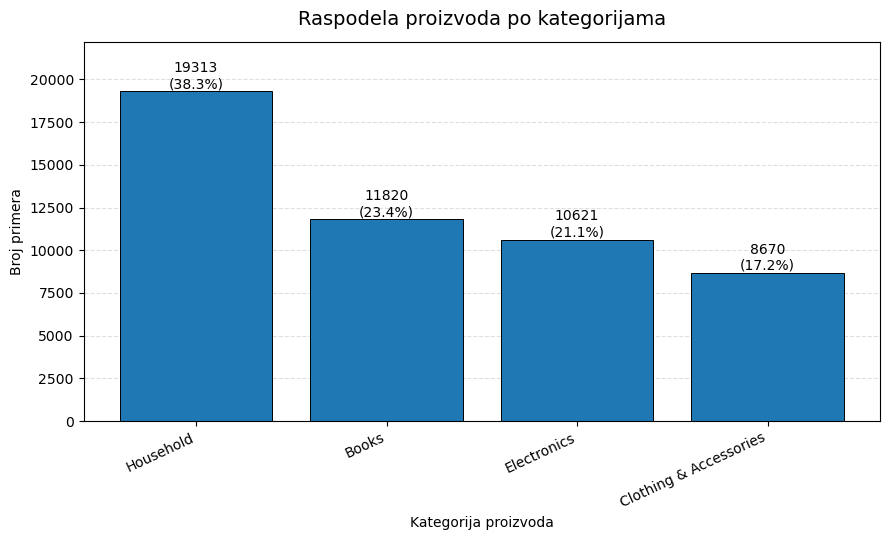

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(class_counts.index, class_counts.values, edgecolor="black", linewidth=0.7)

for bar, category in zip(bars, class_counts.index):
    count = class_counts[category]
    pct = class_percentages[category]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Raspodela proizvoda po kategorijama", fontsize=14, pad=12)
ax.set_xlabel("Kategorija proizvoda")
ax.set_ylabel("Broj primera")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_ylim(0, max(class_counts.values) * 1.15)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Najzastupljenija kategorija je `Household`, koja čini 38.30% skupa podataka, dok je najmanje zastupljena kategorija `Clothing & Accessories` sa 17.19%. Skup podataka nije potpuno balansiran, ali nijedna klasa nije ekstremno retka. Zbog toga će se u kasnijoj evaluaciji, pored accuracy metrike, koristiti i macro F1-score, jer on ravnomernije uzima u obzir performanse po svim klasama.

In [8]:
description_category_counts = (
    df_raw.dropna(subset=["description"])
    .groupby("description")["category"]
    .nunique()
)

num_conflicting_descriptions = (description_category_counts > 1).sum()

print("Broj tekstualnih opisa koji se pojavljuju u više različitih kategorija:")
print(num_conflicting_descriptions)

Broj tekstualnih opisa koji se pojavljuju u više različitih kategorija:
0


Dodatno je provereno da li se isti tekstualni opis pojavljuje u više različitih kategorija. Takvi slučajevi bi ukazivali na potencijalno nekonzistentne oznake klasa koje mogu negativno uticati na proces učenja i evaluaciju modela. U ovom slučaju nema tekstualnih opisa koji su povezani sa više različitih kategorija, što znači da  nisu uočene konfliktne oznake klasa.

### Uklanjanje duplikata za potrebe modelovanja

Pošto je broj dupliranih tekstualnih opisa veliki, za kasnije eksperimente se formira verzija skupa podataka bez duplikata. Time se smanjuje rizik da isti opis proizvoda bude prisutan i u trening i u test skupu, što bi moglo da dovede do precenjenih performansi modela.

In [9]:
df_unique = df.drop_duplicates(subset=["category", "description"]).reset_index(drop=True)

duplicate_percentage = (1 - len(df_unique) / len(df)) * 100

print(f"Broj primera pre uklanjanja duplikata: {len(df)}")
print(f"Broj primera nakon uklanjanja duplikata: {len(df_unique)}")
print(f"Procenat uklonjenih primera: {duplicate_percentage:.2f}%")

Broj primera pre uklanjanja duplikata: 50424
Broj primera nakon uklanjanja duplikata: 27802
Procenat uklonjenih primera: 44.86%


In [10]:
class_comparison = pd.DataFrame({
    "Pre uklanjanja duplikata": df["category"].value_counts(),
    "Nakon uklanjanja duplikata": df_unique["category"].value_counts()
})

class_comparison["Uklonjeno"] = (
    class_comparison["Pre uklanjanja duplikata"] 
    - class_comparison["Nakon uklanjanja duplikata"]
)

class_comparison["Procenat nakon uklanjanja duplikata (%)"] = (
    df_unique["category"].value_counts(normalize=True) * 100
).round(2)

display(class_comparison)

,Pre uklanjanja duplikata,Nakon uklanjanja duplikata,Uklonjeno,Procenat nakon uklanjanja duplikata (%)
category,,,,
Books,11820,6256,5564,22.50
Clothing & Accessories,8670,5674,2996,20.41
Electronics,10621,5308,5313,19.09
Household,19313,10564,8749,38.00


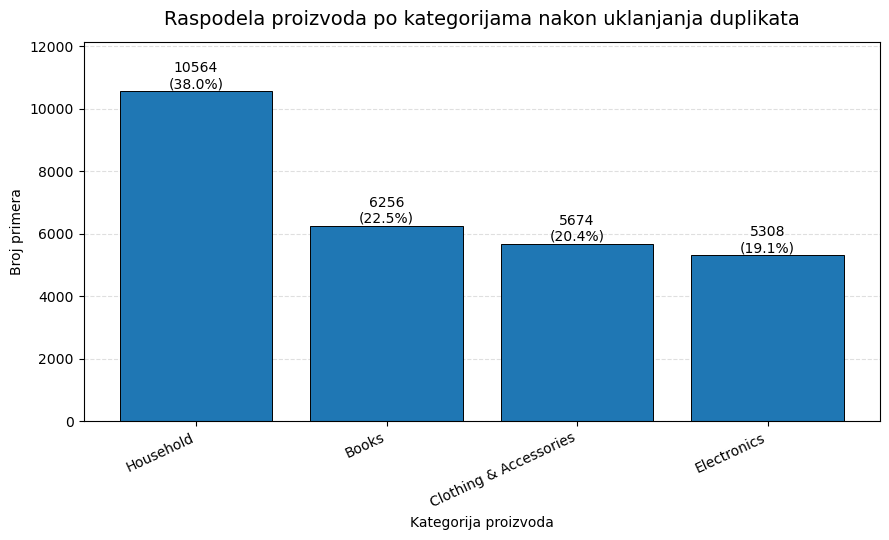

In [11]:
unique_class_counts = df_unique["category"].value_counts()
unique_class_percentages = df_unique["category"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(unique_class_counts.index, unique_class_counts.values, edgecolor="black", linewidth=0.7)

for bar, category in zip(bars, unique_class_counts.index):
    count = unique_class_counts[category]
    pct = unique_class_percentages[category]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Raspodela proizvoda po kategorijama nakon uklanjanja duplikata", fontsize=14, pad=12)
ax.set_xlabel("Kategorija proizvoda")
ax.set_ylabel("Broj primera")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_ylim(0, max(unique_class_counts.values) * 1.15)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Nakon uklanjanja duplikata, skup podataka sadrži 27802 jedinstvena primera. Iako je eliminisano 44.86% redova, preostali broj instanci je dovoljan za pouzdano treniranje i evaluaciju klasifikacionih modela. Uklanjanje duplikata doprinosi poboljšanju kvaliteta podataka, jer smanjuje mogućnost pojave pristrasnosti modela usled ponavljanja identičnih primera i sprečava potencijalno curenje informacija između trening i test skupa.

Analiza raspodele klasa pokazuje da je i nakon uklanjanja duplikata zadržana relativno uravnotežena zastupljenost svih kategorija. Klasa`Household` ostaje najbrojnija, dok nijedna od preostalih klasa nije zastupljena u zanemarljivo malom broju primera. Na osnovu toga, skup podataka bez duplikata (`df_unique`) predstavlja pogodniju osnovu za dalju analizu i izgradnju modela,  jer omogućava realniju procenu performansi modela i bolju kontrolu kvaliteta podataka.

In [12]:
df = df_unique.copy()
print("Dimenzije skupa koji će se koristiti u nastavku rada:")
print(df.shape)

Dimenzije skupa koji će se koristiti u nastavku rada:
(27802, 2)


### Primeri tekstualnih opisa po kategorijama

Na kraju osnovne analize prikazani su primeri tekstualnih opisa iz svake kategorije. Ovi primeri daju početni uvid u stil e-commerce tekstova: opisi često sadrže nazive proizvoda, dimenzije, boje, brendove, brojeve, merne jedinice i tehničke oznake. Upravo ovi elementi biće važni u kasnijoj analizi šuma i predobrade teksta.

In [13]:
for category in df["category"].unique():
    print("=" * 100)
    print(f"Kategorija: {category}")
    print("=" * 100)
    
    sample_texts = df[df["category"] == category]["description"].sample(
        n=2,
        random_state=RANDOM_STATE
    )
    
    for i, text in enumerate(sample_texts, 1):
        print(f"\nPrimer {i}:")
        print(text[:1000])
        print()

Kategorija: Household

Primer 1:
Samsung WD80J6410AS/TL Fully-automatic Front-loading Washing Machine (8 Kg, Silver)


Primer 2:
Ocamo Cute Rabbit Pattern Printing Canvas Storage Basket for Easter Purple Sequins Color Name:Purple sequins   Description: Item type: Storage Basket Size(L * W * H): 9 x 9 x 9.5in Color: pink, green, purple, blue, pink sequins, green sequins, purple sequins, blue sequins Weight: 120 g Applicable scope: vegetable,CD, cosmetics/jewelry, fruit, earphone cable/wire, bag, remote control, change clothes, magnetic card, underwear, quilt, stationery, books and magazines, suit Suitable for festivals: Easter Product material: canvas Features -- Environmental friendly material -- Big capacity -- Portable and lightweight  Package includes: 1 * Storage Basket Notes: 1-2cm error might exist due to manual measurements, please kindly understand. The colors deviation might differ due to different monitor settings.

Kategorija: Books

Primer 1:
Man's Search For Meaning: The c

## 2. Analiza kvaliteta teksta

U ovoj sekciji analiziraju se karakteristike tekstualnih opisa proizvoda koje su relevantne za kvalitet podataka i kasnije modelovanje. Fokus je na dužini opisa, veličini vokabulara, leksičkoj raznovrsnosti i prisustvu šuma u tekstu.

Analiza se sprovodi nad skupom `df`, odnosno nad verzijom podataka iz koje su prethodno uklonjeni nedostajući opisi i potpuno duplirani primeri.

### 2.1 Dužina tekstualnih opisa proizvoda

Dužina dokumenta je važna karakteristika tekstualnih podataka jer utiče na količinu dostupnih informacija, veličinu reprezentacije i kasnije performanse modela. U e-commerce domenu opisi mogu značajno da variraju: neki proizvodi imaju samo kratak naziv, dok drugi imaju detaljan opis sa specifikacijama, dimenzijama, karakteristikama i promotivnim tekstom.

U ovoj analizi posmatraju se broj karaktera, broj reči, približan broj rečenica i prosečna dužina reči po opisu proizvoda.

In [14]:
# kopija skupa za analizu kvaliteta teksta
df_quality = df.copy()

def simple_word_tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

def count_sentences(text):
    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return max(len(sentences), 1)

df_quality["char_count"] = df_quality["description"].apply(len)
df_quality["tokens"] = df_quality["description"].apply(simple_word_tokenize)
df_quality["word_count"] = df_quality["tokens"].apply(len)
df_quality["sentence_count"] = df_quality["description"].apply(count_sentences)

df_quality["avg_word_length"] = df_quality["tokens"].apply(
    lambda tokens: np.mean([len(token) for token in tokens]) if len(tokens) > 0 else 0
)

df_quality[["category", "char_count", "word_count", "sentence_count", "avg_word_length"]].head()

,category,char_count,word_count,sentence_count,avg_word_length
0,Household,1338,232,14,4.681034
1,Household,346,59,2,4.694915
2,Household,1316,227,12,4.220264
3,Household,1091,186,10,4.177419
4,Household,989,184,10,4.282609


In [15]:
length_summary = df_quality[
    ["char_count", "word_count", "sentence_count", "avg_word_length"]
].describe().T

display(length_summary.round(2))

,count,mean,std,min,25%,50%,75%,max
char_count,27802.0,699.99,1023.02,4.00,215.00,473.00,916.75,50403.0
word_count,27802.0,115.57,171.35,1.00,35.00,78.00,151.00,8485.0
sentence_count,27802.0,6.72,10.30,1.00,2.00,4.00,8.00,519.0
avg_word_length,27802.0,4.95,0.67,1.29,4.59,4.88,5.21,15.0


Opisne statistike pokazuju da prosečan opis proizvoda ima oko **116 reči**, dok je medijana **78 reči**. Razlika između proseka i medijane ukazuje na asimetričnu raspodelu, odnosno na prisustvo manjeg broja veoma dugih opisa koji povećavaju prosečnu vrednost. Maksimalna dužina od 8485 reči pokazuje da u skupu postoje ekstremno dugi tekstovi, što je važno za kasnije modelovanje jer takvi primeri mogu uticati na BoW/TF-IDF reprezentaciju i na modele koji imaju ograničenje maksimalne dužine ulaza.

In [16]:
length_by_category = (
    df_quality
    .groupby("category")
    .agg(
        examples=("description", "count"),
        mean_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        min_words=("word_count", "min"),
        max_words=("word_count", "max"),
        mean_chars=("char_count", "mean"),
        median_chars=("char_count", "median"),
        mean_sentences=("sentence_count", "mean")
    )
    .sort_values("median_words", ascending=False)
)

display(length_by_category.round(2))

,examples,mean_words,median_words,min_words,max_words,mean_chars,median_chars,mean_sentences
category,,,,,,,,
Electronics,5308,137.22,102.0,1,2144,825.01,616.5,8.29
Household,10564,109.49,86.0,1,1808,661.73,518.0,6.44
Books,6256,144.09,75.0,1,8485,888.09,472.0,7.89
Clothing & Accessories,5674,75.19,59.0,1,589,446.90,344.5,4.47


Analiza po kategorijama pokazuje da se dužina opisa razlikuje u zavisnosti od tipa proizvoda. Najveću medijanu broja reči ima kategorija `Electronics`, što je očekivano jer opisi elektronskih proizvoda često sadrže tehničke karakteristike, kompatibilnost, dimenzije i specifikacije. Kategorija `Clothing & Accessories` ima najkraće opise, dok kategorija `Books` sadrži najizraženije ekstremno duge primere, verovatno zbog uključivanja opisa sadržaja, recenzija ili informacija o autorima.

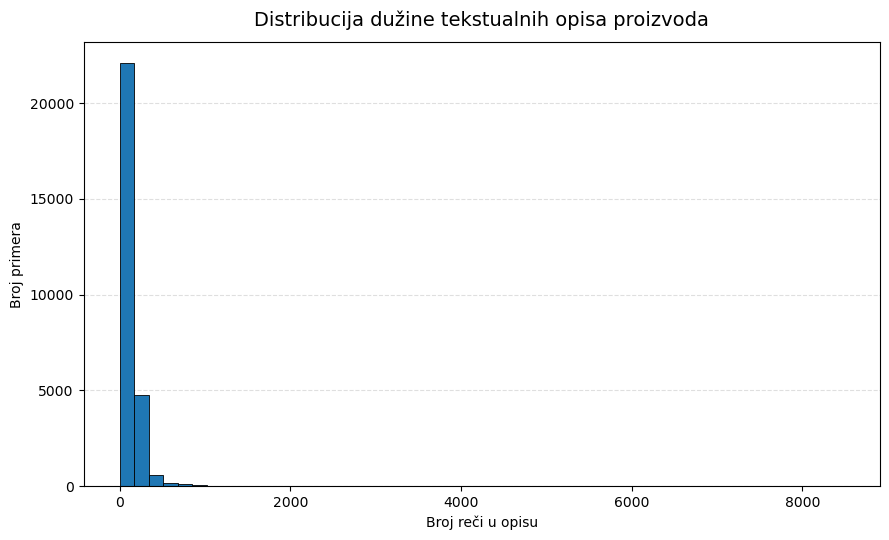

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(df_quality["word_count"], bins=50, edgecolor="black", linewidth=0.6)

ax.set_title("Distribucija dužine tekstualnih opisa proizvoda", fontsize=14, pad=12)
ax.set_xlabel("Broj reči u opisu")
ax.set_ylabel("Broj primera")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Prvi histogram pokazuje da je raspodela dužine opisa izrazito asimetrična. Većina opisa je relativno kratka, dok mali broj ekstremno dugih opisa širi opseg x-ose i otežava detaljan prikaz glavnog dela distribucije. Zbog toga se u nastavku prikazuje distribucija ograničena na 99. percentil.

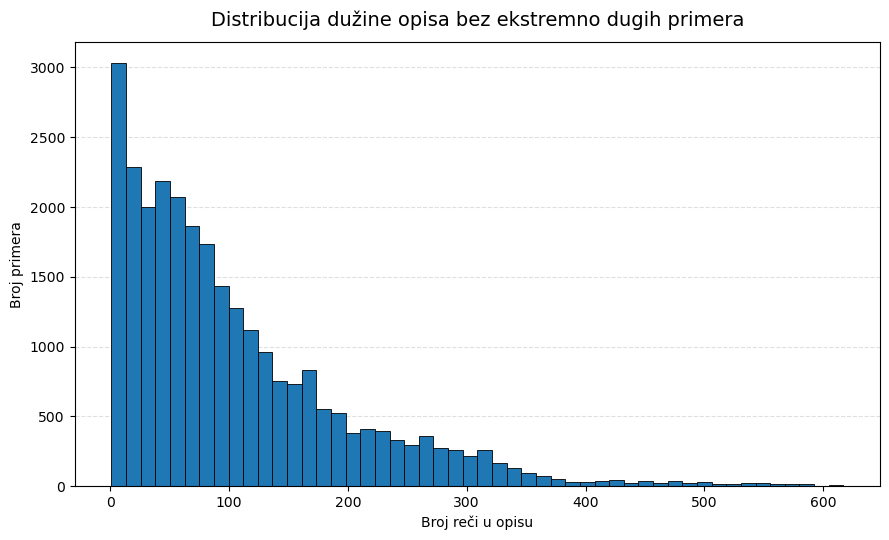

99. percentil broja reči: 619


In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))

upper_limit = df_quality["word_count"].quantile(0.99)

ax.hist(
    df_quality[df_quality["word_count"] <= upper_limit]["word_count"],
    bins=50,
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Distribucija dužine opisa bez ekstremno dugih primera", fontsize=14, pad=12)
ax.set_xlabel("Broj reči u opisu")
ax.set_ylabel("Broj primera")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"99. percentil broja reči: {upper_limit:.0f}")

Nakon ograničavanja prikaza na 99. percentil vidi se da najveći broj opisa ima manje od 150 reči, dok se učestalost postepeno smanjuje kako dužina opisa raste. Vrednost 99. percentila iznosi 619 reči, što znači da samo oko 1% primera ima duže opise od ove vrednosti.

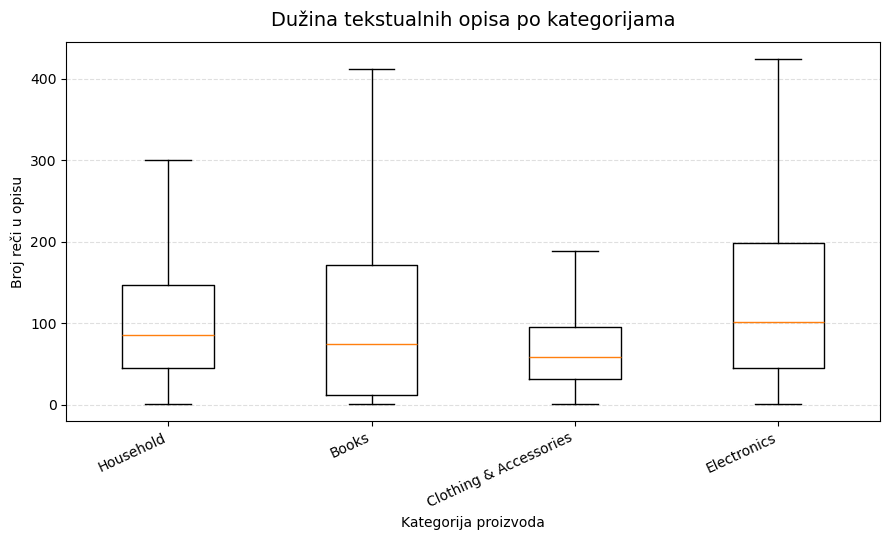

In [19]:
category_order = df_quality["category"].value_counts().index.tolist()

data_to_plot = [
    df_quality[df_quality["category"] == category]["word_count"]
    for category in category_order
]

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.boxplot(
    data_to_plot,
    labels=category_order,
    showfliers=False
)

ax.set_title("Dužina tekstualnih opisa po kategorijama", fontsize=14, pad=12)
ax.set_xlabel("Kategorija proizvoda")
ax.set_ylabel("Broj reči u opisu")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Boxplot potvrđuje da postoje razlike u dužini opisa između kategorija. Kategorija `Electronics` ima najvišu medijanu dužine opisa, dok `Clothing & Accessories` ima kraće i kompaktnije opise. Pošto su ekstremne vrednosti sakrivene u prikazu (`showfliers=False`), grafikon bolje prikazuje tipične razlike između kategorija.

In [20]:
short_texts = df_quality[df_quality["word_count"] <= 5].sort_values("word_count")
long_texts = df_quality.sort_values("word_count", ascending=False).head(5)

print("Broj veoma kratkih opisa sa 5 ili manje reči:")
print(len(short_texts))

print("\nPrimeri veoma kratkih opisa:")
display(short_texts[["category", "description", "word_count"]].head(10))

print("\nPrimeri najdužih opisa:")
display(long_texts[["category", "description", "word_count"]])

Broj veoma kratkih opisa sa 5 ili manje reči:
795

Primeri veoma kratkih opisa:


,category,description,word_count
14361,Books,Microeconomics,1
10424,Household,Sourcery,1
11257,Books,Panorama,1
16612,Books,Chanakya,1
14070,Books,Tennis,1
14356,Books,Macroeconomics,1
16447,Books,Criminology,1
13326,Books,Mysticism,1
16418,Books,Archaeology,1
12739,Books,Siddhartha,1



Primeri najdužih opisa:


,category,description,word_count
15350,Books,"Risk Savvy: How to Make Good Decisions About the Author Gerd Gigerenzer is the author of Gut Feelings. He is currently the director of the Max Planck Institute for Human Development in Berlin, Ger...",8485
15346,Books,"Risk Savvy: How to Make Good Decisions About the Author GERD GIGERENZER is director of the Max Planck Institute for Human Development in Berlin, and lectures around the world on the importance of ...",8472
13397,Books,The Global War on Christians: Dispatches from the Front Lines of Anti-Christian Persecution About the Author John L. Allen Jr. is associate editor of The Boston Globe after 16 years as the prize-w...,7927
12588,Books,"Dracula (Enriched Classics) About the Author Bram Stoker was born November 8, 1847, in Dublin, Ireland. Stoker was a sickly child who was frequently bedridden; his mother entertained him by tellin...",5895
10910,Books,The Forty Rules of Love: A Novel of Rumi About the Author Elif Shafak is an award-winning bestselling novelist and the most widely read female writer in Turkey. Her books have been translated into...,5264


U skupu postoji 795 veoma kratkih opisa sa 5 ili manje reči. Takvi opisi često predstavljaju samo naziv proizvoda ili kratak naslov, pa mogu sadržati nedovoljno informacija za pouzdanu klasifikaciju. Sa druge strane, najduži opisi uglavnom potiču iz kategorije `Books` i sadrže velike količine dodatnog teksta, kao što su opisi autora, recenzije ili sadržaj knjige. Ova razlika potvrđuje da dužina teksta u ovom skupu nije ravnomerno raspoređena i da može imati uticaj na kasnije modele.

### 2.2 Veličina vokabulara

Veličina vokabulara predstavlja broj jedinstvenih tokena u skupu tekstualnih dokumenata. U tekstualnim podacima ovo je važan aspekt kvaliteta, jer veliki vokabular povećava dimenzionalnost reprezentacije, naročito kod Bag-of-Words i TF-IDF pristupa.

Kod e-commerce opisa proizvoda vokabular može biti proširen zbog naziva brendova, oznaka modela, dimenzija, brojeva, mernih jedinica i različitih zapisa istih pojmova. Zbog toga se u ovom delu poredi veličina vokabulara pre i posle nekoliko jednostavnih oblika normalizacije.

In [21]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [22]:
def tokenize_case_sensitive(text):
    return re.findall(r"\b\w+\b", text)

def tokenize_lowercase(text):
    return re.findall(r"\b\w+\b", text.lower())

def tokenize_alpha_only(text):
    return [token for token in tokenize_lowercase(text) if token.isalpha()]

def tokenize_without_stopwords(text):
    return [
        token for token in tokenize_alpha_only(text)
        if token not in ENGLISH_STOP_WORDS
    ]

token_variants = {
    "case_sensitive": df_quality["description"].apply(tokenize_case_sensitive),
    "lowercase": df_quality["description"].apply(tokenize_lowercase),
    "alpha_only": df_quality["description"].apply(tokenize_alpha_only),
    "without_stopwords": df_quality["description"].apply(tokenize_without_stopwords)
}

In [23]:
def vocabulary_statistics(token_series):
    all_tokens = [token for tokens in token_series for token in tokens]
    token_counter = Counter(all_tokens)
    
    total_tokens = len(all_tokens)
    vocabulary_size = len(token_counter)
    rare_tokens = sum(1 for token, freq in token_counter.items() if freq == 1)
    
    return {
        "total_tokens": total_tokens,
        "vocabulary_size": vocabulary_size,
        "rare_tokens_freq_1": rare_tokens,
        "rare_tokens_share_%": rare_tokens / vocabulary_size * 100 if vocabulary_size > 0 else 0
    }

vocab_summary = pd.DataFrame({
    variant_name: vocabulary_statistics(tokens)
    for variant_name, tokens in token_variants.items()
}).T

display(vocab_summary.round(2))

,total_tokens,vocabulary_size,rare_tokens_freq_1,rare_tokens_share_%
case_sensitive,3213073.0,104991.0,45182.0,43.03
lowercase,3213073.0,79034.0,34072.0,43.11
alpha_only,3058378.0,64093.0,24956.0,38.94
without_stopwords,1929957.0,63784.0,24952.0,39.12


Tabela pokazuje da normalizacija značajno utiče na veličinu vokabulara. U `case_sensitive` varijanti postoji 104991 jedinstven token, dok se nakon pretvaranja teksta u mala slova (`lowercase`) vokabular smanjuje na 79034 tokena. To pokazuje da različita upotreba velikih i malih slova povećava dimenzionalnost teksta.

Nakon uklanjanja nealfabetskih tokena vokabular se dodatno smanjuje na 64093 tokena, jer se uklanjaju brojevi, dimenzije, šifre modela i alfanumeričke oznake proizvoda. Uklanjanje stop-reči značajno smanjuje ukupan broj tokena, ali veoma malo menja veličinu vokabulara. To znači da stop-reči imaju veliku učestalost u tekstu, ali ne čine veliki deo jedinstvenih tokena.

In [24]:
# detaljnije lowercase varijanta
all_lower_tokens = [token for tokens in token_variants["lowercase"] for token in tokens]
lower_token_counter = Counter(all_lower_tokens)

most_common_tokens = pd.DataFrame(
    lower_token_counter.most_common(30),
    columns=["token", "frequency"]
)

display(most_common_tokens)

,token,frequency
0,the,115381
1,and,105135
2,of,68891
3,to,61654
4,a,54300
5,for,46252
6,in,41983
7,with,39367
8,is,37605
9,your,26058


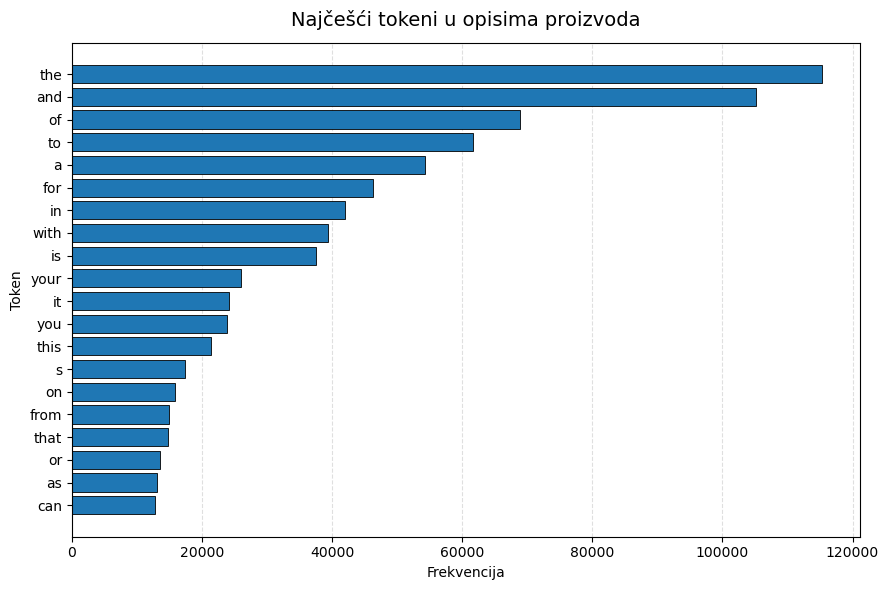

In [25]:
top_n = 20
top_tokens = most_common_tokens.head(top_n).sort_values("frequency")

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(top_tokens["token"], top_tokens["frequency"], edgecolor="black", linewidth=0.6)

ax.set_title("Najčešći tokeni u opisima proizvoda", fontsize=14, pad=12)
ax.set_xlabel("Frekvencija")
ax.set_ylabel("Token")
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Najčešći tokeni u lowercase varijanti uglavnom su stop-reči, kao što su `the`, `and`, `of`, `to`, `a` i `for`. Ovo pokazuje zašto uklanjanje stop-reči može biti korisno kod BoW reprezentacije, jer ove reči imaju veliku frekvenciju, ali obično ne nose dovoljno informacija za razlikovanje kategorija proizvoda. 
Kod TF-IDF reprezentacije njihov uticaj je manji, jer tokeni koji se pojavljuju u velikom broju dokumenata dobijaju nižu težinu.

In [26]:
# analiza retkih tokena
rare_tokens = [token for token, freq in lower_token_counter.items() if freq == 1]

print(f"Broj tokena koji se pojavljuju samo jednom: {len(rare_tokens)}")
print(f"Ukupna veličina lowercase vokabulara: {len(lower_token_counter)}")
print(f"Udeo retkih tokena u vokabularu: {len(rare_tokens) / len(lower_token_counter) * 100:.2f}%")

print("\nPrimeri retkih tokena:")
print(rare_tokens[:50])

Broj tokena koji se pojavljuju samo jednom: 34072
Ukupna veličina lowercase vokabulara: 79034
Udeo retkih tokena u vokabularu: 43.11%

Primeri retkih tokena:
['sao297', 'sanfsw4951', 'decaration', 'wallart', 'vangoh', 'mav', 'damyanthi', '23x35', 'poster_', 'abo397', 'kutchh', 'sa30', 'sao97', 'ourmemo', 'shelfpocket', 'stenciling', 'haugom', 'olsen', 'sza', 'pwc', 'instanote', 'sao468', 'babylove_a4', '12x8', 'inch1', '117poster_406', 'techbite', '30x45cm', '72cms', '48cms', '58single', '9x13', 'inephos', '30x45cms', '3gsm', 'rozi', 'brown_pack', 'uninflated', 'buntings', 'freehand', 'dhuppatta', 'speccial', 'resses', 'rn281', 'lac97', 'needlecraft', '4624', '02222', 'skiens', 'crotchet']


U `lowercase` vokabularu postoji 34072 tokena koji se pojavljuju samo jednom, što čini 43.11% ukupnog vokabulara. Ovo potvrđuje izražen long-tail efekat u tekstualnim opisima proizvoda. Primeri retkih tokena pokazuju da se među njima nalaze šifre proizvoda, dimenzije, brendovi, alfanumeričke oznake, greške u pisanju i specifični domenski termini.

Ovakvi tokeni mogu biti korisni ako su povezani sa određenom kategorijom proizvoda, ali istovremeno povećavaju dimenzionalnost BoW i TF-IDF reprezentacija i mogu otežati generalizaciju modela.

In [27]:
# veličina vokabulara po kategorijama
category_vocab_stats = []

for category in df_quality["category"].unique():
    category_texts = df_quality[df_quality["category"] == category]["description"]
    category_tokens = category_texts.apply(tokenize_lowercase)
    all_category_tokens = [token for tokens in category_tokens for token in tokens]
    category_counter = Counter(all_category_tokens)
    
    category_vocab_stats.append({
        "category": category,
        "documents": len(category_texts),
        "total_tokens": len(all_category_tokens),
        "vocabulary_size": len(category_counter),
        "rare_tokens_freq_1": sum(1 for token, freq in category_counter.items() if freq == 1)
    })

category_vocab_stats = pd.DataFrame(category_vocab_stats)
category_vocab_stats["rare_tokens_share_%"] = (
    category_vocab_stats["rare_tokens_freq_1"] 
    / category_vocab_stats["vocabulary_size"] 
    * 100
)

category_vocab_stats = category_vocab_stats.sort_values("vocabulary_size", ascending=False)

display(category_vocab_stats.round(2))

,category,documents,total_tokens,vocabulary_size,rare_tokens_freq_1,rare_tokens_share_%
1,Books,6256,901407,39981,16255,40.66
0,Household,10564,1156684,34090,14074,41.28
3,Electronics,5308,728372,29032,12540,43.19
2,Clothing & Accessories,5674,426610,14603,5568,38.13


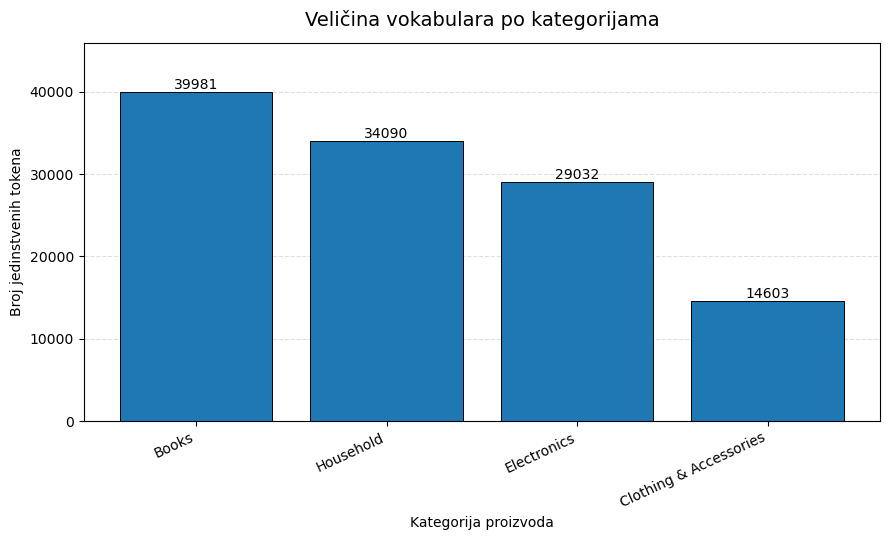

In [28]:
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    category_vocab_stats["category"],
    category_vocab_stats["vocabulary_size"],
    edgecolor="black",
    linewidth=0.7
)

for bar, value in zip(bars, category_vocab_stats["vocabulary_size"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylim(0, category_vocab_stats["vocabulary_size"].max() * 1.15)
ax.set_title("Veličina vokabulara po kategorijama", fontsize=14, pad=12)
ax.set_xlabel("Kategorija proizvoda")
ax.set_ylabel("Broj jedinstvenih tokena")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Veličina vokabulara se razlikuje po kategorijama. Najveći vokabular ima kategorija `Books` sa 39981 jedinstvenim tokenom, iako nema najveći broj dokumenata. Ovo ukazuje na veću leksičku raznovrsnost opisa knjiga, koji često uključuju naslove, imena autora, recenzije, opise sadržaja i biografske informacije.

Kategorija `Household` ima najveći broj dokumenata, ali nešto manji vokabular od kategorije `Books`. Kategorija `Electronics` takođe ima veliki vokabular zbog tehničkih specifikacija, oznaka modela i kompatibilnosti uređaja. Najmanji vokabular ima `Clothing & Accessories`, što je u skladu sa prethodnom analizom dužine opisa.

#### Analiza Zipfovog zakona

Pored same veličine vokabulara, korisno je analizirati i raspodelu frekvencija tokena. Prema Zipfovom zakonu, mali broj reči ima veoma visoku frekvenciju, dok se veliki broj reči pojavljuje retko.

Ova analiza je značajna za e-commerce tekstove jer objašnjava zašto se u skupu pojavljuje veliki broj retkih tokena, kao što su nazivi brendova, šifre modela, dimenzije proizvoda i specifične oznake.

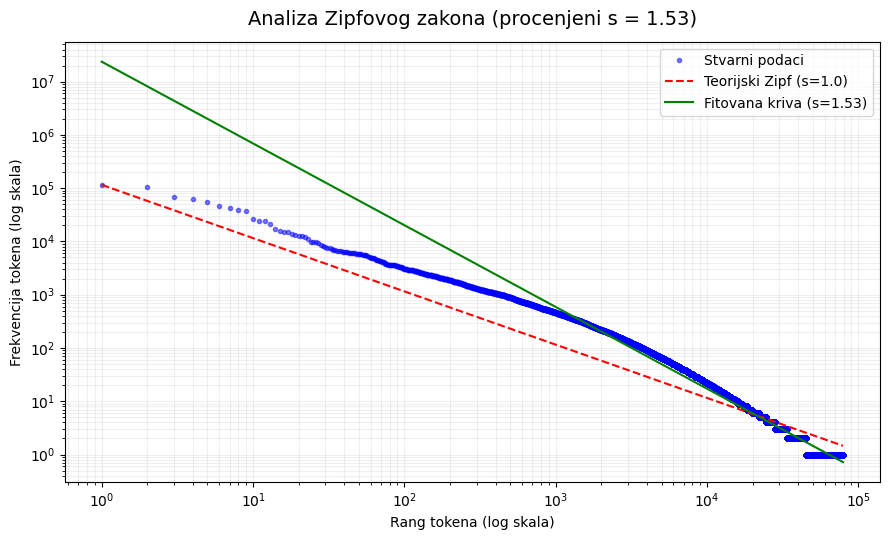

Broj tokena sa frekvencijom 1: 34072
Procenat retkih tokena: 43.11%
Procenjeni Zipfov eksponent s: 1.53


In [29]:
word_freqs = sorted(
    lower_token_counter.items(),
    key=lambda x: x[1],
    reverse=True
)

freqs = np.array([freq for _, freq in word_freqs])
ranks = np.arange(1, len(freqs) + 1)

# Teorijska Zipf linija za s = 1.0
C = freqs[0]
zipf_theoretical = C / (ranks ** 1.0)

# Fitovana kriva: procena stvarnog Zipfovog eksponenta s
log_ranks = np.log(ranks)
log_freqs = np.log(freqs)

m, b = np.polyfit(log_ranks, log_freqs, 1)
s_est = -m

zipf_fitted = np.exp(b) * (ranks ** m)

plt.figure(figsize=(9, 5.5))
plt.loglog(ranks, freqs, "b.", label="Stvarni podaci", alpha=0.5)
plt.loglog(ranks, zipf_theoretical, "r--", label="Teorijski Zipf (s=1.0)")
plt.loglog(ranks, zipf_fitted, "g-", label=f"Fitovana kriva (s={s_est:.2f})")

plt.title(f"Analiza Zipfovog zakona (procenjeni s = {s_est:.2f})", fontsize=14, pad=12)
plt.xlabel("Rang tokena (log skala)")
plt.ylabel("Frekvencija tokena (log skala)")
plt.legend()
plt.grid(True, which="both", linestyle="-", alpha=0.2)
plt.tight_layout()
plt.show()

vocab_size = len(word_freqs)
rare_words = sum(1 for word, freq in word_freqs if freq == 1)

print("Broj tokena sa frekvencijom 1:", rare_words)
print("Procenat retkih tokena: {:.2%}".format(rare_words / vocab_size))
print(f"Procenjeni Zipfov eksponent s: {s_est:.2f}")

Zipfova analiza pokazuje da raspodela frekvencija tokena ima izražen long-tail oblik. Mali broj tokena pojavljuje se veoma često, dok veliki broj tokena ima nisku frekvenciju. Dobijeni Zipfov eksponent iznosi približno `s = 1.53`, što je više od teorijske vrednosti `s = 1.0`.

Odstupanje od teorijske vrednosti može se objasniti domenskom prirodom e-commerce tekstova. U opisima proizvoda često se pojavljuju specifični nazivi proizvoda, brendovi, šifre modela, dimenzije, oznake boja i tehnički termini. Zbog toga frekvencije tokena brže opadaju, a rep raspodele je izražen. To je u skladu sa prethodnim rezultatom da se 43.11% vokabulara sastoji od tokena koji se pojavljuju samo jednom.

### 2.3 Leksička raznovrsnost tekstualnih opisa (Lexical Diversity)

Leksička raznovrsnost predstavlja odnos između broja jedinstvenih tokena i ukupnog broja tokena u tekstu. Ova mera pokazuje koliko je vokabular raznovrstan u okviru pojedinačnog opisa ili celog korpusa.

U kontekstu e-commerce opisa proizvoda, leksička raznovrsnost može ukazivati na to da li su opisi šablonski i ponavljajući ili sadrže veliki broj različitih termina, naziva proizvoda, brendova, specifikacija i domenski specifičnih izraza.

Najjednostavnija mera leksičke raznovrsnosti je Type-Token Ratio (TTR):

`TTR = broj jedinstvenih tokena / ukupan broj tokena`

Međutim, TTR zavisi od dužine teksta. Kratki tekstovi često imaju visoku vrednost ove mere, dok duži tekstovi prirodno imaju više ponavljanja i niži TTR. Zbog toga se u nastavku analiziraju i svi opisi i opisi koji imaju najmanje 10 reči.

In [30]:
def lexical_diversity(tokens):
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

df_quality["lexical_diversity"] = df_quality["tokens"].apply(lexical_diversity)

df_quality[["category", "word_count", "lexical_diversity"]].head()

,category,word_count,lexical_diversity
0,Household,232,0.629310
1,Household,59,0.796610
2,Household,227,0.537445
3,Household,186,0.591398
4,Household,184,0.614130


In [31]:
lexical_summary = df_quality[["lexical_diversity"]].describe().T
display(lexical_summary.round(3))

,count,mean,std,min,25%,50%,75%,max
lexical_diversity,27802.0,0.737,0.148,0.13,0.636,0.726,0.833,1.0


Za sve opise prosečna leksička raznovrsnost iznosi 0.737, dok je medijana 0.726. Maksimalna vrednost je 1.0, što ukazuje da deo opisa sadrži samo jedinstvene tokene. Međutim, ova vrednost se najčešće javlja kod kratkih opisa i ne mora značiti da su ti opisi kvalitetniji ili informativniji. Zbog toga je potrebno posebno analizirati opise koji imaju dovoljno tokena za stabilniju procenu.

In [32]:
perfect_diversity = df_quality[df_quality["lexical_diversity"] == 1.0]

print(f"Broj opisa sa lexical diversity = 1.0: {len(perfect_diversity)}")
print(f"Udeo takvih opisa: {len(perfect_diversity) / len(df_quality) * 100:.2f}%")

display(
    perfect_diversity[["category", "description", "word_count", "lexical_diversity"]]
    .sort_values("word_count")
    .head(10)
)

Broj opisa sa lexical diversity = 1.0: 3010
Udeo takvih opisa: 10.83%


,category,description,word_count,lexical_diversity
14136,Books,Sail,1,1.0
16677,Books,Psychotherapy,1,1.0
14361,Books,Microeconomics,1,1.0
16447,Books,Criminology,1,1.0
16149,Books,Mathematics,1,1.0
11561,Books,#Horror,1,1.0
14873,Books,Becoming,1,1.0
12739,Books,Siddhartha,1,1.0
15129,Books,Epistemology,1,1.0
13299,Books,Meditations,1,1.0


Vrednost `lexical_diversity = 1.0` znači da se nijedan token u opisu ne ponavlja. Ova vrednost se posebno lako javlja kod kratkih opisa, što potvrđuju prikazani primeri sa jednim tokenom. Zbog toga visoka leksička raznovrsnost ne znači nužno da je opis informativan. Ovaj rezultat potvrđuje da TTR treba tumačiti zajedno sa dužinom teksta.

In [33]:
df_quality_10 = df_quality[df_quality["word_count"] >= 10].copy()

lexical_summary_10 = df_quality_10[["lexical_diversity"]].describe().T
display(lexical_summary_10.round(3))

print(f"Broj svih opisa: {len(df_quality)}")
print(f"Broj opisa sa najmanje 10 reči: {len(df_quality_10)}")
print(f"Broj opisa kraćih od 10 reči: {len(df_quality) - len(df_quality_10)}")

,count,mean,std,min,25%,50%,75%,max
lexical_diversity,25820.0,0.718,0.135,0.13,0.629,0.714,0.806,1.0


Broj svih opisa: 27802
Broj opisa sa najmanje 10 reči: 25820
Broj opisa kraćih od 10 reči: 1982


Nakon izdvajanja opisa sa najmanje 10 reči ostaje 25820 primera, dok je 1982 opisa kraće od 10 reči. Prosečna leksička raznovrsnost se smanjuje sa 0.737 na 0.718, a medijana sa 0.726 na 0.714. Ovo potvrđuje da kratki opisi povećavaju ukupnu procenu leksičke raznovrsnosti, jer kod kratkih tekstova ima manje ponavljanja tokena.

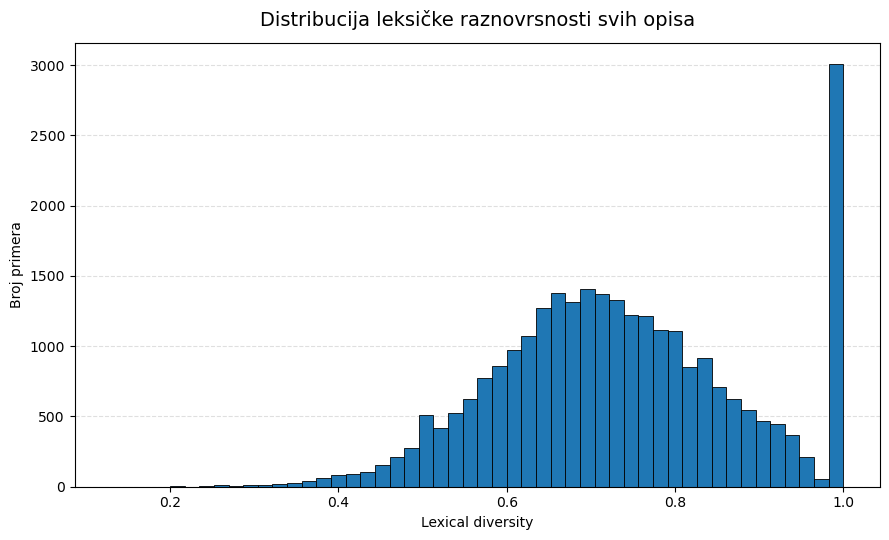

In [34]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(df_quality["lexical_diversity"], bins=50, edgecolor="black", linewidth=0.6)

ax.set_title("Distribucija leksičke raznovrsnosti svih opisa", fontsize=14, pad=12)
ax.set_xlabel("Lexical diversity")
ax.set_ylabel("Broj primera")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Histogram za sve opise pokazuje koncentraciju vrednosti između približno 0.6 i 0.85, ali i izražen skok kod vrednosti 1.0. Taj skok je posledica kratkih opisa kod kojih se svaki token pojavljuje samo jednom. Zbog toga ovaj grafikon dobro pokazuje ograničenje TTR mere: veoma kratki tekstovi mogu imati maksimalnu leksičku raznovrsnost, iako ne sadrže mnogo informacija.

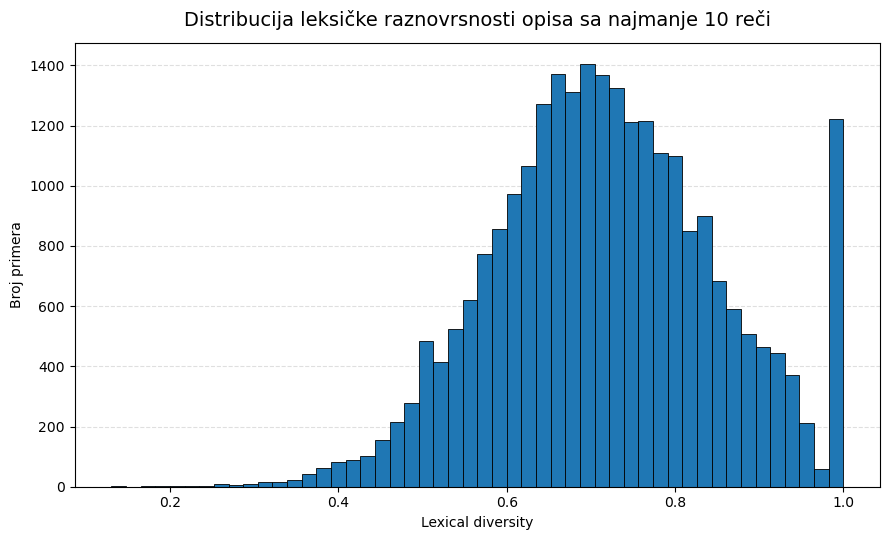

In [35]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(df_quality_10["lexical_diversity"], bins=50, edgecolor="black", linewidth=0.6)

ax.set_title("Distribucija leksičke raznovrsnosti opisa sa najmanje 10 reči", fontsize=14, pad=12)
ax.set_xlabel("Lexical diversity")
ax.set_ylabel("Broj primera")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Kada se posmatraju samo opisi sa najmanje 10 reči, distribucija postaje stabilnija, jer je uticaj najkraćih opisa smanjen. Ipak, i dalje postoji grupa opisa sa vrednošću blizu 1.0, što ukazuje na kraće ili kompaktnije tekstove u kojima se tokeni retko ponavljaju. Većina opisa ima vrednosti približno između 0.6 i 0.8, što ukazuje na relativno raznovrsne, ali delimično šablonske e-commerce opise.

In [36]:
lexical_by_category = (
    df_quality
    .groupby("category")
    .agg(
        examples=("description", "count"),
        mean_lexical_diversity=("lexical_diversity", "mean"),
        median_lexical_diversity=("lexical_diversity", "median"),
        mean_words=("word_count", "mean"),
        median_words=("word_count", "median")
    )
    .sort_values("median_lexical_diversity", ascending=False)
)

display(lexical_by_category.round(3))

,examples,mean_lexical_diversity,median_lexical_diversity,mean_words,median_words
category,,,,,
Clothing & Accessories,5674,0.773,0.771,75.187,59.0
Books,6256,0.758,0.727,144.087,75.0
Household,10564,0.725,0.717,109.493,86.0
Electronics,5308,0.698,0.688,137.222,102.0


In [37]:
lexical_by_category_10 = (
    df_quality_10
    .groupby("category")
    .agg(
        examples=("description", "count"),
        mean_lexical_diversity=("lexical_diversity", "mean"),
        median_lexical_diversity=("lexical_diversity", "median"),
        mean_words=("word_count", "mean"),
        median_words=("word_count", "median")
    )
    .sort_values("median_lexical_diversity", ascending=False)
)

display(lexical_by_category_10.round(3))

,examples,mean_lexical_diversity,median_lexical_diversity,mean_words,median_words
category,,,,,
Clothing & Accessories,5308,0.759,0.761,79.909,61.0
Household,10325,0.719,0.714,111.862,88.0
Books,4992,0.703,0.685,179.180,108.0
Electronics,5195,0.692,0.684,140.052,106.0


Poređenje po kategorijama pokazuje da `Clothing & Accessories` ima najveću medijanu leksičke raznovrsnosti. Međutim, ova kategorija istovremeno ima najkraće opise, pa se visoka TTR vrednost mora tumačiti oprezno. Kraći tekstovi prirodno imaju manje ponavljanja tokena, što povećava leksičku raznovrsnost.

Kada se posmatraju samo opisi sa najmanje 10 reči, redosled kategorija se menja: `Clothing & Accessories` ostaje najviša, dok `Books` opada zbog dužih opisa koji često sadrže ponavljanja, recenzije i dodatni tekst. `Electronics` ima najnižu medijanu leksičke raznovrsnosti, što može biti posledica ponavljanja tehničkih izraza, specifikacija i standardnih formulacija u opisima elektronskih proizvoda.

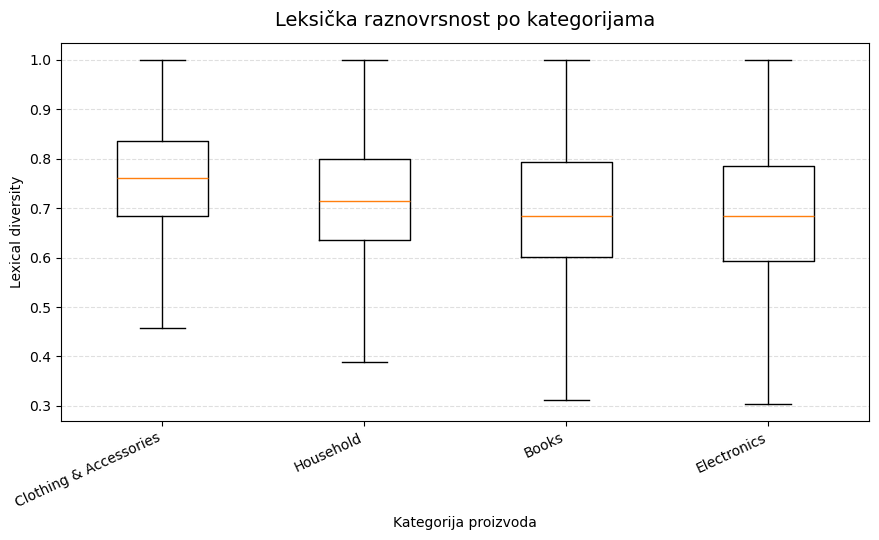

In [38]:
category_order = lexical_by_category_10.index.tolist()

data_to_plot = [
    df_quality_10[df_quality_10["category"] == category]["lexical_diversity"]
    for category in category_order
]

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.boxplot(
    data_to_plot,
    labels=category_order,
    showfliers=False
)

ax.set_title("Leksička raznovrsnost po kategorijama", fontsize=14, pad=12)
ax.set_xlabel("Kategorija proizvoda")
ax.set_ylabel("Lexical diversity")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Boxplot potvrđuje razlike između kategorija. `Clothing & Accessories` ima najvišu tipičnu leksičku raznovrsnost, dok `Electronics` i `Books` imaju niže vrednosti. Ovo ne znači nužno da su opisi odeće informativniji, već da su kraći i imaju manje ponavljanja. Zato se leksička raznovrsnost ne sme posmatrati izolovano, već zajedno sa dužinom opisa.

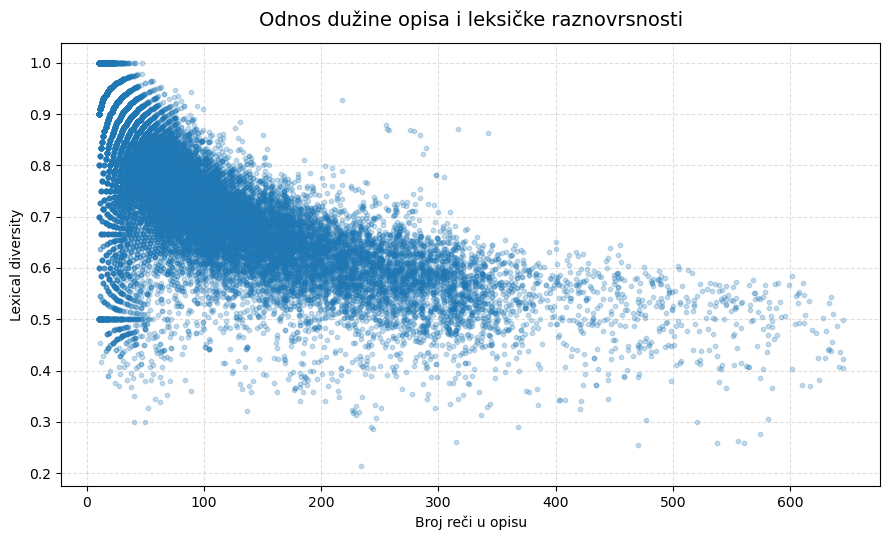

99. percentil broja reči u ovom prikazu: 646


In [39]:
scatter_limit = df_quality_10["word_count"].quantile(0.99)

scatter_data = df_quality_10[df_quality_10["word_count"] <= scatter_limit]

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(
    scatter_data["word_count"],
    scatter_data["lexical_diversity"],
    alpha=0.25,
    s=10
)

ax.set_title("Odnos dužine opisa i leksičke raznovrsnosti", fontsize=14, pad=12)
ax.set_xlabel("Broj reči u opisu")
ax.set_ylabel("Lexical diversity")
ax.set_axisbelow(True)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"99. percentil broja reči u ovom prikazu: {scatter_limit:.0f}")

Scatter plot pokazuje negativan odnos između dužine opisa i leksičke raznovrsnosti. Kraći opisi često imaju visoke TTR vrednosti, dok se kod dužih opisa javlja više ponavljanja tokena, pa leksička raznovrsnost opada. Prikaz je ograničen na 99. percentil broja reči, odnosno na opise do 646 reči, kako ekstremno dugi opisi ne bi smanjili preglednost grafikona.

In [40]:
correlation = df_quality_10["word_count"].corr(df_quality_10["lexical_diversity"])

print(f"Korelacija između dužine opisa i leksičke raznovrsnosti: {correlation:.3f}")

Korelacija između dužine opisa i leksičke raznovrsnosti: -0.500


Korelacija između dužine opisa i leksičke raznovrsnosti iznosi -0.500, što potvrđuje umeren negativan odnos između ove dve veličine. To znači da duži opisi u proseku imaju nižu TTR vrednost, jer se u njima tokeni češće ponavljaju. Ovaj rezultat dodatno potvrđuje da leksičku raznovrsnost treba tumačiti u odnosu na dužinu dokumenta.

In [41]:
# Leksička raznovrsnost na nivou celog korpusa i po kategorijama

corpus_lexical_stats = []

for category in ["ALL"] + df_quality["category"].unique().tolist():
    if category == "ALL":
        subset = df_quality
    else:
        subset = df_quality[df_quality["category"] == category]
    
    all_tokens_category = [token for tokens in subset["tokens"] for token in tokens]
    unique_tokens_category = set(all_tokens_category)
    
    corpus_lexical_stats.append({
        "category": category,
        "total_tokens": len(all_tokens_category),
        "unique_tokens": len(unique_tokens_category),
        "corpus_lexical_diversity": len(unique_tokens_category) / len(all_tokens_category)
    })

corpus_lexical_stats = pd.DataFrame(corpus_lexical_stats)
display(corpus_lexical_stats.round(4))

,category,total_tokens,unique_tokens,corpus_lexical_diversity
0,ALL,3213073,79034,0.0246
1,Household,1156684,34090,0.0295
2,Books,901407,39981,0.0444
3,Clothing & Accessories,426610,14603,0.0342
4,Electronics,728372,29032,0.0399


Leksička raznovrsnost na nivou celog korpusa znatno je niža od prosečne leksičke raznovrsnosti pojedinačnih opisa. Za ceo skup iznosi 0.0246, jer se pri agregaciji svih opisa mnogi tokeni ponavljaju veliki broj puta.

Na nivou kategorija, najveću korpusnu leksičku raznovrsnost ima `Books` (0.0444), što je u skladu sa prethodnom analizom veličine vokabulara. Ova kategorija ima veliki broj različitih naslova, imena autora, tema i opisa sadržaja. Najnižu vrednost ima `Household` (0.0295), što ukazuje na veće ponavljanje sličnih termina u velikom broju opisa.

### 2.4 Analiza šuma 

U ovoj sekciji analiziraju se oblici šuma koji su karakteristični za e-commerce tekstove. Šum kod ovakvog tipa tekstova ne mora dominantno da bude u obliku neformalnog jezika, već se često javlja kroz brojeve, dimenzije, šifre modela, alfanumeričke oznake, specijalne karaktere, HTML elemente, URL-ove, non-ASCII karaktere i neujednačeno formatiranje.

Važno je da se ovi elementi ne posmatraju automatski kao nešto što treba ukloniti. U e-commerce domenu oznake modela, dimenzije i tehničke specifikacije mogu biti korisne za razlikovanje kategorija kao što su `Electronics` i `Household`. Zbog toga se u ovom delu šum analizira kao potencijalno problematičan, ali i potencijalno informativan deo teksta.

In [42]:
def count_digits(text):
    return sum(char.isdigit() for char in text)

def count_letters(text):
    return sum(char.isalpha() for char in text)

def count_special_chars(text):
    return sum((not char.isalnum()) and (not char.isspace()) for char in text)

def count_uppercase_words(text):
    return len(re.findall(r"\b[A-Z]{2,}\b", text))

def count_numeric_tokens(text):
    return len(re.findall(r"\b\d+(?:\.\d+)?\b", text))

def count_alphanumeric_tokens(text):
    # tokeni koji sadrže i slova i cifre, npr. WD80J6410AS, iPhone4, 30x45cm
    tokens = re.findall(r"\b\w+\b", text)
    return sum(any(ch.isalpha() for ch in token) and any(ch.isdigit() for ch in token) for token in tokens)

def contains_url(text):
    return bool(re.search(r"https?://|www\.", text.lower()))

def contains_email(text):
    return bool(re.search(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", text.lower()))

def contains_html_tag(text):
    return bool(re.search(r"<[^>]+>", text))

def contains_html_entity(text):
    return bool(re.search(r"&[a-zA-Z]+;|&#\d+;", text))

def contains_non_ascii(text):
    return any(ord(char) > 127 and not char.isspace() for char in text)

def contains_emoji(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U00002600-\U000026FF"
        "]+",
        flags=re.UNICODE
    )
    return bool(emoji_pattern.search(text))

def contains_multiple_spaces(text):
    return bool(re.search(r"\s{2,}", text))

def contains_repeated_punctuation(text):
    return bool(re.search(r"([!?.,])\1{1,}", text))

def contains_measurement_pattern(text):
    # približna detekcija dimenzija i mernih jedinica čestih u opisima proizvoda
    pattern = r"\b\d+(?:\.\d+)?\s?(cm|mm|m|inch|inches|kg|g|mg|ml|l|gb|mb|mah|hz|khz|mhz|ghz|v|w|x)\b"
    return bool(re.search(pattern, text.lower()))

In [43]:
df_noise = df_quality.copy()

df_noise["digit_count"] = df_noise["description"].apply(count_digits)
df_noise["letter_count"] = df_noise["description"].apply(count_letters)
df_noise["special_char_count"] = df_noise["description"].apply(count_special_chars)
df_noise["uppercase_word_count"] = df_noise["description"].apply(count_uppercase_words)
df_noise["numeric_token_count"] = df_noise["description"].apply(count_numeric_tokens)
df_noise["alphanumeric_token_count"] = df_noise["description"].apply(count_alphanumeric_tokens)

df_noise["has_digits"] = df_noise["digit_count"] > 0
df_noise["has_special_chars"] = df_noise["special_char_count"] > 0
df_noise["has_uppercase_words"] = df_noise["uppercase_word_count"] > 0
df_noise["has_numeric_tokens"] = df_noise["numeric_token_count"] > 0
df_noise["has_alphanumeric_tokens"] = df_noise["alphanumeric_token_count"] > 0
df_noise["has_url"] = df_noise["description"].apply(contains_url)
df_noise["has_email"] = df_noise["description"].apply(contains_email)
df_noise["has_html_tag"] = df_noise["description"].apply(contains_html_tag)
df_noise["has_html_entity"] = df_noise["description"].apply(contains_html_entity)
df_noise["has_non_ascii"] = df_noise["description"].apply(contains_non_ascii)
df_noise["has_emoji"] = df_noise["description"].apply(contains_emoji)
df_noise["has_multiple_spaces"] = df_noise["description"].apply(contains_multiple_spaces)
df_noise["has_repeated_punctuation"] = df_noise["description"].apply(contains_repeated_punctuation)
df_noise["has_measurement_pattern"] = df_noise["description"].apply(contains_measurement_pattern)

df_noise[[
    "category",
    "digit_count",
    "special_char_count",
    "uppercase_word_count",
    "numeric_token_count",
    "alphanumeric_token_count",
    "has_url",
    "has_html_tag",
    "has_non_ascii"
]].head()

,category,digit_count,special_char_count,uppercase_word_count,numeric_token_count,alphanumeric_token_count,has_url,has_html_tag,has_non_ascii
0,Household,8,25,0,4,0,False,False,False
1,Household,7,11,3,2,1,False,False,False
2,Household,11,26,4,7,0,False,False,False
3,Household,15,22,2,6,1,False,False,False
4,Household,4,16,0,4,0,False,False,False


In [44]:
noise_columns = {
    "Sadrži cifre": "has_digits",
    "Sadrži specijalne karaktere": "has_special_chars",
    "Sadrži reči pisane velikim slovima": "has_uppercase_words",
    "Sadrži numeričke tokene": "has_numeric_tokens",
    "Sadrži alfanumeričke tokene": "has_alphanumeric_tokens",
    "Sadrži merne jedinice/dimenzije": "has_measurement_pattern",
    "Sadrži URL": "has_url",
    "Sadrži email adresu": "has_email",
    "Sadrži HTML tag": "has_html_tag",
    "Sadrži HTML entitet": "has_html_entity",
    "Sadrži non-ASCII karaktere": "has_non_ascii",
    "Sadrži emoji": "has_emoji",
    "Sadrži višestruke razmake": "has_multiple_spaces",
    "Sadrži ponovljenu interpunkciju": "has_repeated_punctuation"
}

noise_summary = []

for label, column in noise_columns.items():
    count = int(df_noise[column].sum())
    percentage = count / len(df_noise) * 100
    
    noise_summary.append({
        "noise_indicator": label,
        "documents": count,
        "percentage_%": percentage
    })

noise_summary = pd.DataFrame(noise_summary).sort_values("percentage_%", ascending=False)

display(noise_summary.round(2))

,noise_indicator,documents,percentage_%
1,Sadrži specijalne karaktere,26827,96.49
0,Sadrži cifre,21516,77.39
3,Sadrži numeričke tokene,19786,71.17
2,Sadrži reči pisane velikim slovima,14648,52.69
4,Sadrži alfanumeričke tokene,10880,39.13
5,Sadrži merne jedinice/dimenzije,8566,30.81
12,Sadrži višestruke razmake,6839,24.60
10,Sadrži non-ASCII karaktere,4522,16.27
13,Sadrži ponovljenu interpunkciju,1194,4.29
6,Sadrži URL,195,0.70


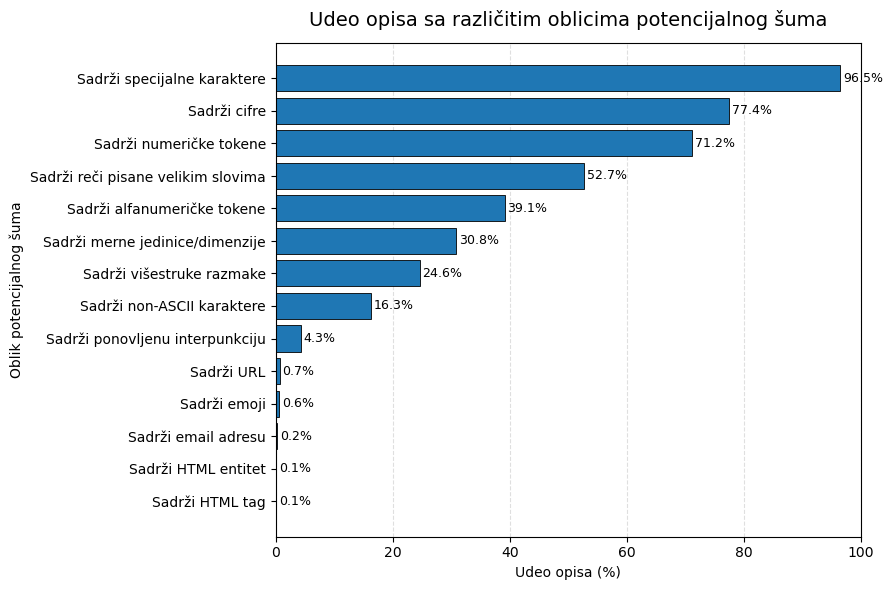

In [45]:
fig, ax = plt.subplots(figsize=(9, 6))

plot_data = noise_summary.sort_values("percentage_%", ascending=True)

ax.barh(
    plot_data["noise_indicator"],
    plot_data["percentage_%"],
    edgecolor="black",
    linewidth=0.6
)

for i, value in enumerate(plot_data["percentage_%"]):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, min(100, plot_data["percentage_%"].max() + 10))
ax.set_title("Udeo opisa sa različitim oblicima potencijalnog šuma", fontsize=14, pad=12)
ax.set_xlabel("Udeo opisa (%)")
ax.set_ylabel("Oblik potencijalnog šuma")
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Grafikon pokazuje da su najčešći oblici potencijalnog šuma u opisima proizvoda specijalni karakteri, cifre i numerički tokeni. Specijalni karakteri se pojavljuju u 96.49% opisa, što je očekivano za e-commerce tekstove jer opisi često sadrže zagrade, navodnike, crtice, oznake dimenzija i formatiranje.

Cifre se pojavljuju u 77.39% opisa, a numerički tokeni u 71.17% opisa. To ukazuje da veliki deo proizvoda sadrži informacije kao što su dimenzije, količine, veličine, brojevi modela ili tehničke specifikacije. Alfanumerički tokeni se pojavljuju u 39.13% opisa, dok se merne jedinice i dimenzije pojavljuju u 30.81% opisa.

URL-ovi, email adrese, HTML tagovi i HTML entiteti javljaju se veoma retko, pa ne predstavljaju dominantan problem u ovom skupu podataka. Ipak, njihovo prisustvo je važno evidentirati jer takvi elementi uglavnom nisu korisni za klasifikaciju i mogu se ukloniti tokom predobrade.

In [46]:
noise_count_summary = df_noise[
    [
        "digit_count",
        "special_char_count",
        "uppercase_word_count",
        "numeric_token_count",
        "alphanumeric_token_count"
    ]
].describe().T

display(noise_count_summary.round(2))

,count,mean,std,min,25%,50%,75%,max
digit_count,27802.0,10.43,19.60,0.0,1.0,5.0,12.0,574.0
special_char_count,27802.0,23.18,41.52,0.0,6.0,13.0,28.0,1409.0
uppercase_word_count,27802.0,2.53,6.43,0.0,0.0,1.0,2.0,228.0
numeric_token_count,27802.0,3.54,6.14,0.0,0.0,2.0,4.0,229.0
alphanumeric_token_count,27802.0,1.63,4.32,0.0,0.0,0.0,1.0,152.0


Opisne statistike pokazuju da prosečan opis sadrži oko 10 cifara i 23 specijalna karaktera, ali su maksimalne vrednosti znatno veće. To ukazuje da postoje pojedinačni opisi sa velikim brojem specifikacija, dimenzija, oznaka i formatiranja. Medijana za alfanumeričke tokene je 0, ali je prosek 1.63, što znači da ih veliki broj opisa nema, dok ih određeni opisi sadrže u većem broju. Ovo je tipično za e-commerce podatke, gde se šifre modela i tehničke oznake ne pojavljuju ravnomerno u svim kategorijama.

In [47]:
noise_by_category = (
    df_noise
    .groupby("category")
    .agg(
        examples=("description", "count"),
        has_digits_pct=("has_digits", lambda x: x.mean() * 100),
        has_alphanumeric_tokens_pct=("has_alphanumeric_tokens", lambda x: x.mean() * 100),
        has_measurement_pattern_pct=("has_measurement_pattern", lambda x: x.mean() * 100),
        has_uppercase_words_pct=("has_uppercase_words", lambda x: x.mean() * 100),
        has_special_chars_pct=("has_special_chars", lambda x: x.mean() * 100),
        has_non_ascii_pct=("has_non_ascii", lambda x: x.mean() * 100)
    )
    .sort_values("has_alphanumeric_tokens_pct", ascending=False)
)

display(noise_by_category.round(2))

,examples,has_digits_pct,has_alphanumeric_tokens_pct,has_measurement_pattern_pct,has_uppercase_words_pct,has_special_chars_pct,has_non_ascii_pct
category,,,,,,,
Electronics,5308,95.05,78.18,60.74,82.80,98.72,19.80
Household,10564,88.20,43.81,43.04,47.87,98.71,14.98
Clothing & Accessories,5674,60.57,20.67,10.10,38.61,97.73,8.94
Books,6256,59.41,14.85,3.55,48.03,89.74,22.09


Analiza po kategorijama pokazuje da su oblici šuma jasno povezani sa tipom proizvoda. Kategorija `Electronics` ima najveći udeo opisa sa ciframa (95.05%), alfanumeričkim tokenima (78.18%), mernim jedinicama i dimenzijama (60.74%) i rečima pisanim velikim slovima (82.80%). Ovo je očekivano jer elektronski proizvodi često sadrže nazive modela, tehničke specifikacije, memoriju, kapacitet, standarde i kompatibilnost uređaja.

Kategorija `Household` takođe ima visok udeo cifara i dimenzija, što se može povezati sa veličinama proizvoda, materijalima, pakovanjima i dimenzijama. `Books` ima znatno manje alfanumeričkih tokena i mernih jedinica, ali relativno visok udeo non-ASCII karaktera, što može biti posledica imena autora, naslova, stranih izraza i specijalnih znakova. `Clothing & Accessories` ima niže vrednosti za većinu tehničkih indikatora šuma, što je u skladu sa kraćim i jednostavnijim opisima ove kategorije.

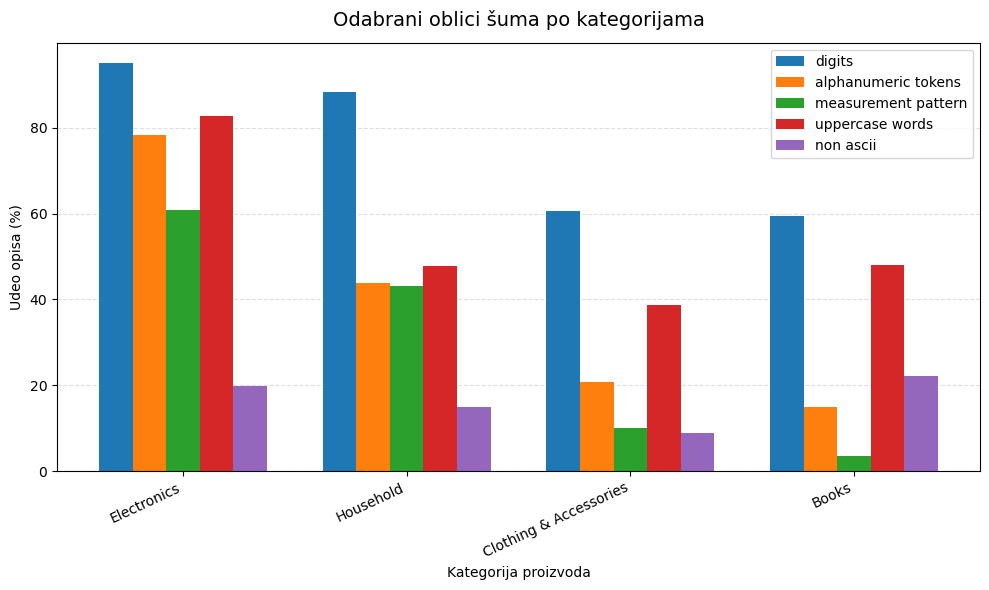

In [48]:
selected_noise_columns = [
    "has_digits_pct",
    "has_alphanumeric_tokens_pct",
    "has_measurement_pattern_pct",
    "has_uppercase_words_pct",
    "has_non_ascii_pct"
]

noise_by_category_plot = noise_by_category[selected_noise_columns].copy()

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(noise_by_category_plot.index))
width = 0.15

for i, column in enumerate(selected_noise_columns):
    ax.bar(
        x + i * width,
        noise_by_category_plot[column],
        width,
        label=column.replace("_pct", "").replace("has_", "").replace("_", " ")
    )

ax.set_xticks(x + width * (len(selected_noise_columns) - 1) / 2)
ax.set_xticklabels(noise_by_category_plot.index, rotation=25, ha="right")

ax.set_title("Odabrani oblici šuma po kategorijama", fontsize=14, pad=12)
ax.set_xlabel("Kategorija proizvoda")
ax.set_ylabel("Udeo opisa (%)")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

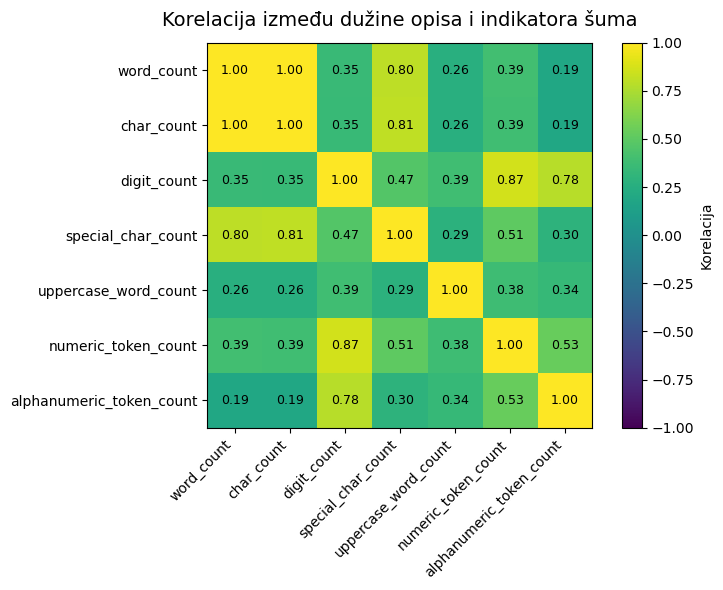

In [49]:
noise_corr_columns = [
    "word_count",
    "char_count",
    "digit_count",
    "special_char_count",
    "uppercase_word_count",
    "numeric_token_count",
    "alphanumeric_token_count"
]

noise_corr = df_noise[noise_corr_columns].corr()

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(noise_corr, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(noise_corr_columns)))
ax.set_yticks(np.arange(len(noise_corr_columns)))

ax.set_xticklabels(noise_corr_columns, rotation=45, ha="right")
ax.set_yticklabels(noise_corr_columns)

for i in range(len(noise_corr_columns)):
    for j in range(len(noise_corr_columns)):
        ax.text(
            j, i,
            f"{noise_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_title("Korelacija između dužine opisa i indikatora šuma", fontsize=14, pad=12)

cbar = plt.colorbar(im)
cbar.set_label("Korelacija")

plt.tight_layout()
plt.show()

Korelaciona matrica pokazuje da su pojedini indikatori šuma povezani sa dužinom opisa. Najjača povezanost vidi se između `word_count` i `char_count`, što je očekivano jer obe mere opisuju dužinu teksta. `special_char_count` je takođe snažno povezan sa dužinom opisa, što znači da duži tekstovi prirodno sadrže više zagrada, crtica, navodnika i drugih znakova formatiranja.

Visoka korelacija između `digit_count` i `numeric_token_count` potvrđuje da su numerički elementi čest deo opisa proizvoda. Povezanost između `digit_count` i `alphanumeric_token_count` pokazuje da se cifre često pojavljuju u oznakama modela, dimenzijama i tehničkim zapisima. Zbog toga ove elemente ne treba automatski uklanjati, već ih pažljivo tretirati u fazi predobrade.

In [50]:
def show_pattern_examples(pattern, title, n=1, flags=re.IGNORECASE):
    print("=" * 120)
    print(title)
    print("=" * 120)
    
    shown = 0
    
    for _, row in df_noise.iterrows():
        text = row["description"]
        match = re.search(pattern, text, flags)
        
        if match:
            start = max(match.start() - 120, 0)
            end = min(match.end() + 180, len(text))
            snippet = text[start:end]
            
            print(f"\nKategorija: {row['category']}")
            print(f"Pronađeni obrazac: {match.group(0)}")
            print(snippet)
            print("-" * 120)
            
            shown += 1
            
            if shown >= n:
                break
    
    if shown == 0:
        print("Nema primera za ovaj obrazac.")


show_pattern_examples(
    r"\b\w*[A-Za-z]\w*\d\w*|\w*\d\w*[A-Za-z]\w*\b",
    "Primer alfanumeričkog tokena"
)

show_pattern_examples(
    r"\b\d+(?:\.\d+)?\s?(cm|mm|m|inch|inches|kg|g|mg|ml|l|gb|mb|mah|hz|khz|mhz|ghz|v|w|x)\b",
    "Primer dimenzije ili merne jedinice"
)

show_pattern_examples(
    r"<[^>]+>",
    "Primer HTML taga",
    flags=0
)

show_pattern_examples(
    r"https?://|www\.",
    "Primer URL adrese"
)

show_pattern_examples(
    r"[^\x00-\x7F\s]+",
    "Primer vidljivog non-ASCII karaktera",
    flags=0
)

Primer alfanumeričkog tokena

Kategorija: Household
Pronađeni obrazac: SAO297
SAF 'Floral' Framed Painting (Wood, 30 inch x 10 inch, Special Effect UV Print Textured, SAO297) Painting made up in synthetic frame with UV textured print which gives multi effects and attracts towards it. This is an special series of paintings which makes your wall very be
------------------------------------------------------------------------------------------------------------------------
Primer dimenzije ili merne jedinice

Kategorija: Household
Pronađeni obrazac: 8.7 X
Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. This is an special series of paintings which mak
------------------------------------------------------------------------------------------------------------------------
Primer HTML taga

Kategorija: Household
Pronađeni obrazac

Prikazani primeri potvrđuju da deo detektovanog šuma predstavlja domenski korisne informacije. Alfanumerički tokeni i dimenzije često označavaju modele, veličine ili tehničke karakteristike proizvoda, pa njihovo potpuno uklanjanje može dovesti do gubitka informacija. Sa druge strane, HTML tagovi i URL adrese uglavnom predstavljaju elemente koje je korisno ukloniti tokom predobrade. Vidljivi non-ASCII karakteri, kao što je simbol `©`, zahtevaju pažljiviju Unicode normalizaciju.

## 3. Predobrada teksta

Nakon analize kvaliteta tekstualnih opisa proizvoda, u ovoj sekciji se primenjuju tehnike predobrade teksta. Cilj nije samo uklanjanje šuma, već i ispitivanje kako različite odluke u predobradi menjaju strukturu teksta, veličinu vokabulara i informacije koje će kasnije biti dostupne modelima.

Kod e-commerce opisa proizvoda posebno je važno pažljivo tretirati brojeve, dimenzije, šifre modela i alfanumeričke oznake, jer oni mogu biti i šum i korisna informacija za klasifikaciju.

In [51]:
import unicodedata
import html
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

### 3.1 Normalizacija teksta

Prvi korak predobrade je osnovna normalizacija teksta. U ovoj fazi uklanjaju se elementi koji uglavnom ne nose korisnu informaciju za klasifikaciju, kao što su HTML tagovi, URL adrese i email adrese. Takođe se primenjuje Unicode normalizacija, pretvaranje teksta u mala slova i uklanjanje višestrukih razmaka.

Ova varijanta se označava kao `basic_clean` i predstavlja osnovu za naredne korake predobrade.

In [52]:
df_preprocessed = df_quality[["category", "description"]].copy()
df_preprocessed["raw_text"] = df_preprocessed["description"]


def normalize_unicode_text(text):
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("\xa0", " ")
    return text


def basic_clean_text(text):
    text = str(text)
    text = html.unescape(text)
    text = normalize_unicode_text(text)
    
    # uklanjanje HTML tagova, URL adresa i email adresa
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " ", text)
    
    # lowercase i uklanjanje višestrukih razmaka
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


df_preprocessed["basic_clean"] = df_preprocessed["raw_text"].apply(basic_clean_text)

df_preprocessed[["category", "raw_text", "basic_clean"]].head()

,category,raw_text,basic_clean
0,Household,Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and att...,paper plane design framed wall hanging motivational office decor art prints (8.7 x 8.7 inch) - set of 4 painting made up in synthetic frame with uv textured print which gives multi effects and att...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x 10 inch, Special Effect UV Print Textured, SAO297) Painting made up in synthetic frame with UV textured print which gives multi effects and attracts t...","saf 'floral' framed painting (wood, 30 inch x 10 inch, special effect uv print textured, sao297) painting made up in synthetic frame with uv textured print which gives multi effects and attracts t..."
2,Household,"SAF 'UV Textured Modern Art Print Framed' Painting (Synthetic, 35 cm x 50 cm x 3 cm, Set of 3) Color:Multicolor | ...","saf 'uv textured modern art print framed' painting (synthetic, 35 cm x 50 cm x 3 cm, set of 3) color:multicolor | size:35 cm x 50 cm x 3 cm overview a beautiful painting involves the action or ski..."
3,Household,"SAF Flower Print Framed Painting (Synthetic, 13.5 inch x 22 inch, UV Textured, Set of 3, SANFSW4951) Color:Multicolor ...","saf flower print framed painting (synthetic, 13.5 inch x 22 inch, uv textured, set of 3, sanfsw4951) color:multicolor | size:35 cm x 50 cm x 2 cm a beautiful painting involves the action or skill ..."
4,Household,"Incredible Gifts India Wooden Happy Birthday Unique Personalized Gift (5 X 4 Inch) Size:4 x 5 Made Of Natural Imported Wood, Which Is Quite Solid With Light Particle Pattern & Is Soft Pale To Bl...","incredible gifts india wooden happy birthday unique personalized gift (5 x 4 inch) size:4 x 5 made of natural imported wood, which is quite solid with light particle pattern & is soft pale to blon..."


In [53]:
sample_idx = 0

print("Kategorija:", df_preprocessed.loc[sample_idx, "category"])
print("=" * 120)

print("\nOriginalni tekst:")
print(df_preprocessed.loc[sample_idx, "raw_text"][:1000])

print("\nBasic clean tekst:")
print(df_preprocessed.loc[sample_idx, "basic_clean"][:1000])

Kategorija: Household

Originalni tekst:
Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. This is an special series of paintings which makes your wall very beautiful and gives a royal touch. This painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. We use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. This innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. We print solely with top-notch 100% inks, to achieve brilliant and true colours. Due to their high level of uv resistance, our prints retain their beautiful colours for many years. Add colour and style to your living space with this digitally printed painting. Some ar

U prikazanom primeru se najjasnije vidi efekat pretvaranja teksta u mala slova, dok se struktura i sadržaj opisa uglavnom zadržavaju. `basic_clean`  uklanja HTML tagove, URL adrese, email adrese i višestruke razmake, ali zadržava brojeve, dimenzije, interpunkciju i oznake proizvoda. To je važno jer ti elementi u e-commerce domenu mogu biti korisni za klasifikaciju.

### 3.2 Tokenizacija

Tokenizacija je proces podele teksta na manje jedinice, odnosno tokene. U NLP zadacima najčešće se koriste:

- **word tokenizacija**, gde se tekst deli na reči i brojeve,
- **sentence tokenizacija**, gde se tekst deli na rečenice,
- **subword tokenizacija**, koja se koristi kod savremenih transformer modela, kao što su BERT-like modeli.

U klasičnim pristupima kao što su BoW i TF-IDF najčešće se koristi word tokenizacija. Sa druge strane, BERT-like modeli koriste subword tokenizaciju, što im omogućava da bolje obrade retke reči, složenice, greške u pisanju i domenski specifične tokene.

In [54]:
def word_tokenize_basic(text):
    return re.findall(r"\b\w+\b", str(text).lower())


def sentence_tokenize_simple(text):
    sentences = re.split(r"(?<![0-9])([.!?]+)(?![0-9])", str(text))
    sentences = [s.strip() for s in sentences if s.strip() and not re.match(r"^[.!?]+$", s)]
    return [s for s in sentences if len(s) > 10]


def simple_subword_demo(token):
    token = token.lower()
    if len(token) <= 6:
        return [token]
    subwords = [token[:4]]
    for i in range(4, len(token), 4):
        subwords.append("##" + token[i:i+4])
    return subwords

def subword_tokenize_text(text):
    tokens = word_tokenize_basic(text)
    result = []
    for token in tokens:
        result.extend(simple_subword_demo(token))
    return result

In [55]:
tokenization_example = df_preprocessed[
    df_preprocessed["basic_clean"].str.contains(r"\d", regex=True)
].iloc[0]["basic_clean"]

word_tokens_example = word_tokenize_basic(tokenization_example)
sentence_tokens_example = sentence_tokenize_simple(tokenization_example)

print("Primer teksta:")
print(tokenization_example[:700])

print("\nWord tokenizacija - prvih 40 tokena:")
print(word_tokens_example[:40])

print("\nSentence tokenizacija - prve 3 rečenice:")
for sentence in sentence_tokens_example[:3]:
    print("-", sentence[:250])

Primer teksta:
paper plane design framed wall hanging motivational office decor art prints (8.7 x 8.7 inch) - set of 4 painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. this is an special series of paintings which makes your wall very beautiful and gives a royal touch. this painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. we use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. this innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. we print 

Word tokenizacija - prvih 40 tokena:
['paper', 'plane', 'design', 'framed', 'wall', 'hanging', 'motivational', 'office', 'decor', 'art', 'prints', '8', '7', 'x', '8', '7', 'inch', 'set', 'of', '4', 'painting', 'made', 'up', 'in', 'synthetic', 'frame', 'with', 'uv', 'textured', 'prin

In [56]:
example_tokens = ["sanfsw4951", "wd80j6410as", "waterproofing",
                  "compatibility", "multicolor", "specifications"]

subword_demo = pd.DataFrame({
    "original_token": example_tokens,
    "subword_demo": [simple_subword_demo(token) for token in example_tokens]
})
display(subword_demo)

,original_token,subword_demo
0,sanfsw4951,"[sanf, ##sw49, ##51]"
1,wd80j6410as,"[wd80, ##j641, ##0as]"
2,waterproofing,"[wate, ##rpro, ##ofin, ##g]"
3,compatibility,"[comp, ##atib, ##ilit, ##y]"
4,multicolor,"[mult, ##icol, ##or]"
5,specifications,"[spec, ##ific, ##atio, ##ns]"


Za demonstraciju subword principa koriste se tokeni koji su karakteristični za e-commerce tekstove: šifre proizvoda, alfanumeričke oznake i duže složene reči. Prikazana funkcija nije pravi BERT tokenizer, već pojednostavljena ilustracija ideje da se retki ili složeni tokeni mogu razložiti na manje delove.

Primer pokazuje da word tokenizacija dimenziju `8.7 x 8.7 inch` deli na tokene `8`, `7`, `x`, `8`, `7`, `inch`, što može povećati broj numeričkih i kratkih tokena. Sentence tokenizacija uspešno izdvaja veće tekstualne celine, ali u ovom projektu klasifikacija koristi ceo opis proizvoda. Subword pristup je važan za BERT-like modele jer omogućava obradu retkih i složenih tokena kao što su šifre proizvoda i domenski specifični izrazi.

Word tokenizacija     — prosečan broj tokena po opisu:   115.5
Subword simulacija    — prosečan broj tokena po opisu:   156.2
Sentence tokenizacija — prosečan broj rečenica po opisu: 5.7
Povećanje subword simulacije u odnosu na word tokenizaciju: 35.2%


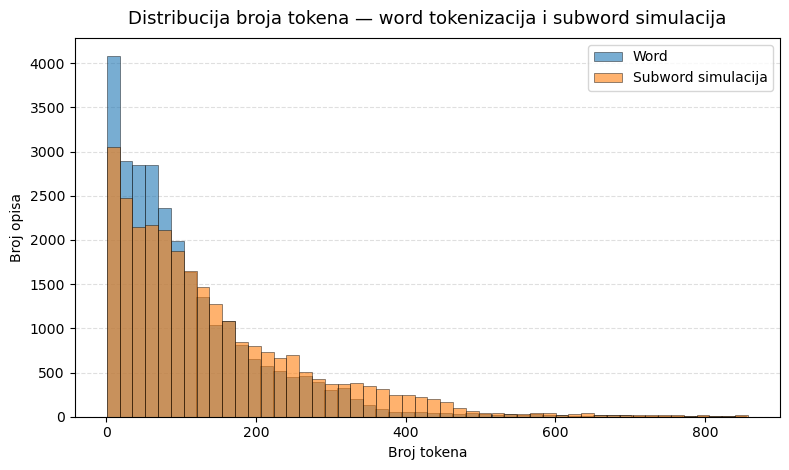

Prikaz je ograničen na 99. percentil: 857 tokena


In [57]:
word_counts = df_preprocessed["basic_clean"].apply(
    lambda x: len(word_tokenize_basic(x))
)
subword_counts = df_preprocessed["basic_clean"].apply(
    lambda x: len(subword_tokenize_text(x))
)
sent_counts = df_preprocessed["basic_clean"].apply(
    lambda x: len(sentence_tokenize_simple(x))
)

print(f"Word tokenizacija     — prosečan broj tokena po opisu:   {word_counts.mean():.1f}")
print(f"Subword simulacija    — prosečan broj tokena po opisu:   {subword_counts.mean():.1f}")
print(f"Sentence tokenizacija — prosečan broj rečenica po opisu: {sent_counts.mean():.1f}")
print(f"Povećanje subword simulacije u odnosu na word tokenizaciju: {(subword_counts.mean()/word_counts.mean()-1)*100:.1f}%")

upper_limit = max(word_counts.quantile(0.99), subword_counts.quantile(0.99))

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.hist(
    word_counts[word_counts <= upper_limit],
    bins=50,
    alpha=0.6,
    label="Word",
    edgecolor="black",
    linewidth=0.5
)

ax.hist(
    subword_counts[subword_counts <= upper_limit],
    bins=50,
    alpha=0.6,
    label="Subword simulacija",
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("Distribucija broja tokena — word tokenizacija i subword simulacija", fontsize=13, pad=10)
ax.set_xlabel("Broj tokena")
ax.set_ylabel("Broj opisa")
ax.legend()
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Prikaz je ograničen na 99. percentil: {upper_limit:.0f} tokena")

Pojednostavljena subword simulacija povećava prosečan broj tokena po opisu sa 115.5 na 156.2, odnosno za oko 35.2%. To je očekivano jer se duži i složeniji tokeni razlažu na više manjih delova. Kod pravih BERT-like modela subword tokenizacija se ne radi ovako ručno, već pomoću naučenog tokenizer-a, ali ovaj primer pokazuje zašto transformer modeli mogu bolje da obrade retke i domenski specifične tokene.

### 3.3 Uklanjanje stop-reči i filtriranje tokena

Nakon osnovne normalizacije i tokenizacije formiraju se dve dodatne varijante teksta:

- `alpha_only` — zadržavaju se samo alfabetski tokeni, čime se uklanjaju cifre, numerički tokeni i alfanumeričke šifre proizvoda;
- `no_stopwords` — iz `alpha_only` varijante uklanjaju se stop-reči, odnosno veoma česte funkcijske reči koje obično imaju malu diskriminativnu vrednost.

Uklanjanje numeričkih i alfanumeričkih tokena smanjuje šum i veličinu vokabulara, ali može ukloniti korisne informacije kao što su modeli proizvoda, dimenzije i tehničke specifikacije. Zato se različite varijante predobrade kasnije porede kroz modele, umesto da se unapred pretpostavi da je agresivnije čišćenje uvek bolje.

In [58]:
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "s", "t", "m", "re", "ve", "ll", "d"
})


def keep_alpha_only_text(text):
    tokens = word_tokenize_basic(text)
    tokens = [token for token in tokens if token.isalpha()]
    return " ".join(tokens)


def remove_stopwords_text(text):
    tokens = word_tokenize_basic(text)
    tokens = [
        token for token in tokens
        if token not in custom_stopwords and len(token) > 1
    ]
    return " ".join(tokens)


df_preprocessed["alpha_only"] = df_preprocessed["basic_clean"].apply(keep_alpha_only_text)

df_preprocessed["no_stopwords"] = df_preprocessed["alpha_only"].apply(remove_stopwords_text)

df_preprocessed[["category", "basic_clean", "alpha_only", "no_stopwords"]].head()

,category,basic_clean,alpha_only,no_stopwords
0,Household,paper plane design framed wall hanging motivational office decor art prints (8.7 x 8.7 inch) - set of 4 painting made up in synthetic frame with uv textured print which gives multi effects and att...,paper plane design framed wall hanging motivational office decor art prints x inch set of painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards ...,paper plane design framed wall hanging motivational office decor art prints inch set painting synthetic frame uv textured print gives multi effects attracts special series paintings makes wall bea...
1,Household,"saf 'floral' framed painting (wood, 30 inch x 10 inch, special effect uv print textured, sao297) painting made up in synthetic frame with uv textured print which gives multi effects and attracts t...",saf floral framed painting wood inch x inch special effect uv print textured painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it this is an...,saf floral framed painting wood inch inch special effect uv print textured painting synthetic frame uv textured print gives multi effects attracts special series paintings makes wall beautiful giv...
2,Household,"saf 'uv textured modern art print framed' painting (synthetic, 35 cm x 50 cm x 3 cm, set of 3) color:multicolor | size:35 cm x 50 cm x 3 cm overview a beautiful painting involves the action or ski...",saf uv textured modern art print framed painting synthetic cm x cm x cm set of color multicolor size cm x cm x cm overview a beautiful painting involves the action or skill of using paint in the r...,saf uv textured modern art print framed painting synthetic cm cm cm set color multicolor size cm cm cm overview beautiful painting involves action skill using paint right manner end product pictur...
3,Household,"saf flower print framed painting (synthetic, 13.5 inch x 22 inch, uv textured, set of 3, sanfsw4951) color:multicolor | size:35 cm x 50 cm x 2 cm a beautiful painting involves the action or skill ...",saf flower print framed painting synthetic inch x inch uv textured set of color multicolor size cm x cm x cm a beautiful painting involves the action or skill of using paint in the right manner he...,saf flower print framed painting synthetic inch inch uv textured set color multicolor size cm cm cm beautiful painting involves action skill using paint right manner end product picture speak thou...
4,Household,"incredible gifts india wooden happy birthday unique personalized gift (5 x 4 inch) size:4 x 5 made of natural imported wood, which is quite solid with light particle pattern & is soft pale to blon...",incredible gifts india wooden happy birthday unique personalized gift x inch size x made of natural imported wood which is quite solid with light particle pattern is soft pale to blond colour your...,incredible gifts india wooden happy birthday unique personalized gift inch size natural imported wood quite solid light particle pattern soft pale blond colour uploaded photo look amazing beautifu...


In [59]:
sample_idx = 0

print("Kategorija:", df_preprocessed.loc[sample_idx, "category"])
print("=" * 120)

for column in ["basic_clean", "alpha_only", "no_stopwords"]:
    print(f"\n{column}:")
    print(df_preprocessed.loc[sample_idx, column][:1000])
    print("-" * 120)

Kategorija: Household

basic_clean:
paper plane design framed wall hanging motivational office decor art prints (8.7 x 8.7 inch) - set of 4 painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. this is an special series of paintings which makes your wall very beautiful and gives a royal touch. this painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. we use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. this innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. we print solely with top-notch 100% inks, to achieve brilliant and true colours. due to their high level of uv resistance, our prints retain their beautiful colours for many years. add colour and style to your living space with this digitally printed painting. some are for

U prikazanom primeru `alpha_only` uklanja numeričke vrednosti kao što su `8.7`, `4` i `100`, ali zadržava alfabetske delove dimenzija kao što su `x` i `inch`. Varijanta `no_stopwords` dodatno uklanja česte funkcijske reči, pa tekst postaje kraći i sadržajno koncentrisaniji. Međutim, deo informacija se gubi, pa će se kasnije proveriti kako ove odluke utiču na performanse modela.

### 3.4 Stemming i lematizacija

Stemming i lematizacija su tehnike kojima se različiti oblici iste ili slične reči svode na zajednički oblik. Time se smanjuje veličina vokabulara i broj različitih zapisa iste reči.

**Stemming** mehanički skraćuje reči na osnovu pravila, pa često daje oblike koji nisu prave reči, npr. `beautiful → beauti`.

**Lematizacija** pokušava da reč svede na osnovni gramatički oblik. U ovoj analizi stemming se izvodi pomoću `PorterStemmer`, dok se lematizacija izvodi pomoću biblioteke `spaCy`, koja koristi POS informacije i zato daje prirodnije oblike reči od jednostavne WordNet lematizacije bez POS tagova.

Obe tehnike se primenjuju nad `no_stopwords` varijantom teksta.

In [60]:
# instalacija spaCy modela
#!pip install spacy
#!python -m spacy download en_core_web_sm

In [61]:
import spacy
from functools import lru_cache
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [62]:
@lru_cache(maxsize=None)
def stem_token(token):
    return stemmer.stem(token)


def stem_text(text):
    tokens = word_tokenize_basic(text)
    return " ".join(stem_token(token) for token in tokens)


def lemmatize_texts_spacy(texts, batch_size=500):
    lemmatized_texts = []
    
    for doc in nlp.pipe(texts, batch_size=batch_size):
        lemmas = [
            token.lemma_.lower()
            for token in doc
            if not token.is_space and token.lemma_ != "-PRON-"
        ]
        lemmatized_texts.append(" ".join(lemmas))
    
    return lemmatized_texts

In [63]:
df_preprocessed["stemming"] = df_preprocessed["no_stopwords"].apply(stem_text)

df_preprocessed["lemmatization"] = lemmatize_texts_spacy(
    df_preprocessed["no_stopwords"].tolist()
)

df_preprocessed[["category", "no_stopwords", "stemming", "lemmatization"]].head()

,category,no_stopwords,stemming,lemmatization
0,Household,paper plane design framed wall hanging motivational office decor art prints inch set painting synthetic frame uv textured print gives multi effects attracts special series paintings makes wall bea...,paper plane design frame wall hang motiv offic decor art print inch set paint synthet frame uv textur print give multi effect attract special seri paint make wall beauti give royal touch paint rea...,paper plane design frame wall hang motivational office decor art print inch set paint synthetic frame uv texture print give multi effect attract special series painting make wall beautiful give ro...
1,Household,saf floral framed painting wood inch inch special effect uv print textured painting synthetic frame uv textured print gives multi effects attracts special series paintings makes wall beautiful giv...,saf floral frame paint wood inch inch special effect uv print textur paint synthet frame uv textur print give multi effect attract special seri paint make wall beauti give royal touch perfect gift...,saf floral framed paint wood inch inch special effect uv print texture paint synthetic frame uv texture print give multi effect attract special series painting make wall beautiful give royal touch...
2,Household,saf uv textured modern art print framed painting synthetic cm cm cm set color multicolor size cm cm cm overview beautiful painting involves action skill using paint right manner end product pictur...,saf uv textur modern art print frame paint synthet cm cm cm set color multicolor size cm cm cm overview beauti paint involv action skill use paint right manner end product pictur speak thousand wo...,saf uv texture modern art print frame paint synthetic cm cm cm set color multicolor size cm cm cm overview beautiful painting involve action skill use paint right manner end product picture speak ...
3,Household,saf flower print framed painting synthetic inch inch uv textured set color multicolor size cm cm cm beautiful painting involves action skill using paint right manner end product picture speak thou...,saf flower print frame paint synthet inch inch uv textur set color multicolor size cm cm cm beauti paint involv action skill use paint right manner end product pictur speak thousand word say art t...,saf flower print frame paint synthetic inch inch uv texture set color multicolor size cm cm cm beautiful painting involve action skill use paint right manner end product picture speak thousand wor...
4,Household,incredible gifts india wooden happy birthday unique personalized gift inch size natural imported wood quite solid light particle pattern soft pale blond colour uploaded photo look amazing beautifu...,incred gift india wooden happi birthday uniqu person gift inch size natur import wood quit solid light particl pattern soft pale blond colour upload photo look amaz beauti laser engrav popular uni...,incredible gift india wooden happy birthday unique personalize gift inch size natural import wood quite solid light particle pattern soft pale blond colour uploaded photo look amazing beautiful la...


Na istom opisu proizvoda vidi se da stemming agresivno skraćuje veliki broj tokena, dok lematizacija uglavnom zadržava čitljivije oblike reči. Zbog toga je ovaj prikaz koristan za poređenje gubitka interpretabilnosti kod različitih tehnika normalizacije.

In [64]:
sample_idx = 0

print("Kategorija:", df_preprocessed.loc[sample_idx, "category"])
print("=" * 120)

for column in ["no_stopwords", "stemming", "lemmatization"]:
    print(f"\n{column}:")
    print(df_preprocessed.loc[sample_idx, column][:1000])
    print("-" * 120)

Kategorija: Household

no_stopwords:
paper plane design framed wall hanging motivational office decor art prints inch set painting synthetic frame uv textured print gives multi effects attracts special series paintings makes wall beautiful gives royal touch painting ready hang proud possess unique painting niche apart use modern efficient printing technology prints inks precision epson roland hp printers innovative hd printing technique results durable spectacular looking prints highest lifetime print solely notch inks achieve brilliant true colours high level uv resistance prints retain beautiful colours years add colour style living space digitally printed painting pleasure eternal bliss bring home elegant print lushed rich colors makes sheer elegance friends family treasured forever lucky recipient liven place intriguing paintings high definition hd graphic digital prints home office room
-----------------------------------------------------------------------------------------------

In [65]:
sample_phrases = [
    "painting paintings",
    "printed printing",
    "beautiful colours colors",
    "technical specifications",
    "product features",
    "compatible accessories",
    "children batteries",
    "running devices",
    "designed products"
]

comparison_rows = []

for phrase in sample_phrases:
    doc = nlp(phrase)
    
    for token in doc:
        comparison_rows.append({
            "original_token": token.text,
            "stemming": stem_token(token.text.lower()),
            "lemmatization": token.lemma_.lower()
        })

stemming_lemmatization_examples = pd.DataFrame(comparison_rows).drop_duplicates()

display(stemming_lemmatization_examples)

,original_token,stemming,lemmatization
0,painting,paint,paint
1,paintings,paint,painting
2,printed,print,print
3,printing,print,printing
4,beautiful,beauti,beautiful
5,colours,colour,colour
6,colors,color,color
7,technical,technic,technical
8,specifications,specif,specification
9,product,product,product


Primeri pojedinačnih tokena jasno pokazuju razliku između stemming-a i lematizacije. Stemming svodi reči na kraće osnove, npr. `beautiful → beauti`, `specifications → specif`, `accessories → accessori`, što smanjuje vokabular, ali otežava interpretaciju. Lematizacija pomoću `spaCy` zadržava prirodnije oblike, npr. `batteries → battery`, `children → child`, `running → run`, `designed → design`. Zbog toga je lematizacija blaža i interpretabilnija, ali manje agresivno smanjuje broj jedinstvenih tokena.

In [66]:
def token_stats_for_column(text_series):
    tokenized = text_series.apply(word_tokenize_basic)
    all_tokens = [token for tokens in tokenized for token in tokens]
    token_counter = Counter(all_tokens)
    
    return {
        "total_tokens": len(all_tokens),
        "vocabulary_size": len(token_counter),
        "rare_tokens_freq_1": sum(1 for token, freq in token_counter.items() if freq == 1),
        "mean_words_per_doc": tokenized.apply(len).mean(),
        "median_words_per_doc": tokenized.apply(len).median()
    }

stem_lemma_stats = pd.DataFrame({
    "no_stopwords": token_stats_for_column(df_preprocessed["no_stopwords"]),
    "stemming": token_stats_for_column(df_preprocessed["stemming"]),
    "lemmatization": token_stats_for_column(df_preprocessed["lemmatization"])
}).T

stem_lemma_stats["rare_tokens_share_%"] = (
    stem_lemma_stats["rare_tokens_freq_1"] / stem_lemma_stats["vocabulary_size"] * 100
)

display(stem_lemma_stats.round(2))

base = stem_lemma_stats.loc["no_stopwords", "vocabulary_size"]
for variant in ["stemming", "lemmatization"]:
    v = stem_lemma_stats.loc[variant, "vocabulary_size"]
    print(f"{variant:<15}: {int(v):,} tokena  (redukcija u odnosu na no_stopwords: {(1 - v/base)*100:.1f}%)")

,total_tokens,vocabulary_size,rare_tokens_freq_1,mean_words_per_doc,median_words_per_doc,rare_tokens_share_%
no_stopwords,1882828.0,63554.0,24895.0,67.72,47.0,39.17
stemming,1882828.0,47530.0,19870.0,67.72,47.0,41.81
lemmatization,1883050.0,55876.0,23253.0,67.73,47.0,41.62


stemming       : 47,530 tokena  (redukcija u odnosu na no_stopwords: 25.2%)
lemmatization  : 55,876 tokena  (redukcija u odnosu na no_stopwords: 12.1%)


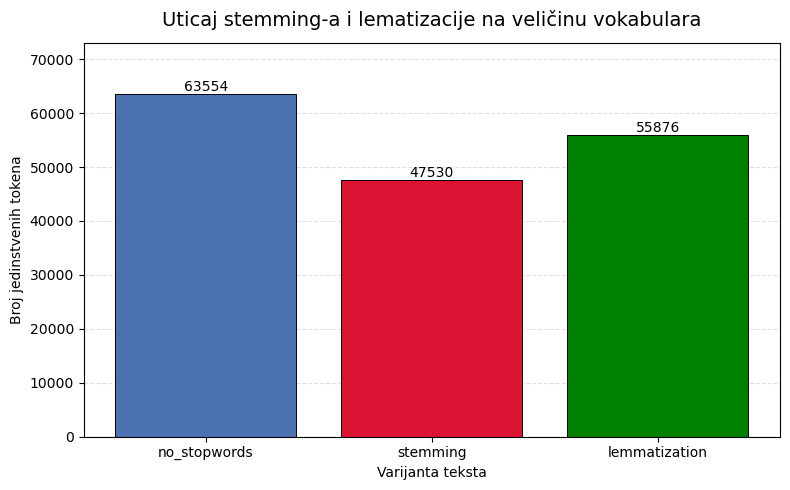

In [67]:
colors = ["#4C72B0", "#DC1434", "#008000"]
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    stem_lemma_stats.index,
    stem_lemma_stats["vocabulary_size"],
    color=colors,
    edgecolor="black",
    linewidth=0.7
)

for bar, value in zip(bars, stem_lemma_stats["vocabulary_size"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylim(0, stem_lemma_stats["vocabulary_size"].max() * 1.15)
ax.set_title("Uticaj stemming-a i lematizacije na veličinu vokabulara", fontsize=14, pad=12)
ax.set_xlabel("Varijanta teksta")
ax.set_ylabel("Broj jedinstvenih tokena")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Tabela i grafikon pokazuju da stemming najviše smanjuje veličinu vokabulara: sa 63554 tokena u `no_stopwords` varijanti na 47530 tokena, što predstavlja redukciju od 25.2%. Lematizacija smanjuje vokabular na 55876 tokena, odnosno za 12.1%.

Ovaj rezultat potvrđuje da je stemming agresivniji pristup, jer spaja veći broj različitih oblika reči, ali uz cenu slabije čitljivosti tokena. Lematizacija zadržava više različitih tokena, ali su oni gramatički prirodniji i lakši za interpretaciju. Zbog toga će u kasnijem eksperimentalnom delu biti korisno porediti obe varijante, umesto da se unapred pretpostavi koja je bolja za klasifikaciju.

### 3.5 Analiza nakon predobrade teksta i finalni pipeline

U ovoj sekciji se objedinjavanju sve prethodno definisane varijante predobrade i formira finalni skup koji će se koristiti u eksperimentalnom delu. Cilj nije da se unapred izabere samo jedna verzija teksta, već da se kasnije kroz modele proveri kako različiti nivoi predobrade utiču na klasifikaciju proizvoda.

Posebno se prati kako se kroz faze predobrade menjaju veličina vokabulara, ukupan broj tokena, udeo retkih tokena i prosečna dužina opisa.

In [68]:
def preprocess_pipeline(text, alpha_only=False, remove_stops=False, stemming=False, lemmatization=False):
    if stemming and lemmatization:
        raise ValueError("Stemming i lematizacija ne treba da budu uključeni istovremeno.")
    
    #početna normalizacija
    text = basic_clean_text(text)
    
    #word tokenizacija
    tokens = word_tokenize_basic(text)
    
    # filtriranje samo alfabetskih tokena
    if alpha_only:
        tokens = [token for token in tokens if token.isalpha()]
    
    #uklanjanje stop-reči
    if remove_stops:
        tokens = [
            token for token in tokens
            if token not in custom_stopwords and len(token) > 1
        ]
    
    #stemming
    if stemming:
        tokens = [stem_token(token) for token in tokens]
    
    #lematizacija pomoću spaCy
    if lemmatization:
        doc = nlp(" ".join(tokens))
        tokens = [
            token.lemma_.lower()
            for token in doc
            if not token.is_space and token.lemma_ != "-PRON-"
        ]
    
    return " ".join(tokens)

Funkcija `preprocess_pipeline` predstavlja objedinjeni tok predobrade koji se može primeniti na novi tekstualni opis proizvoda. U zavisnosti od izabranih parametara, pipeline može da izvrši osnovnu normalizaciju, filtriranje alfabetskih tokena, uklanjanje stop-reči, stemming ili lematizaciju.

Za postojeći dataset varijante teksta su već kreirane u prethodnim koracima, pa se u nastavku samo objedinjuju u `modeling_df`, koji će biti osnova za modelovanje.

In [69]:
modeling_df = df_preprocessed[
    [
        "category",
        "raw_text",
        "basic_clean",
        "alpha_only",
        "no_stopwords",
        "stemming",
        "lemmatization"
    ]
].copy()

modeling_df = modeling_df.rename(columns={
    "raw_text": "text_raw",
    "basic_clean": "text_normalized",
    "alpha_only": "text_alpha",
    "no_stopwords": "text_no_stop",
    "stemming": "text_stemmed",
    "lemmatization": "text_lemmatized"
})

display(modeling_df.head())

,category,text_raw,text_normalized,text_alpha,text_no_stop,text_stemmed,text_lemmatized
0,Household,Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and att...,paper plane design framed wall hanging motivational office decor art prints (8.7 x 8.7 inch) - set of 4 painting made up in synthetic frame with uv textured print which gives multi effects and att...,paper plane design framed wall hanging motivational office decor art prints x inch set of painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards ...,paper plane design framed wall hanging motivational office decor art prints inch set painting synthetic frame uv textured print gives multi effects attracts special series paintings makes wall bea...,paper plane design frame wall hang motiv offic decor art print inch set paint synthet frame uv textur print give multi effect attract special seri paint make wall beauti give royal touch paint rea...,paper plane design frame wall hang motivational office decor art print inch set paint synthetic frame uv texture print give multi effect attract special series painting make wall beautiful give ro...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x 10 inch, Special Effect UV Print Textured, SAO297) Painting made up in synthetic frame with UV textured print which gives multi effects and attracts t...","saf 'floral' framed painting (wood, 30 inch x 10 inch, special effect uv print textured, sao297) painting made up in synthetic frame with uv textured print which gives multi effects and attracts t...",saf floral framed painting wood inch x inch special effect uv print textured painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it this is an...,saf floral framed painting wood inch inch special effect uv print textured painting synthetic frame uv textured print gives multi effects attracts special series paintings makes wall beautiful giv...,saf floral frame paint wood inch inch special effect uv print textur paint synthet frame uv textur print give multi effect attract special seri paint make wall beauti give royal touch perfect gift...,saf floral framed paint wood inch inch special effect uv print texture paint synthetic frame uv texture print give multi effect attract special series painting make wall beautiful give royal touch...
2,Household,"SAF 'UV Textured Modern Art Print Framed' Painting (Synthetic, 35 cm x 50 cm x 3 cm, Set of 3) Color:Multicolor | ...","saf 'uv textured modern art print framed' painting (synthetic, 35 cm x 50 cm x 3 cm, set of 3) color:multicolor | size:35 cm x 50 cm x 3 cm overview a beautiful painting involves the action or ski...",saf uv textured modern art print framed painting synthetic cm x cm x cm set of color multicolor size cm x cm x cm overview a beautiful painting involves the action or skill of using paint in the r...,saf uv textured modern art print framed painting synthetic cm cm cm set color multicolor size cm cm cm overview beautiful painting involves action skill using paint right manner end product pictur...,saf uv textur modern art print frame paint synthet cm cm cm set color multicolor size cm cm cm overview beauti paint involv action skill use paint right manner end product pictur speak thousand wo...,saf uv texture modern art print frame paint synthetic cm cm cm set color multicolor size cm cm cm overview beautiful painting involve action skill use paint right manner end product picture speak ...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 13.5 inch x 22 inch, UV Textured, Set of 3, SANFSW4951) Color:Multicolor ...","saf flower print framed painting (synthetic, 13.5 inch x 22 inch, uv textured, set of 3, sanfsw4951) color:multicolor | size:35 cm x 50 cm x 2 cm a beautiful painting involves the action or skill ...",saf flower p

In [70]:
final_text_columns = [
    "text_raw",
    "text_normalized",
    "text_alpha",
    "text_no_stop",
    "text_stemmed",
    "text_lemmatized"
]

print("Prosečna dužina po verziji teksta:")
for col in final_text_columns:
    avg_len = modeling_df[col].apply(lambda x: len(word_tokenize_basic(x))).mean()
    print(f"{col:<20} {avg_len:.1f} tokena")

Prosečna dužina po verziji teksta:
text_raw             115.6 tokena
text_normalized      115.5 tokena
text_alpha           110.0 tokena
text_no_stop         67.7 tokena
text_stemmed         67.7 tokena
text_lemmatized      67.7 tokena


Prosečna dužina opisa se vrlo malo menja između `text_raw` i `text_normalized`, jer osnovna normalizacija uglavnom sređuje zapis, ali ne uklanja veći broj tokena. Varijanta `text_alpha` smanjuje prosečnu dužinu sa 115.5 na 110.0 tokena, jer uklanja numeričke i alfanumeričke tokene.

Najveći pad prosečne dužine nastaje kod `text_no_stop`, gde prosečan opis ima 67.7 tokena. To pokazuje da stop-reči čine veliki deo ukupnog teksta. Stemming i lematizacija ne menjaju dužinu opisa, jer ne uklanjaju tokene, već menjaju njihov oblik.

In [71]:
def final_text_statistics(text_series):
    tokenized = text_series.apply(word_tokenize_basic)
    all_tokens = [token for tokens in tokenized for token in tokens]
    token_counter = Counter(all_tokens)
    word_counts = tokenized.apply(len)
    
    total_tokens = len(all_tokens)
    vocabulary_size = len(token_counter)
    rare_tokens = sum(1 for token, freq in token_counter.items() if freq == 1)
    
    return {
        "total_tokens": total_tokens,
        "vocabulary_size": vocabulary_size,
        "rare_tokens_freq_1": rare_tokens,
        "rare_tokens_share_%": rare_tokens / vocabulary_size * 100 if vocabulary_size > 0 else 0,
        "mean_words_per_doc": word_counts.mean(),
        "median_words_per_doc": word_counts.median()
    }


final_preprocessing_summary = pd.DataFrame({
    col: final_text_statistics(modeling_df[col])
    for col in final_text_columns
}).T

final_preprocessing_summary["vocab_reduction_vs_raw_%"] = (
    1 - final_preprocessing_summary["vocabulary_size"]
    / final_preprocessing_summary.loc["text_raw", "vocabulary_size"]
) * 100

display(final_preprocessing_summary.round(2))

,total_tokens,vocabulary_size,rare_tokens_freq_1,rare_tokens_share_%,mean_words_per_doc,median_words_per_doc,vocab_reduction_vs_raw_%
text_raw,3213073.0,79034.0,34072.0,43.11,115.57,78.0,0.00
text_normalized,3211514.0,78876.0,33985.0,43.09,115.51,78.0,0.20
text_alpha,3056902.0,63989.0,24909.0,38.93,109.95,73.0,19.04
text_no_stop,1882828.0,63554.0,24895.0,39.17,67.72,47.0,19.59
text_stemmed,1882828.0,47530.0,19870.0,41.81,67.72,47.0,39.86
text_lemmatized,1883050.0,55876.0,23253.0,41.62,67.73,47.0,29.30


Tabela pokazuje da `text_normalized` skoro ne menja veličinu vokabulara u odnosu na originalni tekst, jer se u ovoj fazi radi samo blaga normalizacija. Veći efekat se vidi kod `text_alpha`, gde se vokabular smanjuje za 19.04%, prvenstveno zbog uklanjanja brojeva, dimenzija i alfanumeričkih oznaka.

Uklanjanje stop-reči značajno smanjuje ukupan broj tokena, ali samo malo dodatno smanjuje vokabular u odnosu na `text_alpha`. To potvrđuje da stop-reči imaju veliku učestalost, ali ne čine veliki deo jedinstvenih tokena. Najveću redukciju vokabulara daje `text_stemmed`, dok `text_lemmatized` predstavlja blažu i interpretabilniju varijantu.

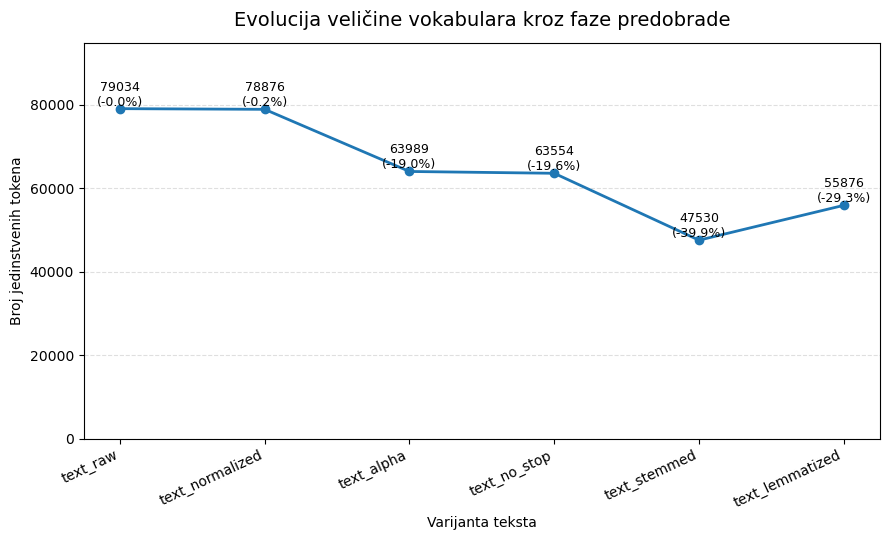

In [72]:
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(final_preprocessing_summary.index))
vocab_values = final_preprocessing_summary["vocabulary_size"].values

ax.plot(
    x,
    vocab_values,
    marker="o",
    linewidth=2
)

for i, value in enumerate(vocab_values):
    reduction = final_preprocessing_summary.iloc[i]["vocab_reduction_vs_raw_%"]
    ax.text(
        i,
        value,
        f"{int(value)}\n(-{reduction:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(final_preprocessing_summary.index, rotation=25, ha="right")

ax.set_title("Evolucija veličine vokabulara kroz faze predobrade", fontsize=14, pad=12)
ax.set_xlabel("Varijanta teksta")
ax.set_ylabel("Broj jedinstvenih tokena")
ax.set_ylim(0, vocab_values.max() * 1.20)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Grafikon prikazuje postepenu redukciju vokabulara kroz faze predobrade. Najmanji pad se vidi kod `text_normalized`, jer se osnovnom normalizacijom uglavnom uklanjaju HTML/URL/email elementi i ujednačava zapis. Značajniji pad nastaje kod `text_alpha`, jer se uklanjaju numerički i alfanumerički tokeni koji su u e-commerce opisima veoma česti.

Nakon uklanjanja stop-reči vokabular se smanjuje samo neznatno, ali se prosečna dužina opisa značajno smanjuje. Najveći pad vokabulara daje stemming, sa redukcijom od 39.9% u odnosu na originalni tekst. Lematizacija smanjuje vokabular za 29.3%, ali zadržava čitljivije i prirodnije oblike reči.

Zbog toga će se u nastavku rada porediti više tekstualnih varijanti, jer agresivnija predobrada ne mora uvek dati bolje rezultate klasifikacije. Kod e-commerce podataka deo uklonjenih elemenata, kao što su brojevi, dimenzije i oznake modela, može nositi korisnu informaciju.

### 3.6 Data augmentation tekstualnih podataka

Data augmentation predstavlja veštačko proširivanje skupa podataka kreiranjem izmenjenih verzija postojećih primera. U obradi teksta mogu se koristiti različite tehnike, kao što su zamena reči sinonimima, back-translation i kontekstualna augmentacija pomoću jezičkih modela.

Kod e-commerce opisa proizvoda augmentacija mora biti pažljivo primenjena. Opisi često sadrže brendove, šifre modela, dimenzije i tehničke specifikacije, pa agresivne izmene mogu promeniti značenje proizvoda. Zbog toga se u ovom radu koristi blaga augmentacija zasnovana na zameni pojedinih reči sinonimima (synonym replacement).

Važno je da se augmentacija ne primenjuje nad celim skupom podataka pre podele na trening i test skup. U suprotnom bi slične verzije istog opisa mogle završiti i u trening i u test skupu, što bi dovelo do curenja podataka (data leakage). Zbog toga se ovde metoda samo definiše i demonstrira, dok će se u delu sa modelovanjem primeniti isključivo nad trening skupom.

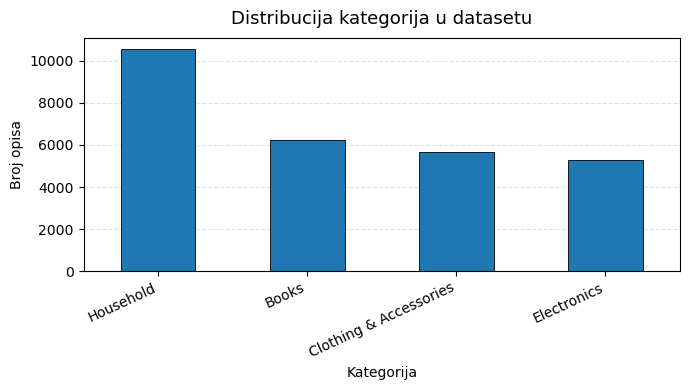

Broj opisa po kategoriji:
  Household                  10564  (38.0%)
  Books                       6256  (22.5%)
  Clothing & Accessories      5674  (20.4%)
  Electronics                 5308  (19.1%)


In [73]:
fig, ax = plt.subplots(figsize=(7, 4))
modeling_df["category"].value_counts().plot(
    kind="bar", ax=ax, edgecolor="black", linewidth=0.6
)
ax.set_title("Distribucija kategorija u datasetu", fontsize=13, pad=10)
ax.set_xlabel("Kategorija")
ax.set_ylabel("Broj opisa")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

category_counts = modeling_df["category"].value_counts()
print("Broj opisa po kategoriji:")
for cat, count in category_counts.items():
    print(f"  {cat:<25} {count:>6}  ({count/len(modeling_df)*100:.1f}%)")

Kao što je prikazano i u osnovnoj analizi skupa podataka nakon uklanjanja duplikata, kategorija `Household` ima najviše primera, dok su kategorije `Books`, `Clothing & Accessories` i `Electronics` manje zastupljene. Ova neravnoteža može uticati na modele, jer model može biti pristrasan prema dominantnoj kategoriji.

Zbog toga se augmentacija ne primenjuje nad celim skupom podataka, već se kasnije može primeniti ciljano nad manjinskim kategorijama u trening skupu. Na taj način se smanjuje razlika u zastupljenosti klasa, bez curenja podataka u test skup.

In [74]:
import nltk
import random
from nltk.corpus import wordnet as wn

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

domain_tokens_to_keep = {
    "cm", "mm", "inch", "inches", "kg", "g", "mg", "ml", "l",
    "gb", "mb", "mah", "hz", "khz", "mhz", "ghz", "uv", "hd",
    "xl", "xxl"
}

def spacy_pos_to_wordnet_pos(pos):
    if pos == "NOUN":
        return wn.NOUN
    if pos == "VERB":
        return wn.VERB
    if pos == "ADJ":
        return wn.ADJ
    if pos == "ADV":
        return wn.ADV
    return None


@lru_cache(maxsize=None)
def get_wordnet_synonyms_pos(word, wn_pos):
    synonyms = set()
    
    if wn_pos is None:
        return []
    
    for synset in wn.synsets(word, pos=wn_pos):
        for lemma in synset.lemmas():
            synonym = lemma.name().lower()
            
            if (
                synonym != word
                and synonym.isalpha()
                and "_" not in synonym
                and synonym not in custom_stopwords
                and len(synonym) > 2
            ):
                synonyms.add(synonym)
    
    return sorted(synonyms)


def synonym_replacement(text, replacement_rate=0.10, max_replacements=5,
                        random_state=RANDOM_STATE):
    
    rng = random.Random(random_state)
    doc = nlp(str(text))
    
    tokens = [token.text.lower() for token in doc if not token.is_space]
    candidates = []
    
    for i, token in enumerate(doc):
        word = token.text.lower()
        wn_pos = spacy_pos_to_wordnet_pos(token.pos_)
        
        if (
            word.isalpha()
            and len(word) > 4
            and word not in custom_stopwords
            and word not in domain_tokens_to_keep
            and len(get_wordnet_synonyms_pos(word, wn_pos)) > 0
        ):
            candidates.append((i, word, wn_pos))
    
    if len(candidates) == 0:
        return text
    
    n_replacements = max(1, int(len(tokens) * replacement_rate))
    n_replacements = min(n_replacements, max_replacements, len(candidates))
    
    selected_candidates = rng.sample(candidates, n_replacements)
    
    for idx, word, wn_pos in selected_candidates:
        synonyms = get_wordnet_synonyms_pos(word, wn_pos)
        if synonyms:
            tokens[idx] = rng.choice(synonyms)
    
    return " ".join(tokens)

In [75]:
sample_idx = 0
original_text = modeling_df.loc[sample_idx, "text_no_stop"]
augmented_text = synonym_replacement(
    original_text,
    replacement_rate=0.10,
    max_replacements=5,
    random_state=RANDOM_STATE
)
print("Kategorija:", modeling_df.loc[sample_idx, "category"])
print("=" * 120)
print("\nOriginalni tekst:")
print(original_text[:1000])
print("\nAugmentovani tekst:")
print(augmented_text[:1000])

Kategorija: Household

Originalni tekst:
paper plane design framed wall hanging motivational office decor art prints inch set painting synthetic frame uv textured print gives multi effects attracts special series paintings makes wall beautiful gives royal touch painting ready hang proud possess unique painting niche apart use modern efficient printing technology prints inks precision epson roland hp printers innovative hd printing technique results durable spectacular looking prints highest lifetime print solely notch inks achieve brilliant true colours high level uv resistance prints retain beautiful colours years add colour style living space digitally printed painting pleasure eternal bliss bring home elegant print lushed rich colors makes sheer elegance friends family treasured forever lucky recipient liven place intriguing paintings high definition hd graphic digital prints home office room

Augmentovani tekst:
paper plane design cast wall hanging motivational office decor art pri

In [76]:
augmentation_examples = (
    modeling_df
    .groupby("category", group_keys=False)
    .sample(n=1, random_state=RANDOM_STATE)
    [["category", "text_no_stop"]]
    .copy()
)
augmentation_examples["augmented_text"] = augmentation_examples["text_no_stop"].apply(
    lambda text: synonym_replacement(
        text,
        replacement_rate=0.10,
        max_replacements=5,
        random_state=RANDOM_STATE
    )
)
display(augmentation_examples)

,category,text_no_stop,augmented_text
12848,Books,man search meaning classic tribute hope holocaust new material review enduring work survival literature new york times read book year dr frankl book los angeles times works essential reading seek ...,man search think classic tribute hope holocaust new material review enduring work endurance literature new york times read book year dr frankl book los angeles times works essential reading seek u...
19060,Clothing & Accessories,uri mackenzie men dupion silk navy blue kurta golden chudidar pyjama jacket ethnic waistcoat uri mackenzie men exquisite charming kurta pyjama piece uri mackenzie crafted fine dupion silk fabric p...,uri mackenzie men dupion silk navy blue kurta golden chudidar pyjama cap ethnic waistcoat uri mackenzie men exquisite magical kurta pyjama piece uri mackenzie crafted fine dupion silk fabric perfe...
25916,Electronics,shopee branded photography backdrop stand kit background support kit portable foldable bag shopee branded photography backdrop stand kit background support kit portable foldable bag,shopee branded photography background stand kit background support kit portable foldable bag shopee branded photography backdrop stand kit background accompaniment kit portable foldable bag
2169,Household,hosley apple cinnamon highly fragranced oz wax jar candle pack scented tealights flavor apple cinnamon experience cozy comfort soothing ambience glowing fireplace home hosley oz apple cinnamon sma...,hosley apple cinnamon extremely fragranced oz wax jar candle pack scented tealights flavour apple cinnamon experience cozy comfort soothing ambience shine hearth home hosley oz apple cinnamon smal...


Primeri pokazuju da `synonym replacement` može da napravi blage varijacije postojećih opisa, ali metoda nije semantički savršena. Pošto se sinonimi dobijaju iz opšteg leksičkog resursa, neke zamene mogu zvučati manje prirodno u e-commerce kontekstu, na primer `jacket → cap` ili `support → accompaniment`. `spaCy POS` tagovi su dodati kako bi doprineli da synonym replacement bude manje nasumičan i metodološki ozbiljniji.

Zbog toga je augmentacija ograničena na mali broj izmena po opisu, uz maksimalno 5 zamena i stopu od 10%. Takođe se ne menjaju domenski tokeni kao što su merne jedinice i tehničke oznake. Ovakav pristup je konzervativniji od agresivnih metoda augmentacije i pogodniji je za ovaj skup podataka.

In [77]:
def augment_training_data(X_train, y_train, target_count=None,
                          replacement_rate=0.10, max_replacements=5,
                          random_state=RANDOM_STATE):
    
    rng = random.Random(random_state)

    augmented_texts = list(X_train)
    augmented_labels = list(y_train)

    if target_count is None:
        target_count = y_train.value_counts().max()

    for category in y_train.unique():
        category_texts = X_train[y_train == category].tolist()
        current_count = len(category_texts)
        needed = target_count - current_count

        if needed <= 0:
            continue

        for _ in range(needed):
            base_text = rng.choice(category_texts)
            seed = rng.randint(0, 10**6)
            aug_text = synonym_replacement(
                base_text,
                replacement_rate=replacement_rate,
                max_replacements=max_replacements,
                random_state=seed
            )
            augmented_texts.append(aug_text)
            augmented_labels.append(category)

    return pd.Series(augmented_texts), pd.Series(augmented_labels)

Funkcija `augment_training_data` dopunjuje manjinske klase do broja primera najveće klase u trening skupu. Na taj način se augmentacija koristi samo za balansiranje trening podataka, dok test skup ostaje neizmenjen i realan za evaluaciju.

Pored zamene sinonimima, u literaturi se često koriste i random deletion i random swap. Međutim, za e-commerce opise proizvoda ove tehnike su manje pogodne. Random deletion može ukloniti ključne informacije kao što su dimenzije, materijal ili naziv modela, dok random swap može narušiti prirodan redosled strukturiranih opisa. Zbog toga se u ovom praktičnom delu koristi synonym replacement kao konzervativnija metoda augmentacije.

## 4. Reprezentacija teksta i priprema za modelovanje

Nakon analize kvaliteta teksta i definisanja različitih varijanti predobrade, sledeći korak je pretvaranje tekstualnih podataka u numeričke reprezentacije koje modeli mašinskog učenja mogu da koriste.

U ovom delu rada prvo se vrši podela podataka na trening i test skup, a zatim će se analizirati klasične reprezentacije teksta kao što su Bag-of-Words i TF-IDF.

### 4.1 Podela podataka na trening i test skup

Pre formiranja BoW i TF-IDF reprezentacija potrebno je podeliti podatke na trening i test skup. Podela se radi samo jednom i koristi se za sve tekstualne varijante, kako bi rezultati kasnijih modela bili međusobno uporedivi.

Koristi se stratifikovana podela, što znači da se približno čuva ista raspodela kategorija u trening i test skupu. Ovo je važno jer skup podataka ima umerenu neravnotežu klasa.

In [78]:
from sklearn.model_selection import train_test_split

text_variants = [
    "text_raw",
    "text_normalized",
    "text_alpha",
    "text_no_stop",
    "text_stemmed",
    "text_lemmatized"
]

target_column = "category"

required_columns = [target_column] + text_variants
missing_columns = [col for col in required_columns if col not in modeling_df.columns]

if missing_columns:
    raise ValueError(f"Nedostaju kolone u modeling_df: {missing_columns}")

print("Broj primera u finalnom skupu:", len(modeling_df))
print("Tekstualne varijante za poređenje:")
for variant in text_variants:
    print("-", variant)

Broj primera u finalnom skupu: 27802
Tekstualne varijante za poređenje:
- text_raw
- text_normalized
- text_alpha
- text_no_stop
- text_stemmed
- text_lemmatized


In [79]:
train_df, test_df = train_test_split(
    modeling_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=modeling_df[target_column]
)

print("Dimenzije trening skupa:", train_df.shape)
print("Dimenzije test skupa:", test_df.shape)

print("\nUdeo trening skupa: {:.1f}%".format(len(train_df) / len(modeling_df) * 100))
print("Udeo test skupa: {:.1f}%".format(len(test_df) / len(modeling_df) * 100))

Dimenzije trening skupa: (22241, 7)
Dimenzije test skupa: (5561, 7)

Udeo trening skupa: 80.0%
Udeo test skupa: 20.0%


In [80]:
def class_distribution(series):
    counts = series.value_counts()
    percentages = series.value_counts(normalize=True) * 100
    
    return pd.DataFrame({
        "count": counts,
        "percentage_%": percentages
    })

overall_distribution = class_distribution(modeling_df[target_column])
train_distribution = class_distribution(train_df[target_column])
test_distribution = class_distribution(test_df[target_column])

split_distribution = pd.concat(
    {
        "overall": overall_distribution,
        "train": train_distribution,
        "test": test_distribution
    },
    axis=1
)

display(split_distribution.round(2))

overall              train               test  \
                         count percentage_% count percentage_% count   
category                                                               
Household                10564        38.00  8451        38.00  2113   
Books                     6256        22.50  5005        22.50  1251   
Clothing & Accessories    5674        20.41  4539        20.41  1135   
Electronics               5308        19.09  4246        19.09  1062   

                                     
                       percentage_%  
category                             
Household                     38.00  
Books                         22.50  
Clothing & Accessories        20.41  
Electronics                   19.10

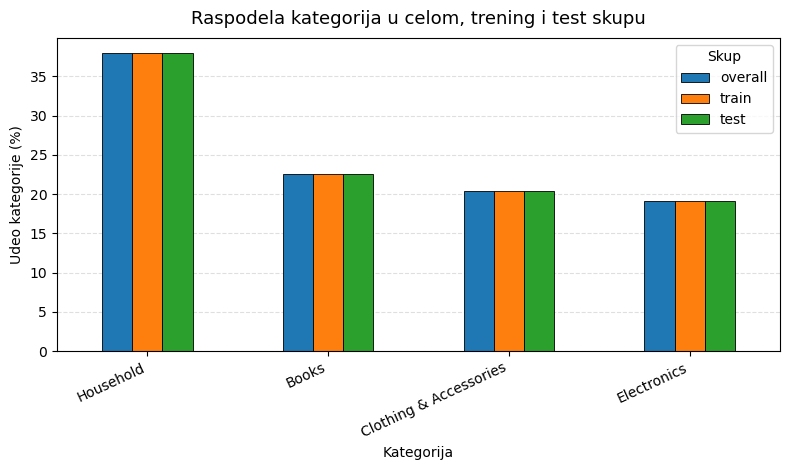

In [81]:
distribution_plot_df = pd.DataFrame({
    "overall": modeling_df[target_column].value_counts(normalize=True) * 100,
    "train": train_df[target_column].value_counts(normalize=True) * 100,
    "test": test_df[target_column].value_counts(normalize=True) * 100
})

distribution_plot_df = distribution_plot_df.loc[overall_distribution.index]

fig, ax = plt.subplots(figsize=(8, 4.8))

distribution_plot_df.plot(
    kind="bar",
    ax=ax,
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Raspodela kategorija u celom, trening i test skupu", fontsize=13, pad=10)
ax.set_xlabel("Kategorija")
ax.set_ylabel("Udeo kategorije (%)")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Skup")
plt.tight_layout()
plt.show()

Stratifikovana podela je očuvala raspodelu kategorija u trening i test skupu. Kategorija `Household` čini 38.00% primera u celom skupu, trening skupu i test skupu. Slično važi i za ostale kategorije: `Books` ima 22.50%, `Clothing & Accessories` 20.41%, dok `Electronics` ima približno 19.1% primera.

Ovo potvrđuje da test skup ima reprezentativnu strukturu i da nijedna kategorija nije nesrazmerno zastupljena ili zapostavljena nakon podele.

In [82]:
y_train = train_df[target_column]
y_test = test_df[target_column]

X_train_variants = {
    variant: train_df[variant]
    for variant in text_variants
}

X_test_variants = {
    variant: test_df[variant]
    for variant in text_variants
}

print("Primer dostupnih tekstualnih varijanti za modelovanje:")
for variant in text_variants:
    print(f"{variant:<18} train: {X_train_variants[variant].shape[0]} | test: {X_test_variants[variant].shape[0]}")

Primer dostupnih tekstualnih varijanti za modelovanje:
text_raw           train: 22241 | test: 5561
text_normalized    train: 22241 | test: 5561
text_alpha         train: 22241 | test: 5561
text_no_stop       train: 22241 | test: 5561
text_stemmed       train: 22241 | test: 5561
text_lemmatized    train: 22241 | test: 5561


In [83]:
train_indices = set(train_df.index)
test_indices = set(test_df.index)

overlap_indices = train_indices.intersection(test_indices)

print("Broj istih indeksa u trening i test skupu:", len(overlap_indices))

Broj istih indeksa u trening i test skupu: 0


Nakon podele, svi naredni eksperimenti koriste iste trening i test primere za svaku tekstualnu varijantu. Time se obezbeđuje fer poređenje između različitih nivoa predobrade i različitih reprezentacija teksta.

Dodatna provera pokazuje da nema preklapanja indeksa između trening i test skupa, što potvrđuje da su skupovi razdvojeni. 

### 4.2 Bag-of-Words reprezentacija

Bag-of-Words predstavlja tekst kao skup tokena, pri čemu se za svaki dokument broji koliko puta se određeni token pojavljuje. Redovi matrice odgovaraju opisima proizvoda, dok kolone odgovaraju tokenima iz vokabulara.

U ovoj sekciji se Bag-of-Words reprezentacija demonstrira nad varijantom `text_no_stop`. Ova varijanta je izabrana jer su iz teksta uklonjene stop-reči, ali nisu primenjene morfološke transformacije kao što su stemming ili lematizacija. Time se zadržavaju originalniji oblici reči, što je korisno kod e-commerce opisa proizvoda, gde oblici reči, nazivi i domenski izrazi mogu imati značaj za klasifikaciju.

In [84]:
from sklearn.feature_extraction.text import CountVectorizer

bow_text_variant = "text_no_stop"

X_train_text = X_train_variants[bow_text_variant]
X_test_text = X_test_variants[bow_text_variant]

print("Izabrana tekstualna varijanta za BoW:", bow_text_variant)
print("Broj trening primera:", X_train_text.shape[0])
print("Broj test primera:", X_test_text.shape[0])

Izabrana tekstualna varijanta za BoW: text_no_stop
Broj trening primera: 22241
Broj test primera: 5561


Za Bag-of-Words reprezentaciju koristi se `CountVectorizer`. Vektorizer se fituje samo nad trening skupom, dok se test skup samo transformiše pomoću već naučenog vokabulara. Na taj način se sprečava da informacije iz test skupa utiču na formiranje reprezentacije.

Parametar `max_features=20000` ograničava vokabular na najviše 20.000 tokena, dok `min_df=2` uklanja tokene koji se pojavljuju samo u jednom dokumentu. Ovo smanjuje dimenzionalnost i uklanja deo ekstremno retkih tokena.

In [85]:
bow_vectorizer = CountVectorizer(
    max_features=20000,
    min_df=2,
    ngram_range=(1, 1)
)

X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)

print("Dimenzije BoW trening matrice:", X_train_bow.shape)
print("Dimenzije BoW test matrice:", X_test_bow.shape)
print("Veličina BoW vokabulara:", len(bow_vectorizer.vocabulary_))

Dimenzije BoW trening matrice: (22241, 20000)
Dimenzije BoW test matrice: (5561, 20000)
Veličina BoW vokabulara: 20000


In [86]:
bow_nonzero_train = X_train_bow.nnz
bow_total_elements_train = X_train_bow.shape[0] * X_train_bow.shape[1]
bow_density_train = bow_nonzero_train / bow_total_elements_train * 100

bow_nonzero_test = X_test_bow.nnz
bow_total_elements_test = X_test_bow.shape[0] * X_test_bow.shape[1]
bow_density_test = bow_nonzero_test / bow_total_elements_test * 100

print("BoW trening matrica")
print("Broj nenultih elemenata:", bow_nonzero_train)
print(f"Gustina matrice: {bow_density_train:.4f}%")

print("\nBoW test matrica")
print("Broj nenultih elemenata:", bow_nonzero_test)
print(f"Gustina matrice: {bow_density_test:.4f}%")

BoW trening matrica
Broj nenultih elemenata: 1048053
Gustina matrice: 0.2356%

BoW test matrica
Broj nenultih elemenata: 257701
Gustina matrice: 0.2317%


Dobijena BoW matrica za trening skup ima dimenzije `22241 × 20000`, dok test matrica ima dimenzije `5561 × 20000`. Broj kolona odgovara ograničenom vokabularu od 20.000 tokena.
BoW matrica je izrazito retka. U trening matrici samo 0.2356% elemenata ima nenultu vrednost, dok je gustina test matrice 0.2317%. To znači da se u jednom opisu proizvoda pojavljuje veoma mali deo ukupnog vokabulara.
Zbog ovako male gustine BoW reprezentacije se čuvaju kao sparse matrice, što omogućava efikasnije čuvanje i obradu podataka.

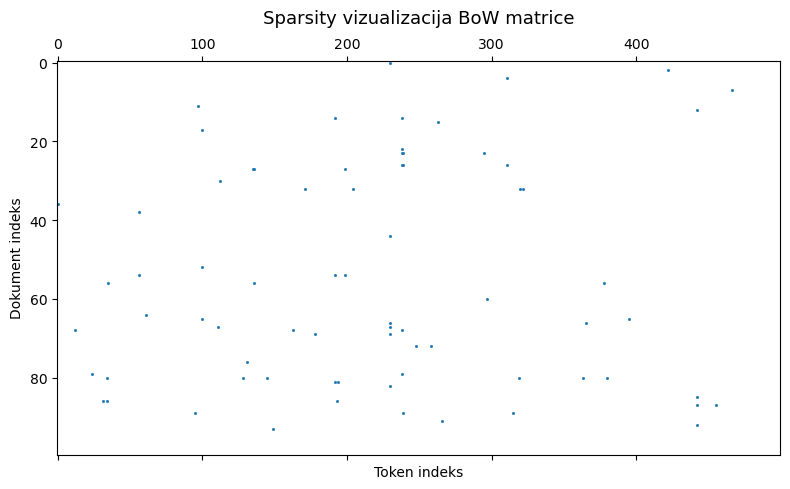

In [87]:
# prikazuje se prvih 100 dokumenata i prvih 500 tokena
bow_sample_matrix = X_train_bow[:100, :500]

fig, ax = plt.subplots(figsize=(8, 5))
ax.spy(bow_sample_matrix, markersize=1)
ax.set_aspect("auto")

ax.set_title("Sparsity vizualizacija BoW matrice", fontsize=13, pad=10)
ax.set_xlabel("Token indeks")
ax.set_ylabel("Dokument indeks")

plt.tight_layout()
plt.show()

Sparsity prikaz potvrđuje da je većina elemenata u BoW matrici jednaka nuli. Svaka tačka predstavlja pojavljivanje određenog tokena u određenom dokumentu. Pošto jedan opis proizvoda koristi samo mali broj tokena iz ukupnog vokabulara, nenulti elementi su retko raspoređeni kroz matricu.

In [88]:
bow_feature_names = np.array(bow_vectorizer.get_feature_names_out())

bow_token_counts = np.asarray(X_train_bow.sum(axis=0)).ravel()

bow_top_tokens = pd.DataFrame({
    "token": bow_feature_names,
    "frequency": bow_token_counts
}).sort_values("frequency", ascending=False).head(20)

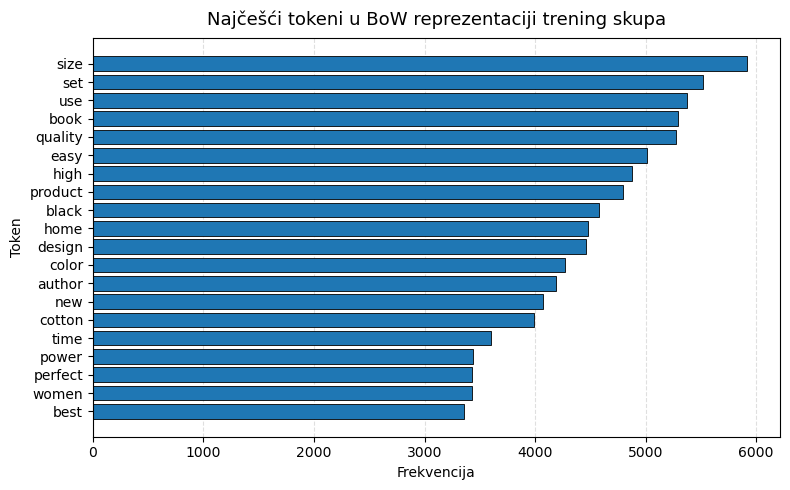

In [89]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    bow_top_tokens["token"][::-1],
    bow_top_tokens["frequency"][::-1],
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Najčešći tokeni u BoW reprezentaciji trening skupa", fontsize=13, pad=10)
ax.set_xlabel("Frekvencija")
ax.set_ylabel("Token")
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Najčešći tokeni u BoW reprezentaciji trening skupa su opšti e-commerce termini kao što su `size`, `set`, `use`, `quality`, `product`, `design`, `color` i `home`. Pojavljuju se i tokeni koji su karakterističniji za pojedine kategorije, na primer `book` i `author` za knjige, `cotton` i `women` za odeću, kao i `power` za elektronske proizvode.

Ovi tokeni su česti, ali nisu nužno i najdiskriminativniji za klasifikaciju. Bag-of-Words meri učestalost pojavljivanja tokena, ali ne uzima direktno u obzir da li je token specifičan za jednu kategoriju ili se pojavljuje u više kategorija.

In [90]:
sample_position = 0

sample_vector = X_train_bow[sample_position]
sample_nonzero_indices = sample_vector.nonzero()[1]
sample_counts = sample_vector.data

sample_bow_df = pd.DataFrame({
    "token": bow_feature_names[sample_nonzero_indices],
    "count": sample_counts
}).sort_values("count", ascending=False)

print("Kategorija primera:", y_train.iloc[sample_position])
print("Broj različitih BoW tokena u primeru:", sample_bow_df.shape[0])

display(sample_bow_df.head(20))

Kategorija primera: Electronics
Broj različitih BoW tokena u primeru: 114


,token,count
2,player,10
57,play,5
7,video,5
8,music,4
35,function,4
23,support,3
4,recorder,3
6,radio,3
31,built,3
28,color,2


Na primeru iz kategorije `Electronics`, jedan opis proizvoda sadrži 114 različitih BoW tokena. Najčešći tokeni u tom opisu su `player`, `play`, `video`, `music`, `function`, `support`, `recorder` i `radio`, što odgovara sadržaju opisa elektronskog uređaja.

Ovaj primer pokazuje da je BoW reprezentacija interpretabilna tj. lako se vidi koji tokeni najviše doprinose pojedinačnom dokumentu. Njeno ograničenje je to što se redosled reči gubi, pa reprezentacija ne čuva strukturu rečenice, već samo prisustvo i učestalost tokena.

### 4.3 TF-IDF reprezentacija

TF-IDF predstavlja nadogradnju Bag-of-Words pristupa. Umesto da se posmatra samo koliko se često token pojavljuje u dokumentu, TF-IDF uzima u obzir i koliko je token čest u celom korpusu.

Tokeni koji se često pojavljuju u jednom dokumentu, ali nisu jednako česti u svim dokumentima, dobijaju veći značaj. Sa druge strane, tokeni koji se pojavljuju u velikom broju dokumenata dobijaju manju težinu. Zbog toga TF-IDF može biti korisniji od običnog brojanja tokena, posebno kod tekstualne klasifikacije.

Kao i kod Bag-of-Words reprezentacije, koristi se tekstualna varijanta `text_no_stop`.

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_text_variant = "text_no_stop"

X_train_text = X_train_variants[tfidf_text_variant]
X_test_text = X_test_variants[tfidf_text_variant]

print("Izabrana tekstualna varijanta za TF-IDF:", tfidf_text_variant)
print("Broj trening primera:", X_train_text.shape[0])
print("Broj test primera:", X_test_text.shape[0])

Izabrana tekstualna varijanta za TF-IDF: text_no_stop
Broj trening primera: 22241
Broj test primera: 5561


`TfidfVectorizer` se, kao i `CountVectorizer`, fituje samo nad trening skupom. Time se vokabular i IDF težine računaju isključivo iz trening podataka, dok se test skup samo transformiše pomoću naučene reprezentacije.

Da bi poređenje sa BoW reprezentacijom bilo fer, koriste se isti osnovni parametri: `max_features=20000`, `min_df=2` i unigrami.

In [92]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    min_df=2,
    ngram_range=(1, 1)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("Dimenzije TF-IDF trening matrice:", X_train_tfidf.shape)
print("Dimenzije TF-IDF test matrice:", X_test_tfidf.shape)
print("Veličina TF-IDF vokabulara:", len(tfidf_vectorizer.vocabulary_))

Dimenzije TF-IDF trening matrice: (22241, 20000)
Dimenzije TF-IDF test matrice: (5561, 20000)
Veličina TF-IDF vokabulara: 20000


In [93]:
tfidf_nonzero_train = X_train_tfidf.nnz
tfidf_total_elements_train = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
tfidf_density_train = tfidf_nonzero_train / tfidf_total_elements_train * 100

tfidf_nonzero_test = X_test_tfidf.nnz
tfidf_total_elements_test = X_test_tfidf.shape[0] * X_test_tfidf.shape[1]
tfidf_density_test = tfidf_nonzero_test / tfidf_total_elements_test * 100

print("TF-IDF trening matrica")
print("Broj nenultih elemenata:", tfidf_nonzero_train)
print(f"Gustina matrice: {tfidf_density_train:.4f}%")

print("\nTF-IDF test matrica")
print("Broj nenultih elemenata:", tfidf_nonzero_test)
print(f"Gustina matrice: {tfidf_density_test:.4f}%")

TF-IDF trening matrica
Broj nenultih elemenata: 1048053
Gustina matrice: 0.2356%

TF-IDF test matrica
Broj nenultih elemenata: 257701
Gustina matrice: 0.2317%


TF-IDF trening matrica ima iste dimenzije kao BoW matrica: `22241 × 20000`, dok test matrica ima dimenzije `5561 × 20000`. Vokabular je ograničen na 20.000 tokena, što omogućava direktno poređenje sa BoW reprezentacijom.

Broj nenultih elemenata i gustina matrice isti su kao kod BoW reprezentacije: gustina trening matrice iznosi 0.2356%, a test matrice 0.2317%. To je očekivano, jer BoW i TF-IDF koriste isti vokabular i iste dokumente. Razlika je u vrednostima: BoW čuva broj pojavljivanja tokena, dok TF-IDF čuva ponderisani značaj tokena.

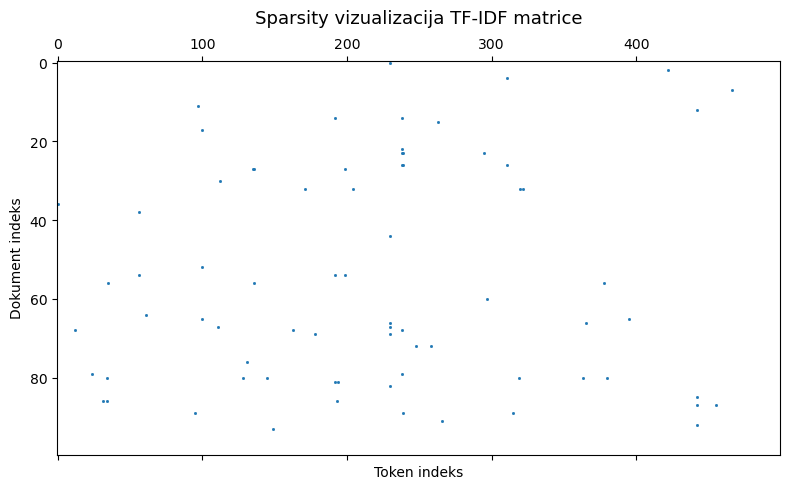

In [94]:
tfidf_sample_matrix = X_train_tfidf[:100, :500]

fig, ax = plt.subplots(figsize=(8, 5))
ax.spy(tfidf_sample_matrix, markersize=1)
ax.set_aspect("auto")

ax.set_title("Sparsity vizualizacija TF-IDF matrice", fontsize=13, pad=10)
ax.set_xlabel("Token indeks")
ax.set_ylabel("Dokument indeks")

plt.tight_layout()
plt.show()

Sparsity prikaz potvrđuje da je i TF-IDF matrica izrazito retka. Položaj nenultih elemenata sličan je kao kod BoW reprezentacije, jer isti tokeni postoje u istim dokumentima. Međutim, vrednosti tih elemenata nisu frekvencije, već TF-IDF težine koje zavise od učestalosti tokena u dokumentu i njegove rasprostranjenosti kroz korpus.

In [95]:
tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# Prosečan TF-IDF značaj tokena kroz trening skup
mean_tfidf_scores = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

tfidf_top_tokens = pd.DataFrame({
    "token": tfidf_feature_names,
    "mean_tfidf": mean_tfidf_scores
}).sort_values("mean_tfidf", ascending=False).head(20)

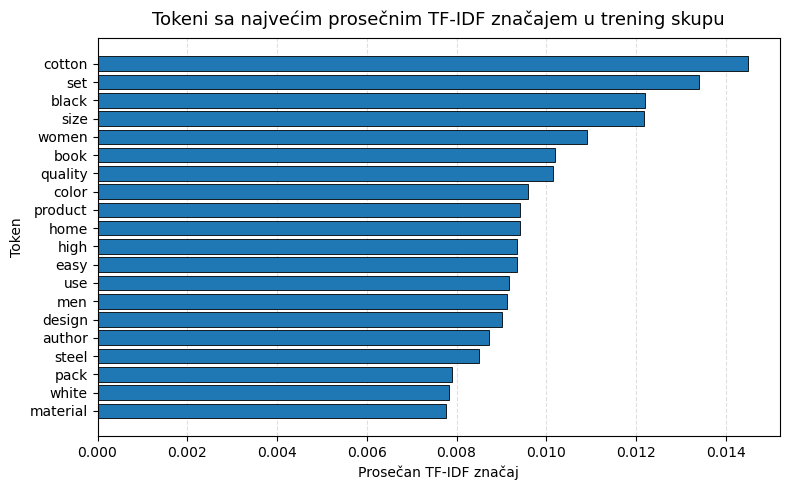

In [96]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    tfidf_top_tokens["token"][::-1],
    tfidf_top_tokens["mean_tfidf"][::-1],
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Tokeni sa najvećim prosečnim TF-IDF značajem u trening skupu", fontsize=13, pad=10)
ax.set_xlabel("Prosečan TF-IDF značaj")
ax.set_ylabel("Token")
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Globalno najviši prosečan TF-IDF značaj imaju tokeni kao što su `cotton`, `set`, `black`, `size`, `women`, `book`, `quality`, `color` i `product`. U odnosu na BoW prikaz, redosled tokena se menja jer TF-IDF ne nagrađuje samo sirovu učestalost, već i relativni značaj tokena u dokumentima.

Na primer, `cotton` i `women` dobijaju visok značaj jer su snažno povezani sa opisima odeće, dok `book` ima jasan značaj za kategoriju knjiga. Ipak, neki opšti e-commerce tokeni kao što su `set`, `size`, `quality` i `product` i dalje ostaju visoko rangirani jer se često pojavljuju u opisima proizvoda.

In [97]:
y_train_reset = y_train.reset_index(drop=True)

def get_top_tfidf_terms_for_category(category, top_n=30):
    category_mask = (y_train_reset == category).values
    category_matrix = X_train_tfidf[category_mask]
    
    mean_scores = np.asarray(category_matrix.mean(axis=0)).ravel()
    top_indices = mean_scores.argsort()[::-1][:top_n]
    
    return pd.DataFrame({
        "category": category,
        "token": tfidf_feature_names[top_indices],
        "mean_tfidf": mean_scores[top_indices]
    })

category_tfidf_terms = pd.concat(
    [
        get_top_tfidf_terms_for_category(category, top_n=30)
        for category in y_train_reset.value_counts().index
    ],
    ignore_index=True
)

display(category_tfidf_terms.groupby("category").head(10))

,category,token,mean_tfidf
0,Household,set,0.022064
1,Household,steel,0.021318
2,Household,home,0.019678
3,Household,stainless,0.017646
4,Household,table,0.016551
5,Household,color,0.015296
6,Household,easy,0.015287
7,Household,use,0.015271
8,Household,kitchen,0.014860
9,Household,size,0.014289


Tabela pokazuje da TF-IDF uspešno izdvaja tokene koji su karakteristični za pojedine kategorije. Kod kategorije `Books` najznačajniji tokeni su `book`, `author`, `books`, `students`, `review` i `university`, što odgovara opisima knjiga i obrazovnog sadržaja.
Kod kategorije `Clothing & Accessories` dominiraju tokeni kao što su `cotton`, `women`, `men`, `wear`, `fit`, `shirt` i `fabric`. Za kategoriju `Electronics` izdvajaju se `usb`, `camera`, `cable`, `bluetooth`, `audio`, `wireless`, `power`, `laptop` i `phone`. Kategorija `Household` sadrži tokene kao što su `steel`, `home`, `stainless`, `table`, `kitchen`, `size` i `use`.

In [98]:
#!pip install wordcloud
from wordcloud import WordCloud

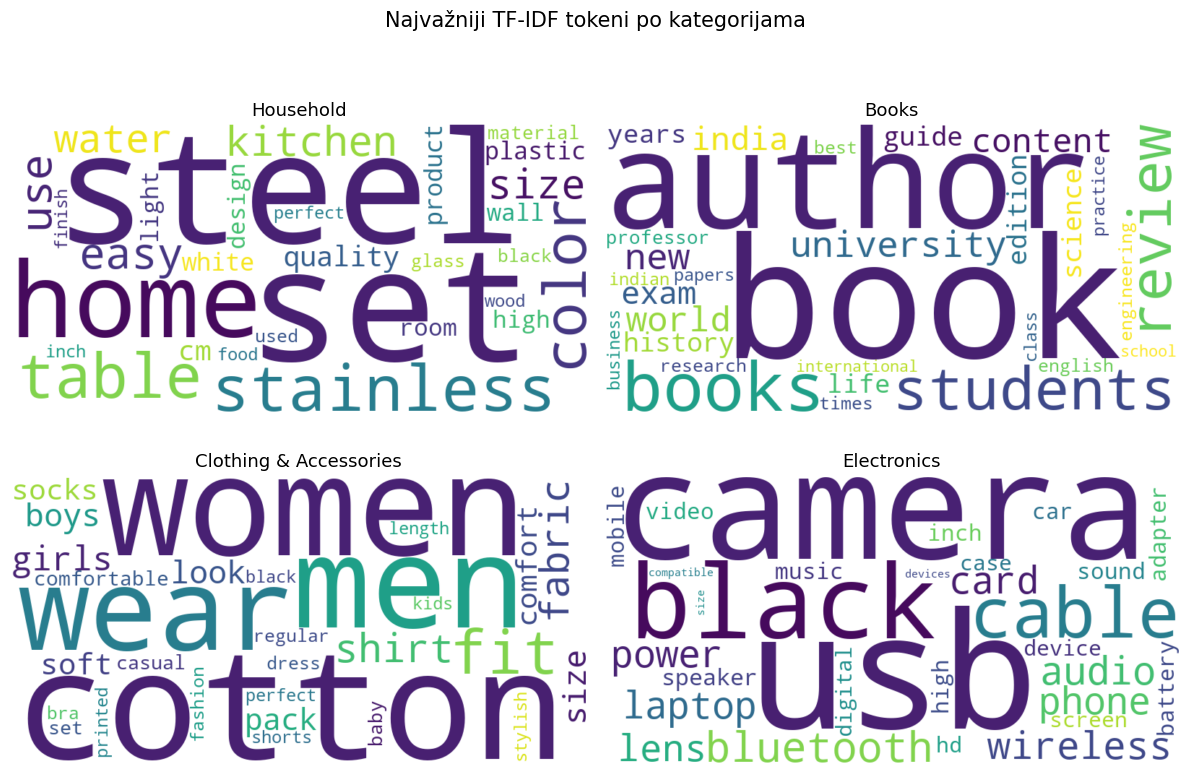

In [99]:
categories = y_train_reset.value_counts().index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, category in zip(axes, categories):
    category_terms = category_tfidf_terms[
        category_tfidf_terms["category"] == category
    ]
    
    frequencies = dict(
        zip(category_terms["token"], category_terms["mean_tfidf"])
    )
    
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        random_state=RANDOM_STATE
    ).generate_from_frequencies(frequencies)
    
    ax.imshow(wordcloud, interpolation="bilinear")
    ax.set_title(category, fontsize=13)
    ax.axis("off")

plt.suptitle("Najvažniji TF-IDF tokeni po kategorijama", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Wordcloud prikaz vizuelno potvrđuje razlike između kategorija. Kod `Books` se najviše ističu `book` i `author`, kod `Clothing & Accessories` tokeni `cotton`, `women`, `men` i `wear`, dok se kod `Electronics` jasno izdvajaju `camera`, `usb`, `cable`, `bluetooth`, `audio` i `wireless`.

Kod `Household` su dominantni tokeni `steel`, `home`, `set`, `table`, `stainless` i `kitchen`. Ovaj prikaz je koristan jer brzo pokazuje koje reči su najkarakterističnije za svaku kategoriju, ali se za preciznije poređenje koriste i numeričke TF-IDF vrednosti iz prethodne tabele.

In [100]:
sample_position = 0

sample_vector = X_train_tfidf[sample_position]
sample_nonzero_indices = sample_vector.nonzero()[1]
sample_tfidf_scores = sample_vector.data

sample_tfidf_df = pd.DataFrame({
    "token": tfidf_feature_names[sample_nonzero_indices],
    "tfidf_score": sample_tfidf_scores
}).sort_values("tfidf_score", ascending=False)

print("Kategorija primera:", y_train.iloc[sample_position])
print("Broj različitih TF-IDF tokena u primeru:", sample_tfidf_df.shape[0])

display(sample_tfidf_df.head(20))

Kategorija primera: Electronics
Broj različitih TF-IDF tokena u primeru: 114


,token,tfidf_score
2,player,0.530569
7,video,0.227693
57,play,0.225218
4,recorder,0.204997
8,music,0.185116
35,function,0.178868
6,radio,0.166590
103,formats,0.134877
65,songs,0.134315
31,built,0.126398


Na primeru iz kategorije `Electronics`, TF-IDF reprezentacija izdvaja tokene kao što su `player`, `video`, `play`, `recorder`, `music`, `function`, `radio`, `formats`, `songs` i `lcd`. To odgovara opisu elektronskog uređaja za reprodukciju audio i video sadržaja. U poređenju sa BoW prikazom istog primera, TF-IDF ne prikazuje samo koliko se token pojavljuje, već mu dodeljuje težinu prema njegovom značaju u dokumentu. Zato token `player` ima najveći TF-IDF skor, dok se specifičniji tokeni kao `fm`, `lcd`, `formats` i `amv` takođe pojavljuju visoko na listi.

### 4.4 Word2Vec reprezentacija

Za razliku od Bag-of-Words i TF-IDF reprezentacija, koje tekst predstavljaju kroz veoma velike i retke matrice, Word2Vec uči guste vektorske reprezentacije reči. Ideja je da reči koje se pojavljuju u sličnim kontekstima imaju slične vektore.

U ovoj sekciji Word2Vec model se trenira nad trening tekstovima iz varijante `text_no_stop`. Model se trenira samo nad trening skupom, kako bi se izbeglo korišćenje informacija iz test podataka. Nakon toga se svaki opis proizvoda predstavlja kao prosečan vektor svih reči koje postoje u Word2Vec vokabularu.

In [101]:
# gensim za instalaciju
#!pip install gensim

from gensim.models import Word2Vec
from sklearn.decomposition import PCA

In [102]:
w2v_text_variant = "text_no_stop"

X_train_w2v_text = X_train_variants[w2v_text_variant]
X_test_w2v_text = X_test_variants[w2v_text_variant]

X_train_tokens_w2v = X_train_w2v_text.apply(word_tokenize_basic).tolist()
X_test_tokens_w2v = X_test_w2v_text.apply(word_tokenize_basic).tolist()

print("Izabrana tekstualna varijanta za Word2Vec:", w2v_text_variant)
print("Broj trening dokumenata:", len(X_train_tokens_w2v))
print("Broj test dokumenata:", len(X_test_tokens_w2v))

Izabrana tekstualna varijanta za Word2Vec: text_no_stop
Broj trening dokumenata: 22241
Broj test dokumenata: 5561


Word2Vec model se trenira nad tokenizovanim opisima proizvoda. Koristi se `vector_size=100`, pa je svaka reč predstavljena vektorom od 100 dimenzija. Parametar `min_count=2` uklanja reči koje se pojavljuju samo jednom u trening skupu.

U ovoj analizi koristi se Skip-gram varijanta modela (`sg=1`), jer je pogodnija za učenje reprezentacija ređih i domenski specifičnih reči, što je važno kod e-commerce opisa proizvoda.

In [103]:
%%capture
w2v_model = Word2Vec(
    sentences=X_train_tokens_w2v,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=RANDOM_STATE
)

In [104]:
print("Veličina Word2Vec vokabulara:", len(w2v_model.wv))
print("Dimenzionalnost vektora reči:", w2v_model.vector_size)

Veličina Word2Vec vokabulara: 34765
Dimenzionalnost vektora reči: 100


In [105]:
example_words = [
    "book", "author", "cotton", "camera",
    "usb", "kitchen", "steel", "women"
]

for word in example_words:
    if word in w2v_model.wv:
        print(f"\nNajbliže reči za '{word}':")
        similar_words = w2v_model.wv.most_similar(word, topn=5)
        for similar_word, score in similar_words:
            print(f"  {similar_word:<15} {score:.3f}")
    else:
        print(f"\nReč '{word}' nije u Word2Vec vokabularu.")


Najbliže reči za 'book':
  written         0.668
  goldmine        0.634
  read            0.628
  compendium      0.624
  peers           0.622

Najbliže reči za 'author':
  bestselling     0.820
  foreword        0.667
  review          0.650
  timothy         0.639
  anthony         0.638

Najbliže reči za 'cotton':
  combed          0.740
  striped         0.718
  polycotton      0.707
  heartin         0.702
  cambric         0.694

Najbliže reči za 'camera':
  dslr            0.778
  camcorder       0.753
  cameras         0.748
  mirrorless      0.744
  actman          0.740

Najbliže reči za 'usb':
  port            0.845
  pendrive        0.795
  sabrent         0.793
  quantumzero     0.792
  bidirectional   0.789

Najbliže reči za 'kitchen':
  zinzer          0.737
  baskety         0.735
  gargson         0.730
  butcher         0.730
  healthsense     0.711

Najbliže reči za 'steel':
  stainless       0.985
  strainers       0.724
  fibrox          0.711
  pakkad         

Najbliže reči pokazuju da je Word2Vec delimično naučio domenske odnose iz e-commerce opisa. Za token `camera` pojavljuju se povezani termini kao što su `camcorder` i `dslr`, dok se za `steel` najviše izdvaja `stainless`. Kod tokena `cotton` pojavljuju se tekstilni termini kao što su `combed`, `striped`, `polycotton`, `heartin` i `cambric`, a za `women` termini `womens`, `ladies`, `girls` i `men`.

Kod nekih reči, na primer `book`, `kitchen` ili `usb`, najbliži tokeni nisu uvek opšti sinonimi, već imena, brendovi ili termini koji se često pojavljuju u sličnim opisima proizvoda. To je očekivano, jer Word2Vec ne uči značenje iz rečnika, već iz konteksta pojavljivanja u konkretnom skupu podataka.

In [106]:
def document_vector_word2vec(tokens, model):
    vectors = [
        model.wv[token]
        for token in tokens
        if token in model.wv
    ]
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)


X_train_w2v = np.vstack([
    document_vector_word2vec(tokens, w2v_model)
    for tokens in X_train_tokens_w2v
])

X_test_w2v = np.vstack([
    document_vector_word2vec(tokens, w2v_model)
    for tokens in X_test_tokens_w2v
])

print("Dimenzije Word2Vec trening reprezentacije:", X_train_w2v.shape)
print("Dimenzije Word2Vec test reprezentacije:", X_test_w2v.shape)

Dimenzije Word2Vec trening reprezentacije: (22241, 100)
Dimenzije Word2Vec test reprezentacije: (5561, 100)


Nakon prosečenja vektora reči, svaki opis proizvoda je predstavljen jednim gustim vektorom od 100 dimenzija. Za razliku od BoW i TF-IDF matrica koje imaju 20.000 kolona i veoma su retke, Word2Vec reprezentacija ima znatno manju dimenzionalnost i nema sparse strukturu.

In [107]:
def word2vec_coverage(tokenized_documents, model):
    total_tokens = 0
    covered_tokens = 0
    documents_without_known_tokens = 0
    
    for tokens in tokenized_documents:
        known_tokens = [token for token in tokens if token in model.wv]
        
        total_tokens += len(tokens)
        covered_tokens += len(known_tokens)
        
        if len(known_tokens) == 0:
            documents_without_known_tokens += 1
    
    return {
        "total_tokens": total_tokens,
        "covered_tokens": covered_tokens,
        "coverage_%": covered_tokens / total_tokens * 100 if total_tokens > 0 else 0,
        "documents_without_known_tokens": documents_without_known_tokens
    }


w2v_coverage_train = word2vec_coverage(X_train_tokens_w2v, w2v_model)
w2v_coverage_test = word2vec_coverage(X_test_tokens_w2v, w2v_model)

w2v_coverage_df = pd.DataFrame({
    "train": w2v_coverage_train,
    "test": w2v_coverage_test
}).T

display(w2v_coverage_df.round(2))

,total_tokens,covered_tokens,coverage_%,documents_without_known_tokens
train,1509365.0,1486484.0,98.48,3.0
test,373463.0,361836.0,96.89,0.0


Coverage analiza pokazuje da Word2Vec vokabular pokriva veliki deo tokena: 98.48% tokena u trening skupu i 96.89% tokena u test skupu. To znači da se većina reči iz dokumenata koristi pri formiranju prosečnih vektora.

U trening skupu postoje samo 3 dokumenta bez poznatih tokena, dok u test skupu nema takvih dokumenata. Ovo potvrđuje da je Word2Vec reprezentacija dovoljno dobro pokrila korišćeni tekstualni korpus, iako su tokeni koji se pojavljuju samo jednom izostavljeni zbog `min_count=2`.

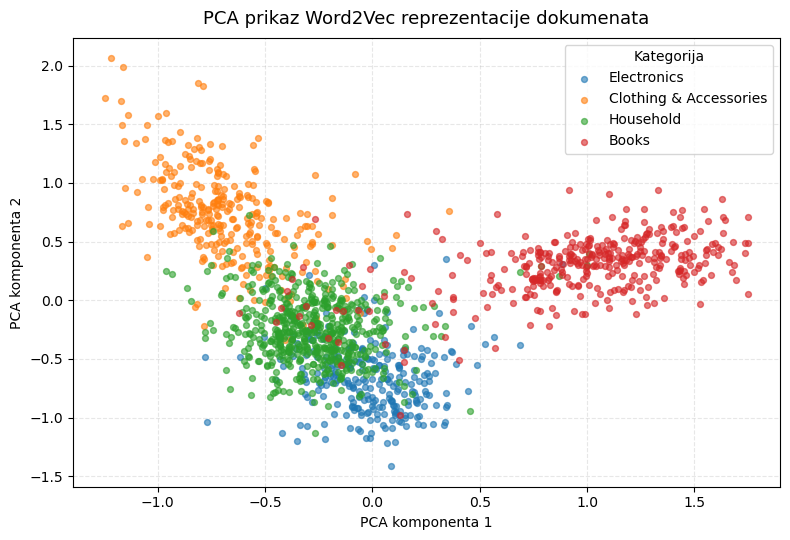

Objašnjena varijansa PCA komponenti:
PC1: 0.1805
PC2: 0.1278
Ukupno: 0.3083


In [108]:
# PCA vizualizacija Word2Vec dokumenata na uzorku trening skupa

sample_size = min(1500, X_train_w2v.shape[0])
sample_indices = np.random.RandomState(RANDOM_STATE).choice(
    X_train_w2v.shape[0],
    size=sample_size,
    replace=False
)

X_w2v_sample = X_train_w2v[sample_indices]
y_w2v_sample = y_train.reset_index(drop=True).iloc[sample_indices]

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_w2v_pca = pca.fit_transform(X_w2v_sample)

fig, ax = plt.subplots(figsize=(8, 5.5))

for category in y_w2v_sample.unique():
    mask = y_w2v_sample == category
    ax.scatter(
        X_w2v_pca[mask, 0],
        X_w2v_pca[mask, 1],
        label=category,
        alpha=0.6,
        s=18
    )

ax.set_title("PCA prikaz Word2Vec reprezentacije dokumenata", fontsize=13, pad=10)
ax.set_xlabel("PCA komponenta 1")
ax.set_ylabel("PCA komponenta 2")
ax.set_axisbelow(True)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(title="Kategorija")

plt.tight_layout()
plt.show()

print("Objašnjena varijansa PCA komponenti:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Ukupno: {pca.explained_variance_ratio_.sum():.4f}")

PCA prikaz svodi 100-dimenzionalne Word2Vec dokument-vektore na dve komponente radi vizuelizacije. Prve dve PCA komponente objašnjavaju ukupno 30.83% varijanse, pa prikaz daje samo delimičan uvid u strukturu embedding prostora.

Na grafikonu se vidi da se kategorija `Books` relativno dobro izdvaja, dok se `Household` i `Electronics` delimično preklapaju. Kategorija `Clothing & Accessories` takođe formira prepoznatljiv skup, ali nije potpuno odvojena od ostalih klasa. Zbog toga se ovaj prikaz koristi samo za okvirnu vizuelnu proveru, dok će se stvarni kvalitet Word2Vec reprezentacije proceniti kroz klasifikacione modele.

### 4.5 FastText reprezentacija

FastText je proširenje Word2Vec pristupa koje, pored celih reči, koristi i karakter n-grame, odnosno manje delove reči. Zbog toga može bolje da obrađuje retke, složene i domenski specifične tokene, što je posebno važno u e-commerce opisima proizvoda.

U e-commerce tekstovima često se pojavljuju nazivi brendova, tehničke oznake, složene reči i reči koje se retko ponavljaju. Za razliku od Word2Vec modela, FastText može da formira reprezentaciju i za reči koje nisu direktno viđene tokom treniranja, koristeći njihove subword delove.

Kao i Word2Vec, FastText se trenira samo nad trening skupom i koristi se tekstualna varijanta `text_no_stop`.

In [109]:
from gensim.models import FastText

In [110]:
ft_text_variant = "text_no_stop"

X_train_ft_text = X_train_variants[ft_text_variant]
X_test_ft_text = X_test_variants[ft_text_variant]

X_train_tokens_ft = X_train_ft_text.apply(word_tokenize_basic).tolist()
X_test_tokens_ft = X_test_ft_text.apply(word_tokenize_basic).tolist()

print("Izabrana tekstualna varijanta za FastText:", ft_text_variant)
print("Broj trening dokumenata:", len(X_train_tokens_ft))
print("Broj test dokumenata:", len(X_test_tokens_ft))

Izabrana tekstualna varijanta za FastText: text_no_stop
Broj trening dokumenata: 22241
Broj test dokumenata: 5561


FastText se trenira sa istom osnovnom dimenzionalnošću kao Word2Vec, odnosno `vector_size=100`, kako bi kasnije poređenje reprezentacija bilo jednostavnije. Koristi se `min_count=2`, pa se ekstremno retki tokeni ne uključuju kao posebne reči u vokabular.

Parametri `min_n=3` i `max_n=6` određuju dužinu karakter n-grama koji se koriste za subword reprezentaciju. Na primer, složeniji token može biti predstavljen pomoću više kraćih delova, što FastText-u omogućava bolju obradu retkih i novih reči.

In [111]:
%%capture
ft_model = FastText(
    sentences=X_train_tokens_ft,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=RANDOM_STATE,
    min_n=3,
    max_n=6
)

In [112]:
print("Veličina FastText vokabulara:", len(ft_model.wv))
print("Dimenzionalnost vektora reči:", ft_model.vector_size)

Veličina FastText vokabulara: 34765
Dimenzionalnost vektora reči: 100


In [113]:
example_words = [
    "book", "author", "cotton", "camera",
    "usb", "kitchen", "steel", "women"
]

for word in example_words:
    if word in ft_model.wv.key_to_index:
        print(f"\nNajbliže reči za '{word}':")
        similar_words = ft_model.wv.most_similar(word, topn=5)
        for similar_word, score in similar_words:
            print(f"  {similar_word:<15} {score:.3f}")
    else:
        print(f"\nReč '{word}' nije u FastText vokabularu.")


Najbliže reči za 'book':
  bookriot        0.812
  bookan          0.797
  booka           0.780
  bookist         0.761
  bookthe         0.761

Najbliže reči za 'author':
  coauthor        0.886
  authordr        0.885
  authored        0.795
  andbestselling  0.786
  bestselling     0.779

Najbliže reči za 'cotton':
  cottton         0.930
  mirocotton      0.924
  cottony         0.897
  polycotton      0.878
  cottoncolor     0.853

Najbliže reči za 'camera':
  camerajd        0.954
  camerafi        0.944
  cameras         0.854
  dslr            0.805
  slr             0.777

Najbliže reči za 'usb':
  port            0.822
  adapterusb      0.804
  usbs            0.768
  sdxd            0.767
  qhmpl           0.765

Najbliže reči za 'kitchen':
  kitchenexp      0.924
  kitchenaid      0.922
  kitchener       0.900
  kitchoff        0.865
  kitchens        0.859

Najbliže reči za 'steel':
  stainless       0.982
  steelstainless  0.971
  painless        0.890
  steels         

Najbliže reči pokazuju specifičnost FastText modela. Za razliku od Word2Vec-a, FastText koristi karakter n-grame, pa se među najbližim rečima često pojavljuju tokeni koji su morfološki ili pravopisno slični početnoj reči. Na primer, za `book` se pojavljuju oblici kao `bookriot`, `bookthe` i `booka`, dok se za `camera` pojavljuju `camerajd`, `camerafi`, `cameras` i `dslr`.

Ovo pokazuje da FastText dobro koristi subword informacije, što je korisno za e-commerce tekstove sa brendovima, složenim tokenima i greškama u pisanju. Sa druge strane, najbliže reči nisu uvek čisti semantički sinonimi, jer model može da naglasi i sličnost u obliku reči.

In [114]:
# primeri tokena koji se pojavljuju u test skupu, ali nisu deo FastText vokabulara
ft_vocab = set(ft_model.wv.key_to_index.keys())

test_unique_tokens = sorted({
    token
    for tokens in X_test_tokens_ft
    for token in tokens
})

oov_tokens_ft = [
    token for token in test_unique_tokens
    if token not in ft_vocab and token.isalpha() and len(token) > 4
]

print("Broj OOV tokena u test skupu u odnosu na FastText vokabular:", len(oov_tokens_ft))
print("Primeri OOV tokena:")
print(oov_tokens_ft[:10])

print("\nProvera da li FastText može da formira vektor za OOV tokene:")
for token in oov_tokens_ft[:5]:
    try:
        vector = ft_model.wv[token]
        print(f"{token:<20} vektor dimenzije: {vector.shape[0]}")
    except KeyError:
        print(f"{token:<20} vektor nije dostupan")

Broj OOV tokena u test skupu u odnosu na FastText vokabular: 7600
Primeri OOV tokena:
['aaabattery', 'aachen', 'aaiffel', 'aandwiches', 'abandoning', 'abbey', 'abbreviation', 'abhaya', 'abhigyan', 'ablity']

Provera da li FastText može da formira vektor za OOV tokene:
aaabattery           vektor dimenzije: 100
aachen               vektor dimenzije: 100
aaiffel              vektor dimenzije: 100
aandwiches           vektor dimenzije: 100
abandoning           vektor dimenzije: 100


U test skupu postoji 7600 tokena koji nisu deo FastText vokabulara, jer nisu bili dovoljno zastupljeni u trening skupu da uđu u vokabular modela. Ipak, prikazani primeri pokazuju da FastText može da formira vektor dimenzije 100 i za takve tokene.

Ovo je glavna prednost FastText-a u odnosu na Word2Vec. Kod e-commerce opisa često se pojavljuju retki nazivi, brendovi, spojene reči i greške u pisanju, pa mogućnost formiranja vektora za OOV tokene može biti korisna.

In [115]:
def document_vector_fasttext(tokens, model):
    vectors = []
    
    for token in tokens:
        try:
            vectors.append(model.wv[token])
        except KeyError:
            continue
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)


X_train_ft = np.vstack([
    document_vector_fasttext(tokens, ft_model)
    for tokens in X_train_tokens_ft
])

X_test_ft = np.vstack([
    document_vector_fasttext(tokens, ft_model)
    for tokens in X_test_tokens_ft
])

print("Dimenzije FastText trening reprezentacije:", X_train_ft.shape)
print("Dimenzije FastText test reprezentacije:", X_test_ft.shape)

Dimenzije FastText trening reprezentacije: (22241, 100)
Dimenzije FastText test reprezentacije: (5561, 100)


Nakon prosečenja vektora tokena, svaki opis proizvoda je predstavljen jednim gustim vektorom od 100 dimenzija. Ova reprezentacija ima istu dimenzionalnost kao Word2Vec reprezentacija, što omogućava njihovo direktno poređenje u kasnijem delu sa klasifikacionim modelima.

In [116]:
def fasttext_coverage(tokenized_documents, model):
    total_tokens = 0
    in_vocab_tokens = 0
    vector_available_tokens = 0
    documents_without_vectors = 0
    
    for tokens in tokenized_documents:
        doc_vectors = 0
        
        for token in tokens:
            total_tokens += 1
            
            if token in model.wv.key_to_index:
                in_vocab_tokens += 1
            
            try:
                _ = model.wv[token]
                vector_available_tokens += 1
                doc_vectors += 1
            except KeyError:
                pass
        
        if doc_vectors == 0:
            documents_without_vectors += 1
    
    return {
        "total_tokens": total_tokens,
        "in_vocab_tokens": in_vocab_tokens,
        "in_vocab_%": in_vocab_tokens / total_tokens * 100 if total_tokens > 0 else 0,
        "vector_available_tokens": vector_available_tokens,
        "vector_available_%": vector_available_tokens / total_tokens * 100 if total_tokens > 0 else 0,
        "documents_without_vectors": documents_without_vectors
    }


ft_coverage_train = fasttext_coverage(X_train_tokens_ft, ft_model)
ft_coverage_test = fasttext_coverage(X_test_tokens_ft, ft_model)

ft_coverage_df = pd.DataFrame({
    "train": ft_coverage_train,
    "test": ft_coverage_test
}).T

display(ft_coverage_df.round(2))

,total_tokens,in_vocab_tokens,in_vocab_%,vector_available_tokens,vector_available_%,documents_without_vectors
train,1509365.0,1486484.0,98.48,1509365.0,100.0,2.0
test,373463.0,361836.0,96.89,373463.0,100.0,0.0


Coverage analiza pokazuje razliku između tokena koji su direktno u vokabularu i tokena za koje FastText može da formira vektor. Udeo tokena koji su direktno u vokabularu isti je kao kod Word2Vec modela: 98.48% u trening skupu i 96.89% u test skupu.

Međutim, zahvaljujući subword informacijama, FastText može da formira vektor za 100% tokena u oba skupa. Dva dokumenta u trening skupu nemaju upotrebljive tokene nakon predobrade, pa za njih dokument-vektor ostaje nulti vektor.

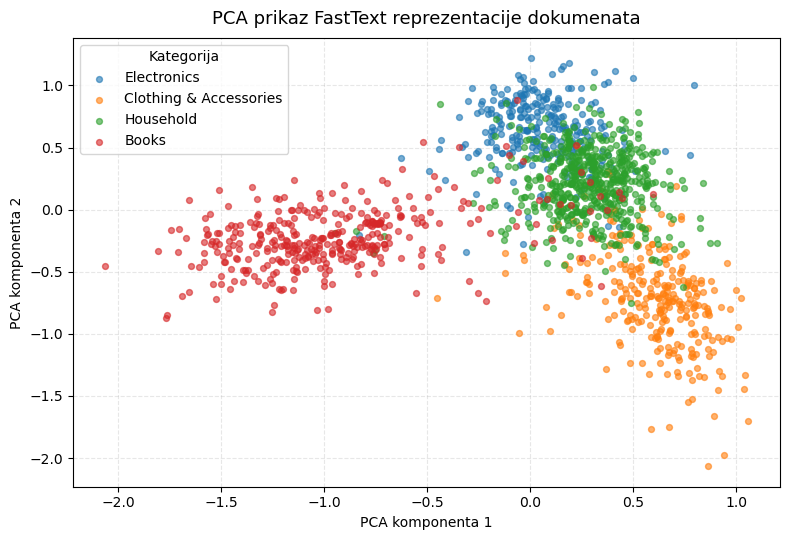

Objašnjena varijansa PCA komponenti:
PC1: 0.1784
PC2: 0.1233
Ukupno: 0.3017


In [117]:
sample_size = min(1500, X_train_ft.shape[0])
sample_indices = np.random.RandomState(RANDOM_STATE).choice(
    X_train_ft.shape[0],
    size=sample_size,
    replace=False
)

X_ft_sample = X_train_ft[sample_indices]
y_ft_sample = y_train.reset_index(drop=True).iloc[sample_indices]

pca_ft = PCA(n_components=2, random_state=RANDOM_STATE)
X_ft_pca = pca_ft.fit_transform(X_ft_sample)

fig, ax = plt.subplots(figsize=(8, 5.5))

for category in y_ft_sample.unique():
    mask = y_ft_sample == category
    ax.scatter(
        X_ft_pca[mask, 0],
        X_ft_pca[mask, 1],
        label=category,
        alpha=0.6,
        s=18
    )

ax.set_title("PCA prikaz FastText reprezentacije dokumenata", fontsize=13, pad=10)
ax.set_xlabel("PCA komponenta 1")
ax.set_ylabel("PCA komponenta 2")
ax.set_axisbelow(True)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(title="Kategorija")

plt.tight_layout()
plt.show()

print("Objašnjena varijansa PCA komponenti:")
print(f"PC1: {pca_ft.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_ft.explained_variance_ratio_[1]:.4f}")
print(f"Ukupno: {pca_ft.explained_variance_ratio_.sum():.4f}")

PCA prikaz svodi 100-dimenzionalne FastText dokument-vektore na dve komponente radi vizuelizacije. Prve dve komponente objašnjavaju ukupno 30.17% varijanse, pa prikaz daje samo delimičan uvid u strukturu embedding prostora.

Na grafikonu se vidi da se `Books` i `Clothing & Accessories` prilično jasno izdvajaju, dok se `Household` i `Electronics` delimično preklapaju. Kao i kod Word2Vec reprezentacije, ovaj prikaz služi samo kao okvirna provera, dok će se stvarni kvalitet reprezentacije proceniti kroz klasifikacione modele.

### 4.6 Sentence Transformers / BERT-like embeddings

Sentence Transformers predstavljaju savremeniji pristup reprezentaciji teksta zasnovan na transformer arhitekturama. Za razliku od BoW, TF-IDF, Word2Vec i FastText reprezentacija, koje se oslanjaju na tokene ili prosečne vektore reči, Sentence Transformers direktno formiraju gust vektor za ceo tekstualni opis.

Ovi modeli su zasnovani na BERT-like arhitekturama i prethodno su trenirani na velikim tekstualnim korpusima. Zbog toga mogu da uhvate širi semantički kontekst teksta, a ne samo pojedinačne reči i njihove frekvencije.

Za ovu reprezentaciju koristi se varijanta `text_normalized`, jer transformer modeli bolje rade sa prirodnijim tekstom nego sa tekstom iz koga su uklonjene stop-reči.

In [118]:
# sentence-transformers instalacija
#!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [119]:
sbert_text_variant = "text_normalized"

X_train_sbert_text = X_train_variants[sbert_text_variant].astype(str)
X_test_sbert_text = X_test_variants[sbert_text_variant].astype(str)

print("Izabrana tekstualna varijanta za Sentence Transformers:", sbert_text_variant)
print("Broj trening dokumenata:", X_train_sbert_text.shape[0])
print("Broj test dokumenata:", X_test_sbert_text.shape[0])

Izabrana tekstualna varijanta za Sentence Transformers: text_normalized
Broj trening dokumenata: 22241
Broj test dokumenata: 5561


Za formiranje embeddinga koristi se model `all-MiniLM-L6-v2`. To je kompaktan Sentence Transformer model koji daje vektore od 384 dimenzije. Pogodan je za praktične eksperimente jer je znatno brži od većih BERT modela, a i dalje daje semantički bogate reprezentacije teksta.

Model se ne trenira dodatno nad našim datasetom, već se koristi kao prethodno trenirani BERT-like encoder. Time se dobija savremena reprezentacija teksta bez potrebe za skupim fine-tuning procesom.

In [120]:
sbert_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("Maksimalna dužina ulaza modela:", sbert_model.max_seq_length)
print("Dimenzionalnost embedding vektora:", sbert_model.get_sentence_embedding_dimension())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Maksimalna dužina ulaza modela: 256
Dimenzionalnost embedding vektora: 384


Embedding vektori se formiraju posebno za trening i test skup. Kao i kod prethodnih reprezentacija, test skup se ne koristi za treniranje modela. Ovde se prethodno trenirani model koristi samo za transformaciju tekstova u numeričke vektore.

Kod dužih opisa proizvoda model automatski koristi ograničenje maksimalne dužine ulaza, pa veoma dugi tekstovi mogu biti skraćeni na početni deo opisa.

In [121]:
X_train_sbert = sbert_model.encode(
    X_train_sbert_text.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

X_test_sbert = sbert_model.encode(
    X_test_sbert_text.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Dimenzije Sentence Transformer trening reprezentacije:", X_train_sbert.shape)
print("Dimenzije Sentence Transformer test reprezentacije:", X_test_sbert.shape)

Batches:   0%|          | 0/348 [00:00<?, ?it/s]

Batches:   0%|          | 0/87 [00:00<?, ?it/s]

Dimenzije Sentence Transformer trening reprezentacije: (22241, 384)
Dimenzije Sentence Transformer test reprezentacije: (5561, 384)


Dobijeni Sentence Transformer embedding vektori imaju dimenzije `22241 × 384` za trening skup i `5561 × 384` za test skup. Za razliku od BoW i TF-IDF reprezentacija, koje imaju 20.000 dimenzija i retku strukturu, Sentence Transformer daje gust vektor od 384 dimenzije za svaki opis proizvoda.

Ova reprezentacija ne računa eksplicitno frekvencije tokena, već pokušava da predstavi značenje celog tekstualnog opisa.

In [122]:
sbert_norms_train = np.linalg.norm(X_train_sbert, axis=1)
sbert_norms_test = np.linalg.norm(X_test_sbert, axis=1)

print("Prosečna norma embeddinga u trening skupu:", sbert_norms_train.mean().round(4))
print("Prosečna norma embeddinga u test skupu:", sbert_norms_test.mean().round(4))
print("Minimalna norma u trening skupu:", sbert_norms_train.min().round(4))
print("Maksimalna norma u trening skupu:", sbert_norms_train.max().round(4))

Prosečna norma embeddinga u trening skupu: 1.0
Prosečna norma embeddinga u test skupu: 1.0
Minimalna norma u trening skupu: 1.0
Maksimalna norma u trening skupu: 1.0


Pošto je korišćen parametar `normalize_embeddings=True`, svi embedding vektori imaju jediničnu normu. To je korisno za računanje kosinusne sličnosti, jer se tada poređenje tekstova zasniva prvenstveno na uglu između vektora, a ne na njihovoj dužini.

In [123]:
sample_position = 0

sample_embedding = X_train_sbert[sample_position].reshape(1, -1)
similarities = cosine_similarity(sample_embedding, X_train_sbert).ravel()

# Izbacuje se sam dokument iz poređenja
similarities[sample_position] = -1

top_similar_indices = similarities.argsort()[::-1][:5]

print("Kategorija početnog primera:", y_train.iloc[sample_position])
print("\nPočetni opis:")
print(X_train_sbert_text.iloc[sample_position][:700])

print("\nNajbliži primeri prema Sentence Transformer embeddingu:")
for rank, idx in enumerate(top_similar_indices, start=1):
    print("\n" + "=" * 100)
    print(f"Rang {rank}")
    print("Sličnost:", round(similarities[idx], 4))
    print("Kategorija:", y_train.iloc[idx])
    print(X_train_sbert_text.iloc[idx][:500])

Kategorija početnog primera: Electronics

Početni opis:
zaptin 2nd gen mp4 player with voice recorder/fm radio/video/music player product description portable mp3 mp4 player, video player, music player, media player, audio player with photo viewer, e-book reader, voice recorder, games and movies. please note this mp4 player is not an apple product and does not support itunes. 1.8 inch tft lcd, full color display support amv video, built-in game, digital record function, flash disk storage function, e-book function, support text file. 1.78 inch high resolution real color lcd screen. also note that this has no inbuilt memory so please use one external memory card of any size upto 32 gb. features: 2nd mp4 inspire you to listen music on it and it is 

Najbliži primeri prema Sentence Transformer embeddingu:

Rang 1
Sličnost: 0.8272
Kategorija: Electronics
raptas 2nd mp4 player 1.8 inch lcd screen with s10 wireless led bluetooth speakers handfree with calling functions compatible with all sm

Primer kosinusne sličnosti pokazuje da Sentence Transformer embedding prostor dobro povezuje semantički slične opise. Početni primer pripada kategoriji `Electronics` i opisuje MP3/MP4 plejer. Pet najbližih opisa takođe pripada kategoriji `Electronics` i odnosi se na slične uređaje: MP4 plejere, audio/video reprodukciju, radio, memorijske kartice i slične funkcije.

Ovo pokazuje da embedding reprezentacija ne hvata samo pojedinačne tokene, već i širi sadržaj opisa proizvoda.

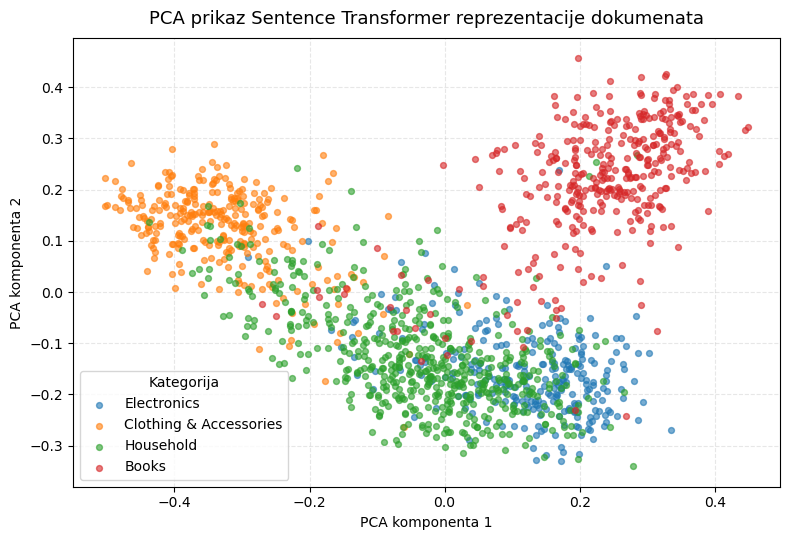

Objašnjena varijansa PCA komponenti:
PC1: 0.0551
PC2: 0.0386
Ukupno: 0.0937


In [124]:
sample_size = min(1500, X_train_sbert.shape[0])
sample_indices = np.random.RandomState(RANDOM_STATE).choice(
    X_train_sbert.shape[0],
    size=sample_size,
    replace=False
)

X_sbert_sample = X_train_sbert[sample_indices]
y_sbert_sample = y_train.reset_index(drop=True).iloc[sample_indices]

pca_sbert = PCA(n_components=2, random_state=RANDOM_STATE)
X_sbert_pca = pca_sbert.fit_transform(X_sbert_sample)

fig, ax = plt.subplots(figsize=(8, 5.5))

for category in y_sbert_sample.unique():
    mask = y_sbert_sample == category
    ax.scatter(
        X_sbert_pca[mask, 0],
        X_sbert_pca[mask, 1],
        label=category,
        alpha=0.6,
        s=18
    )

ax.set_title("PCA prikaz Sentence Transformer reprezentacije dokumenata", fontsize=13, pad=10)
ax.set_xlabel("PCA komponenta 1")
ax.set_ylabel("PCA komponenta 2")
ax.set_axisbelow(True)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(title="Kategorija")

plt.tight_layout()
plt.show()

print("Objašnjena varijansa PCA komponenti:")
print(f"PC1: {pca_sbert.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_sbert.explained_variance_ratio_[1]:.4f}")
print(f"Ukupno: {pca_sbert.explained_variance_ratio_.sum():.4f}")

PCA prikaz svodi 384-dimenzionalne Sentence Transformer embeddinge na dve komponente radi vizuelizacije. Prve dve komponente objašnjavaju ukupno 9.37% varijanse, pa ovaj prikaz daje samo delimičan uvid u strukturu prostora reprezentacija.

Ipak, na grafikonu se vidi jasno grupisanje pojedinih kategorija. Kategorija `Books` se dobro izdvaja, `Clothing & Accessories` takođe formira prepoznatljiv skup, dok se `Household` i `Electronics` delimično preklapaju. Konačna procena kvaliteta ove reprezentacije biće urađena kroz klasifikacione modele.

#### Uticaj dužine teksta na transformer reprezentaciju

Transformer modeli imaju ograničenje maksimalne dužine ulaza. Kod korišćenog modela `all-MiniLM-L6-v2` maksimalna dužina iznosi 256 tokena. Ako je opis proizvoda duži od toga, model koristi samo početni deo teksta, dok se ostatak skraćuje.

Zbog toga je važno proveriti koliko opisa proizvoda prelazi maksimalnu dužinu ulaza, jer predugi tekstovi mogu dovesti do gubitka dela informacija u transformer reprezentaciji.

In [125]:
sbert_tokenizer = sbert_model.tokenizer
max_sbert_length = sbert_model.max_seq_length

def transformer_token_length(text):
    return len(sbert_tokenizer.tokenize(str(text))) + 2

sbert_train_token_lengths = X_train_sbert_text.apply(transformer_token_length)
sbert_test_token_lengths = X_test_sbert_text.apply(transformer_token_length)

sbert_length_summary = pd.DataFrame({
    "train": sbert_train_token_lengths.describe(),
    "test": sbert_test_token_lengths.describe()
})

display(sbert_length_summary.round(2))

train_too_long = (sbert_train_token_lengths > max_sbert_length).mean() * 100
test_too_long = (sbert_test_token_lengths > max_sbert_length).mean() * 100

print("Maksimalna dužina ulaza modela:", max_sbert_length)
print(f"Udeo trening opisa dužih od limita: {train_too_long:.2f}%")
print(f"Udeo test opisa dužih od limita: {test_too_long:.2f}%")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (362 > 256). Running this sequence through the model will result in indexing errors


,train,test
count,22241.00,5561.00
mean,156.91,155.02
std,229.98,190.56
min,3.00,3.00
25%,51.00,50.00
50%,106.00,106.00
75%,198.00,201.00
max,10488.00,3618.00


Maksimalna dužina ulaza modela: 256
Udeo trening opisa dužih od limita: 17.10%
Udeo test opisa dužih od limita: 17.14%


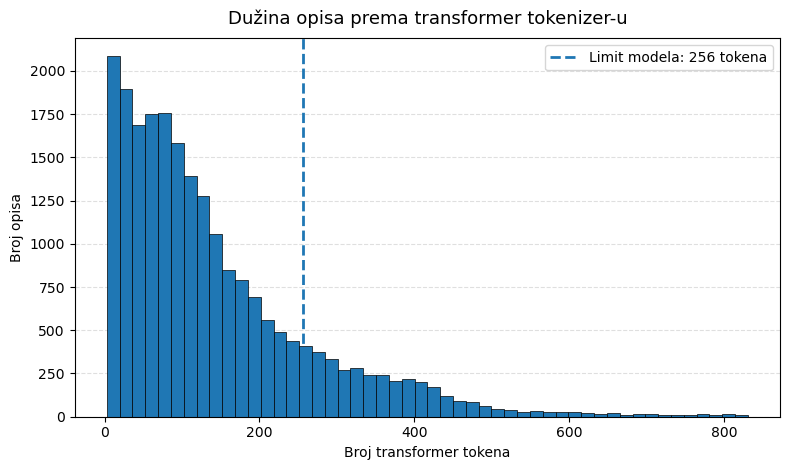

In [126]:
fig, ax = plt.subplots(figsize=(8, 4.8))

upper_limit = np.percentile(sbert_train_token_lengths, 99)

ax.hist(
    sbert_train_token_lengths[sbert_train_token_lengths <= upper_limit],
    bins=50,
    edgecolor="black",
    linewidth=0.5
)

ax.axvline(
    max_sbert_length,
    linestyle="--",
    linewidth=2,
    label=f"Limit modela: {max_sbert_length} tokena"
)

ax.set_title("Dužina opisa prema transformer tokenizer-u", fontsize=13, pad=10)
ax.set_xlabel("Broj transformer tokena")
ax.set_ylabel("Broj opisa")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

Rezultati pokazuju da većina opisa proizvoda staje u ograničenje modela `all-MiniLM-L6-v2`, ali ne i svi. Medijana dužine iznosi oko 106 transformer tokena, dok je treći kvartil oko 200 tokena, što znači da je veliki deo opisa kraći od limita od 256 tokena.
Ipak, oko 17.1% opisa u trening i test skupu prelazi maksimalnu dužinu ulaza. Kod tih primera Sentence Transformer model koristi samo početni deo teksta, pa deo informacija iz veoma dugih opisa može biti izgubljen. Ovo je važno ograničenje transformer reprezentacije, posebno kod e-commerce podataka gde opisi mogu sadržati dugačke specifikacije, liste karakteristika i dodatne promotivne tekstove.
Ova analiza pokazuje da kod savremenih BERT-like modela kvalitet reprezentacije ne zavisi samo od čišćenja i normalizacije teksta, već i od dužine dokumenta i ograničenja samog modela.

## 5. Klasifikacija i evaluacija

Nakon formiranja različitih tekstualnih reprezentacija, sledeći korak je evaluacija klasifikacionih modela. Cilj ovog dela je da se proveri kako različite reprezentacije i različiti nivoi predobrade utiču na performanse klasifikacije e-commerce proizvoda.

Za evaluaciju se koriste metrike `accuracy`, `macro F1` i `weighted F1`. Posebno je važna metrika `macro F1`, jer sve klase tretira ravnopravno i pogodna je kada postoji neravnomerna raspodela kategorija.

### 5.1 Baseline model

Pre treniranja klasifikacionih modela definiše se baseline model. 
Koristi se `DummyClassifier` sa strategijom `most_frequent`, koji uvek predviđa najzastupljeniju klasu iz trening skupa. Pošto je najzastupljenija kategorija `Household`, ovaj model ne koristi informacije iz teksta, već samo raspodelu klasa.

In [127]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [128]:
def evaluate_predictions(y_true, y_pred, model_name, representation):
    return {
        "model": model_name,
        "representation": representation,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

In [129]:
baseline_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

# DummyClassifier zahteva X ulaz, ali ga ne koristi za donošenje odluke.
baseline_model.fit(X_train_variants["text_no_stop"], y_train)

y_pred_baseline = baseline_model.predict(X_test_variants["text_no_stop"])

baseline_metrics = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_baseline,
    model_name="DummyClassifier",
    representation="most_frequent baseline"
)

baseline_results_df = pd.DataFrame([baseline_metrics])
display(baseline_results_df.round(4))

,model,representation,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,DummyClassifier,most_frequent baseline,0.38,0.095,0.25,0.1377,0.2092


In [130]:
print("Najčešća klasa u trening skupu:", y_train.value_counts().idxmax())
print("Broj predikcija po klasama kod baseline modela:")
print(pd.Series(y_pred_baseline).value_counts())

Najčešća klasa u trening skupu: Household
Broj predikcija po klasama kod baseline modela:
Household    5561
Name: count, dtype: int64


In [131]:
print(classification_report(
    y_test,
    y_pred_baseline,
    zero_division=0
))

                        precision    recall  f1-score   support

                 Books       0.00      0.00      0.00      1251
Clothing & Accessories       0.00      0.00      0.00      1135
           Electronics       0.00      0.00      0.00      1062
             Household       0.38      1.00      0.55      2113

              accuracy                           0.38      5561
             macro avg       0.09      0.25      0.14      5561
          weighted avg       0.14      0.38      0.21      5561



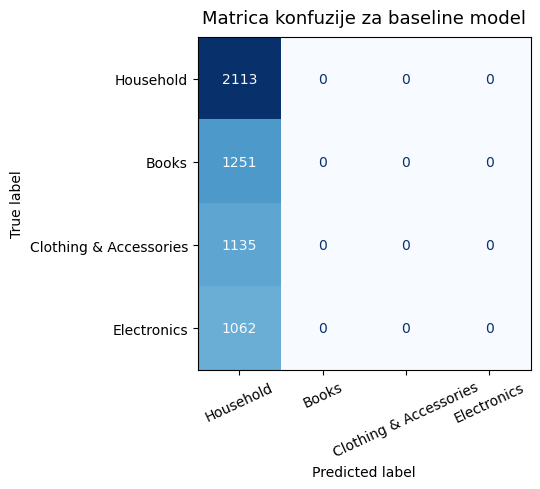

In [132]:
labels = ["Household", "Books", "Clothing & Accessories", "Electronics"]

cm_baseline = confusion_matrix(
    y_test,
    y_pred_baseline,
    labels=labels
)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    xticks_rotation=25
)

ax.set_title("Matrica konfuzije za baseline model", fontsize=13, pad=10)

plt.tight_layout()
plt.show()

Baseline model ostvaruje `accuracy` od 0.38, što odgovara udelu klase `Household` u test skupu. Međutim, `macro F1` iznosi samo 0.1377, jer model potpuno zanemaruje klase `Books`, `Clothing & Accessories` i `Electronics`.

Matrica konfuzije potvrđuje da su svi test primeri predviđeni kao `Household`. Zbog toga ovaj rezultat pokazuje zašto nije dovoljno posmatrati samo tačnost, već su potrebne i metrike kao što su `macro F1` i `weighted F1`. Svi naredni modeli treba da značajno nadmaše ovaj baseline rezultat.

### 5.2 Klasični ML modeli na TF-IDF reprezentaciji

U ovoj sekciji se porede klasični modeli mašinskog učenja nad TF-IDF reprezentacijom teksta. TF-IDF je izabran kao osnovna reprezentacija za izbor modela jer, za razliku od BoW pristupa, ne koristi samo sirovu frekvenciju tokena, već uzima u obzir i njihov značaj u okviru celog korpusa.

Porede se sledeći modeli:

- `Multinomial Naive Bayes`
- `Complement Naive Bayes`
- `Logistic Regression`
- `LinearSVC`
- `Random Forest`

Svi modeli se treniraju na istom trening skupu i evaluiraju na istom test skupu. Kao glavne metrike koriste se `accuracy`, `macro F1` i `weighted F1`.

In [133]:
import time
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

In [134]:
tfidf_models = {
    "MultinomialNB": MultinomialNB(),
    
    "ComplementNB": ComplementNB(),
    
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    
    "LinearSVC": LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ),
    
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

Modeli `LogisticRegression`, `LinearSVC` i `RandomForest` koriste `class_weight="balanced"`, jer skup podataka ima umerenu neravnotežu klasa. Na taj način se manjinskim klasama daje veća težina tokom učenja.
Kod Naive Bayes modela ovo podešavanje se ne koristi direktno, ali su oni često dobra početna tačka za tekstualnu klasifikaciju nad TF-IDF reprezentacijom.

In [135]:
tfidf_model_results = []
tfidf_trained_models = {}

for model_name, model in tfidf_models.items():
    print(f"Treniranje modela: {model_name}")
    start_time = time.time()
    
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    elapsed_time = time.time() - start_time
    
    metrics = evaluate_predictions(
        y_true=y_test,
        y_pred=y_pred,
        model_name=model_name,
        representation="TF-IDF"
    )
    metrics["training_time_sec"] = elapsed_time
    
    tfidf_model_results.append(metrics)
    tfidf_trained_models[model_name] = model
    
    print(f"Završeno za {elapsed_time:.2f} sekundi")
    print("-" * 60)

tfidf_results_df = pd.DataFrame(tfidf_model_results)
tfidf_results_df = tfidf_results_df.sort_values("macro_f1", ascending=False)

display(tfidf_results_df.round(4))

Treniranje modela: MultinomialNB
Završeno za 0.06 sekundi
------------------------------------------------------------
Treniranje modela: ComplementNB
Završeno za 0.09 sekundi
------------------------------------------------------------
Treniranje modela: LogisticRegression
Završeno za 10.85 sekundi
------------------------------------------------------------
Treniranje modela: LinearSVC
Završeno za 0.71 sekundi
------------------------------------------------------------
Treniranje modela: RandomForest
Završeno za 13.87 sekundi
------------------------------------------------------------


,model,representation,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_sec
3,LinearSVC,TF-IDF,0.9595,0.9605,0.9584,0.9594,0.9595,0.7093
2,LogisticRegression,TF-IDF,0.9545,0.9546,0.9545,0.9545,0.9545,10.8456
1,ComplementNB,TF-IDF,0.9408,0.9414,0.9405,0.9407,0.9407,0.0857
0,MultinomialNB,TF-IDF,0.9387,0.9449,0.9340,0.9389,0.9386,0.0608
4,RandomForest,TF-IDF,0.9306,0.9354,0.9263,0.9304,0.9304,13.8696


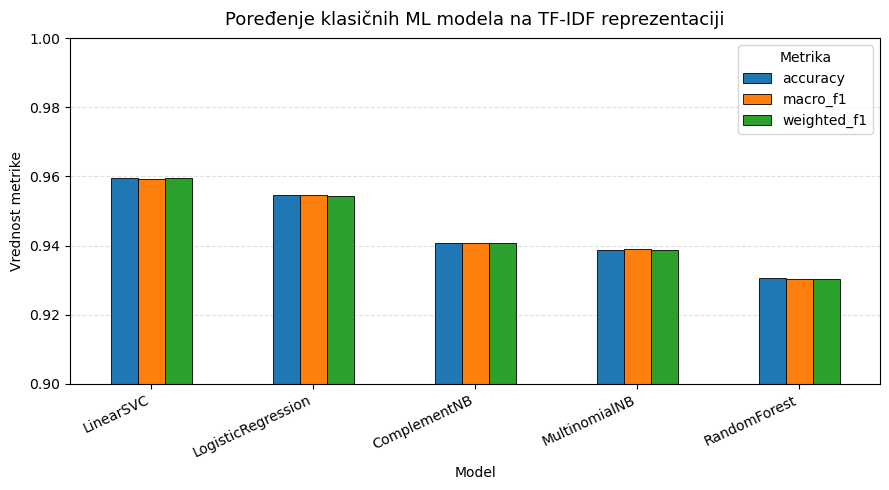

In [136]:
metric_plot_df = tfidf_results_df[
    ["model", "accuracy", "macro_f1", "weighted_f1"]
].set_index("model")

fig, ax = plt.subplots(figsize=(9, 5))

metric_plot_df.plot(
    kind="bar",
    ax=ax,
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Poređenje klasičnih ML modela na TF-IDF reprezentaciji", fontsize=13, pad=10)
ax.set_xlabel("Model")
ax.set_ylabel("Vrednost metrike")
ax.set_ylim(0.90, 1.00)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Metrika")

plt.tight_layout()
plt.show()

Grafikon prikazuje poređenje klasičnih modela prema tri metrike: `accuracy`, `macro F1` i `weighted F1`. Iako su sve tri metrike prikazane radi potpunijeg poređenja, modeli se rangiraju prema `macro F1` vrednosti, jer ova metrika ravnopravno tretira sve kategorije.

Rezultati pokazuju da su vrednosti sve tri metrike veoma slične kod svakog modela, što znači da modeli nemaju veliki nesklad između ukupne tačnosti i performansi po klasama. Najbolji rezultat postiže `LinearSVC`, pa se ovaj model koristi u narednim analizama za poređenje različitih reprezentacija i varijanti predobrade.

In [137]:
best_tfidf_model_name = tfidf_results_df.iloc[0]["model"]
best_tfidf_model = tfidf_trained_models[best_tfidf_model_name]

print("Najbolji model prema macro F1 metrici:", best_tfidf_model_name)
print("Rezultati najboljeg modela:")
display(tfidf_results_df.iloc[[0]].round(4))

Najbolji model prema macro F1 metrici: LinearSVC
Rezultati najboljeg modela:


,model,representation,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_sec
3,LinearSVC,TF-IDF,0.9595,0.9605,0.9584,0.9594,0.9595,0.7093


In [138]:
y_pred_best_tfidf = best_tfidf_model.predict(X_test_tfidf)

print(classification_report(
    y_test,
    y_pred_best_tfidf,
    labels=labels,
    zero_division=0
))

                        precision    recall  f1-score   support

             Household       0.95      0.97      0.96      2113
                 Books       0.96      0.94      0.95      1251
Clothing & Accessories       0.98      0.98      0.98      1135
           Electronics       0.94      0.94      0.94      1062

              accuracy                           0.96      5561
             macro avg       0.96      0.96      0.96      5561
          weighted avg       0.96      0.96      0.96      5561



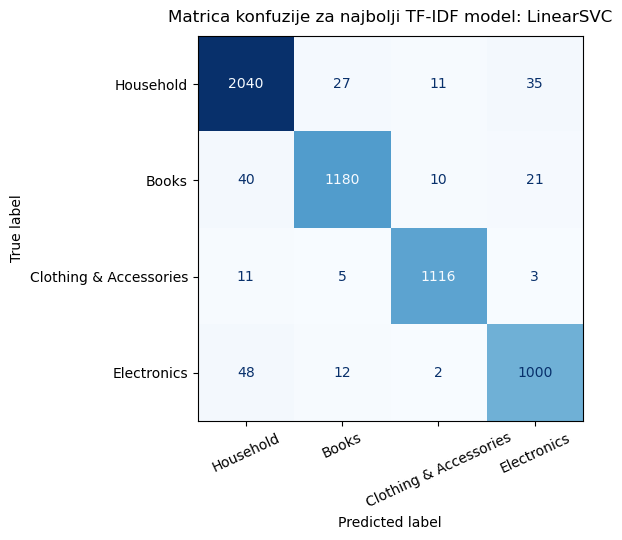

In [139]:
cm_best_tfidf = confusion_matrix(
    y_test,
    y_pred_best_tfidf,
    labels=labels
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_tfidf,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    xticks_rotation=25
)

ax.set_title(f"Matrica konfuzije za najbolji TF-IDF model: {best_tfidf_model_name}", fontsize=12, pad=10)

plt.tight_layout()
plt.show()

Rezultati pokazuju da svi klasični modeli značajno nadmašuju baseline model. Modeli su rangirani prema `macro F1` metrici, jer ona ravnopravno tretira sve klase. Najbolji rezultat ostvaruje `LinearSVC`, sa `accuracy = 0.9595`, `macro F1 = 0.9594` i `weighted F1 = 0.9595`.

Vrlo sličan rezultat postiže `LogisticRegression`, sa `macro F1 = 0.9545`, ali uz znatno duže vreme treniranja. Naive Bayes modeli daju nešto slabije, ali i dalje veoma dobre rezultate. `RandomForest` ima najniži `macro F1` među testiranim modelima, što pokazuje da modeli zasnovani na stablima nisu najbolji izbor za visokodimenzionalne sparse tekstualne reprezentacije.

Classification report pokazuje da `LinearSVC` dobro prepoznaje sve četiri kategorije. Najbolji F1-score ima kategorija `Clothing & Accessories` (`0.98`), dok su `Household`, `Books` i `Electronics` takođe vrlo dobro klasifikovane. Matrica konfuzije pokazuje da je broj grešaka mali, a najviše zabuna javlja se između kategorija `Electronics` i `Household`, kao i između `Books` i `Household`.

Zbog najboljeg `macro F1` rezultata i kratkog vremena treniranja, `LinearSVC` se bira kao osnovni model za naredno poređenje različitih reprezentacija teksta.

### 5.3 Poređenje reprezentacija nad najboljim modelom

Najbolji model `LinearSVC` se koristi za poređenje različitih reprezentacija teksta.
Cilj je da se proveri kako izbor reprezentacije utiče na performanse klasifikacije, pri čemu se koristi isti trening i test skup.

In [140]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [141]:
representation_data = {
    "BoW": (X_train_bow, X_test_bow),
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
    "Word2Vec": (X_train_w2v, X_test_w2v),
    "FastText": (X_train_ft, X_test_ft),
    "SentenceTransformer": (X_train_sbert, X_test_sbert)
}

print("Reprezentacije za poređenje:")
for representation_name, (X_tr, X_te) in representation_data.items():
    print(f"{representation_name:<20} train: {X_tr.shape} | test: {X_te.shape}")

Reprezentacije za poređenje:
BoW                  train: (22241, 20000) | test: (5561, 20000)
TF-IDF               train: (22241, 20000) | test: (5561, 20000)
Word2Vec             train: (22241, 100) | test: (5561, 100)
FastText             train: (22241, 100) | test: (5561, 100)
SentenceTransformer  train: (22241, 384) | test: (5561, 384)


Za `BoW` i `TF-IDF` koriste se sparse matrice i model se trenira direktno nad njima. Kod gustih embedding reprezentacija (`Word2Vec`, `FastText` i `Sentence Transformer`) dodaje se `StandardScaler`, jer se radi o kontinuiranim numeričkim vektorima. Time se vrednosti različitih dimenzija dovode na uporedivu skalu.
U svim slučajevima koristi se isti osnovni model: `LinearSVC` sa `class_weight="balanced"`.

In [142]:
def build_linear_svc_for_representation(representation_name):
    linear_svc = LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    )
    
    if representation_name in ["Word2Vec", "FastText", "SentenceTransformer"]:
        return make_pipeline(
            StandardScaler(),
            linear_svc
        )
    
    return linear_svc

In [143]:
representation_results = []
representation_trained_models = {}

for representation_name, (X_tr, X_te) in representation_data.items():
    print(f"Treniranje LinearSVC modela nad reprezentacijom: {representation_name}")
    start_time = time.time()
    
    model = build_linear_svc_for_representation(representation_name)
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    elapsed_time = time.time() - start_time
    
    metrics = evaluate_predictions(
        y_true=y_test,
        y_pred=y_pred,
        model_name="LinearSVC",
        representation=representation_name
    )
    metrics["training_time_sec"] = elapsed_time
    
    representation_results.append(metrics)
    representation_trained_models[representation_name] = model
    
    print(f"Završeno za {elapsed_time:.2f} sekundi")
    print("-" * 60)

representation_results_df = pd.DataFrame(representation_results)
representation_results_df = representation_results_df.sort_values("macro_f1", ascending=False)

display(representation_results_df.round(4))

Treniranje LinearSVC modela nad reprezentacijom: BoW
Završeno za 20.88 sekundi
------------------------------------------------------------
Treniranje LinearSVC modela nad reprezentacijom: TF-IDF
Završeno za 0.69 sekundi
------------------------------------------------------------
Treniranje LinearSVC modela nad reprezentacijom: Word2Vec
Završeno za 1.34 sekundi
------------------------------------------------------------
Treniranje LinearSVC modela nad reprezentacijom: FastText
Završeno za 1.43 sekundi
------------------------------------------------------------
Treniranje LinearSVC modela nad reprezentacijom: SentenceTransformer
Završeno za 8.97 sekundi
------------------------------------------------------------


,model,representation,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_sec
1,LinearSVC,TF-IDF,0.9595,0.9605,0.9584,0.9594,0.9595,0.6881
0,LinearSVC,BoW,0.9426,0.9427,0.9412,0.9420,0.9426,20.8754
4,LinearSVC,SentenceTransformer,0.9374,0.9366,0.9392,0.9378,0.9374,8.9699
2,LinearSVC,Word2Vec,0.9376,0.9377,0.9370,0.9372,0.9375,1.3361
3,LinearSVC,FastText,0.9378,0.9374,0.9370,0.9371,0.9377,1.4254


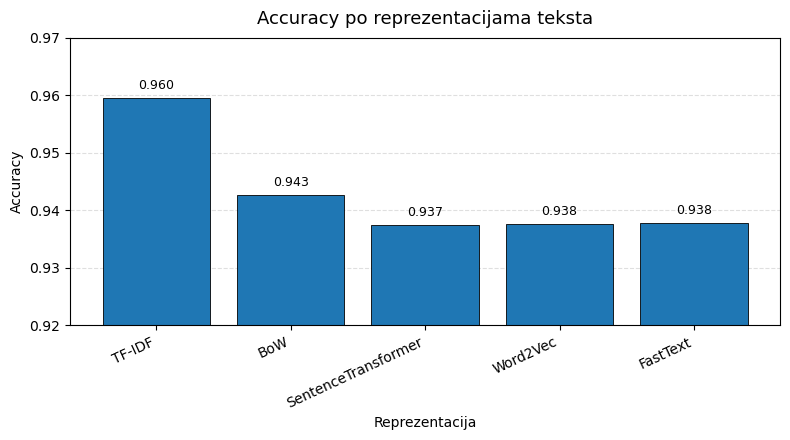

In [144]:
plot_df = representation_results_df.sort_values("macro_f1", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    plot_df["representation"],
    plot_df["accuracy"],
    edgecolor="black",
    linewidth=0.6
)

for i, value in enumerate(plot_df["accuracy"]):
    ax.text(
        i,
        value + 0.001,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Accuracy po reprezentacijama teksta", fontsize=13, pad=10)
ax.set_xlabel("Reprezentacija")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.92, 0.97)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

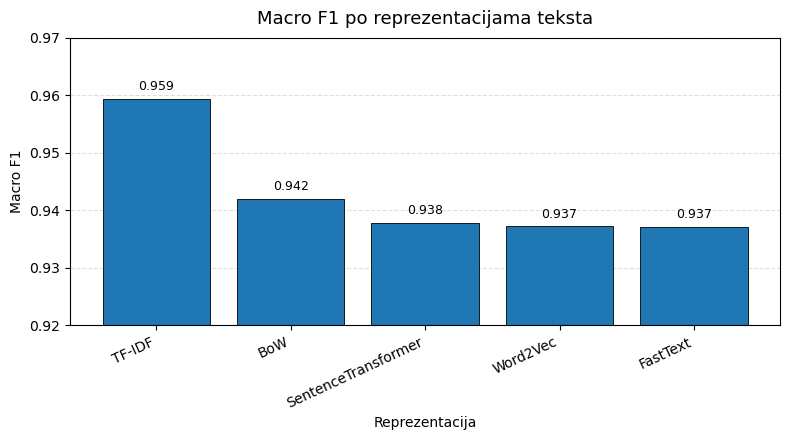

In [145]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    plot_df["representation"],
    plot_df["macro_f1"],
    edgecolor="black",
    linewidth=0.6
)

for i, value in enumerate(plot_df["macro_f1"]):
    ax.text(
        i,
        value + 0.001,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Macro F1 po reprezentacijama teksta", fontsize=13, pad=10)
ax.set_xlabel("Reprezentacija")
ax.set_ylabel("Macro F1")
ax.set_ylim(0.92, 0.97)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

In [146]:
best_representation_name = representation_results_df.iloc[0]["representation"]
best_representation_model = representation_trained_models[best_representation_name]

print("Najbolja reprezentacija prema macro F1 metrici:", best_representation_name)
display(representation_results_df.iloc[[0]].round(4))

Najbolja reprezentacija prema macro F1 metrici: TF-IDF


,model,representation,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_sec
1,LinearSVC,TF-IDF,0.9595,0.9605,0.9584,0.9594,0.9595,0.6881


In [147]:
X_test_best_representation = representation_data[best_representation_name][1]
y_pred_best_representation = best_representation_model.predict(X_test_best_representation)

print(classification_report(
    y_test,
    y_pred_best_representation,
    labels=labels,
    zero_division=0
))

                        precision    recall  f1-score   support

             Household       0.95      0.97      0.96      2113
                 Books       0.96      0.94      0.95      1251
Clothing & Accessories       0.98      0.98      0.98      1135
           Electronics       0.94      0.94      0.94      1062

              accuracy                           0.96      5561
             macro avg       0.96      0.96      0.96      5561
          weighted avg       0.96      0.96      0.96      5561



Rezultati pokazuju da najbolji rezultat nad `LinearSVC` modelom daje `TF-IDF` reprezentacija, sa `accuracy = 0.9595` i `macro F1 = 0.9594`. Druga najbolja reprezentacija je `BoW`, sa `macro F1 = 0.9420`, ali uz znatno duže vreme treniranja.
Embedding reprezentacije daju nešto slabije, ali i dalje vrlo dobre rezultate. `SentenceTransformer`, `Word2Vec` i `FastText` imaju veoma slične `macro F1` vrednosti, približno između `0.935` i `0.938`. To pokazuje da guste embedding reprezentacije uspešno hvataju deo semantičke strukture tekstova, ali u ovom konkretnom zadatku klasična `TF-IDF` reprezentacija bolje odgovara linearnom klasifikatoru.
Kao najbolja reprezentacija prema `macro F1` metrici izabrana je `TF-IDF`. Ovaj rezultat potvrđuje da kod e-commerce klasifikacije jednostavne sparse reprezentacije mogu biti veoma konkurentne, posebno kada se kombinuju sa linearnim modelima kao što je `LinearSVC`.

### 5.4 Uticaj varijanti predobrade na performanse

Najbolji rezultat daje kombinacija `TF-IDF` reprezentacije i `LinearSVC` modela. U ovom delu se ispituje kako različite varijante predobrade teksta utiču na performanse iste kombinacije modela i reprezentacije.
Porede se sledeće varijante teksta: `text_raw`, `text_normalized`, `text_alpha`, `text_no_stop`, `text_stemmed` i `text_lemmatized`.

Za svaku varijantu se posebno formira TF-IDF reprezentacija nad trening skupom, zatim se trenira isti `LinearSVC` model i evaluira na odgovarajućem test skupu.
Svi eksperimenti koriste iste parametre vektorizacije: `max_features=20000`, `min_df=2` i unigram tokenizaciju.

In [148]:
preprocessing_variants_for_modeling = [
    "text_raw",
    "text_normalized",
    "text_alpha",
    "text_no_stop",
    "text_stemmed",
    "text_lemmatized"
]

preprocessing_results = []
preprocessing_vectorizers = {}
preprocessing_models = {}

for text_variant in preprocessing_variants_for_modeling:
    print(f"Obrada varijante: {text_variant}")
    start_time = time.time()
    
    X_train_text_variant = train_df[text_variant].astype(str)
    X_test_text_variant = test_df[text_variant].astype(str)
    
    vectorizer = TfidfVectorizer(
        max_features=20000,
        min_df=2,
        ngram_range=(1, 1)
    )
    
    X_train_variant_tfidf = vectorizer.fit_transform(X_train_text_variant)
    X_test_variant_tfidf = vectorizer.transform(X_test_text_variant)
    
    model = LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    )
    
    model.fit(X_train_variant_tfidf, y_train)
    y_pred_variant = model.predict(X_test_variant_tfidf)
    
    elapsed_time = time.time() - start_time
    
    metrics = evaluate_predictions(
        y_true=y_test,
        y_pred=y_pred_variant,
        model_name="LinearSVC",
        representation=f"TF-IDF + {text_variant}"
    )
    
    metrics["text_variant"] = text_variant
    metrics["vocabulary_size"] = len(vectorizer.vocabulary_)
    metrics["training_time_sec"] = elapsed_time
    
    preprocessing_results.append(metrics)
    preprocessing_vectorizers[text_variant] = vectorizer
    preprocessing_models[text_variant] = model
    
    print(f"Veličina vokabulara: {len(vectorizer.vocabulary_)}")
    print(f"Završeno za {elapsed_time:.2f} sekundi")
    print("-" * 60)

preprocessing_results_df = pd.DataFrame(preprocessing_results)
preprocessing_results_df = preprocessing_results_df.sort_values("macro_f1", ascending=False)

display(preprocessing_results_df[
    [
        "text_variant",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "vocabulary_size",
        "training_time_sec"
    ]
].round(4))

Obrada varijante: text_raw
Veličina vokabulara: 20000
Završeno za 4.95 sekundi
------------------------------------------------------------
Obrada varijante: text_normalized
Veličina vokabulara: 20000
Završeno za 5.04 sekundi
------------------------------------------------------------
Obrada varijante: text_alpha
Veličina vokabulara: 20000
Završeno za 6.15 sekundi
------------------------------------------------------------
Obrada varijante: text_no_stop
Veličina vokabulara: 20000
Završeno za 3.67 sekundi
------------------------------------------------------------
Obrada varijante: text_stemmed
Veličina vokabulara: 20000
Završeno za 3.18 sekundi
------------------------------------------------------------
Obrada varijante: text_lemmatized
Veličina vokabulara: 20000
Završeno za 2.96 sekundi
------------------------------------------------------------


,text_variant,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,vocabulary_size,training_time_sec
4,text_stemmed,0.9606,0.9616,0.9595,0.9605,0.9606,20000,3.1774
5,text_lemmatized,0.9601,0.9607,0.9592,0.9599,0.9601,20000,2.9584
3,text_no_stop,0.9595,0.9605,0.9584,0.9594,0.9595,20000,3.6694
2,text_alpha,0.9592,0.9602,0.9579,0.9590,0.9591,20000,6.1463
1,text_normalized,0.9581,0.9589,0.9570,0.9579,0.9581,20000,5.0370
0,text_raw,0.9579,0.9587,0.9568,0.9577,0.9579,20000,4.9461


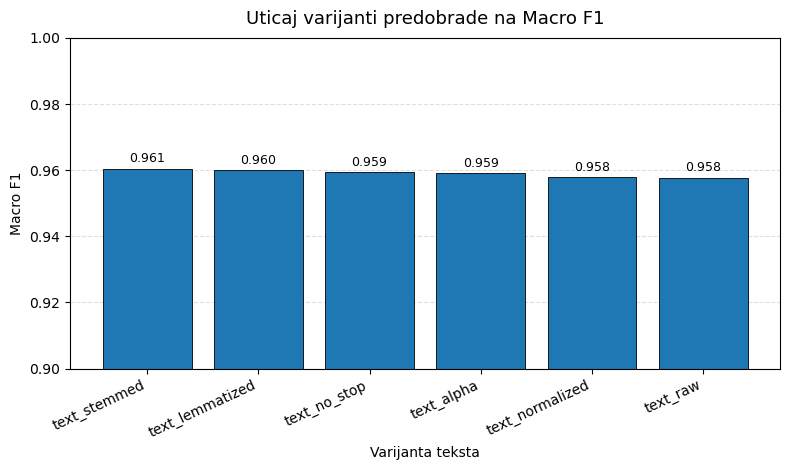

In [149]:
plot_df = preprocessing_results_df.sort_values("macro_f1", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.bar(
    plot_df["text_variant"],
    plot_df["macro_f1"],
    edgecolor="black",
    linewidth=0.6
)

for i, value in enumerate(plot_df["macro_f1"]):
    ax.text(
        i,
        value + 0.001,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Uticaj varijanti predobrade na Macro F1", fontsize=13, pad=10)
ax.set_xlabel("Varijanta teksta")
ax.set_ylabel("Macro F1")
ax.set_ylim(0.90, 1.00)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

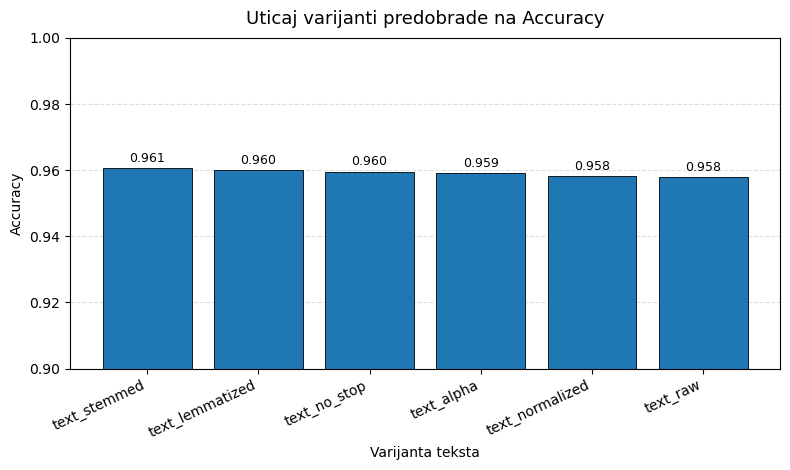

In [150]:
fig, ax = plt.subplots(figsize=(8, 4.8))

ax.bar(
    plot_df["text_variant"],
    plot_df["accuracy"],
    edgecolor="black",
    linewidth=0.6
)

for i, value in enumerate(plot_df["accuracy"]):
    ax.text(
        i,
        value + 0.001,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Uticaj varijanti predobrade na Accuracy", fontsize=13, pad=10)
ax.set_xlabel("Varijanta teksta")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.90, 1.00)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

Grafikoni prikazuju kako se performanse modela menjaju u zavisnosti od korišćene varijante predobrade. Kao glavna metrika koristi se `macro F1`, dok se `accuracy` prikazuje kao dodatna mera ukupne tačnosti.

In [151]:
best_preprocessing_variant = preprocessing_results_df.iloc[0]["text_variant"]

print("Najbolja varijanta predobrade prema macro F1 metrici:", best_preprocessing_variant)
display(preprocessing_results_df.iloc[[0]][
    [
        "text_variant",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "vocabulary_size",
        "training_time_sec"
    ]
].round(4))

Najbolja varijanta predobrade prema macro F1 metrici: text_stemmed


,text_variant,accuracy,macro_f1,weighted_f1,vocabulary_size,training_time_sec
4,text_stemmed,0.9606,0.9605,0.9606,20000,3.1774


Rezultati pokazuju da sve varijante predobrade daju veoma visoke performanse, sa `macro F1` vrednostima između 0.9577 i 0.9605. Najbolji rezultat postiže varijanta `text_stemmed`, sa `accuracy = 0.9606` i `macro F1 = 0.9605`.
Varijanta `text_lemmatized` je druga najbolja, dok je `text_no_stop` veoma blizu. To pokazuje da morfološka normalizacija može blago poboljšati performanse modela, ali razlika u odnosu na tekst bez stop-reči nije velika. Sa druge strane, `text_raw` i `text_normalized` daju nešto slabije rezultate, što ukazuje da uklanjanje stop-reči i dodatna obrada ipak mogu pomoći kod TF-IDF reprezentacije.
Važno je naglasiti da su razlike između najboljih varijanti male. Zbog toga se ne može tvrditi da je agresivnija predobrada uvek najbolja, već da u ovom eksperimentu stemming daje blagu prednost za kombinaciju `TF-IDF + LinearSVC`.

### 5.5 Uticaj augmentacije na performanse

U ovom delu radi se provera da li data augmentation može da poboljša performanse klasifikacije. Augmentacija se primenjuje isključivo nad trening skupom, dok test skup ostaje neizmenjen. Na taj način se izbegava curenje podataka i zadržava realna evaluacija modela. Za augmentaciju se koristi ranije definisana metoda `synonym replacement`, kojom se manjinske klase dopunjuju do broja primera najveće klase u trening skupu. Eksperiment se izvodi nad varijantom `text_no_stop`, jer je ova varijanta dovoljno očišćena, ali i dalje sadrži čitljive tokene pogodne za zamenu sinonimima. Za poređenje se koristi isti model kao u prethodnim analizama: `LinearSVC` nad `TF-IDF` reprezentacijom.

In [152]:
augmentation_text_variant = "text_no_stop"

X_train_aug_base = train_df[augmentation_text_variant].astype(str)
X_test_aug_base = test_df[augmentation_text_variant].astype(str)

print("Varijanta teksta za augmentaciju:", augmentation_text_variant)
print("Broj trening primera pre augmentacije:", len(X_train_aug_base))
print("Broj test primera:", len(X_test_aug_base))

Varijanta teksta za augmentaciju: text_no_stop
Broj trening primera pre augmentacije: 22241
Broj test primera: 5561


In [153]:
train_distribution_before_aug = y_train.value_counts().reindex(labels)

display(pd.DataFrame({
    "class": train_distribution_before_aug.index,
    "count_before_augmentation": train_distribution_before_aug.values
}))

,class,count_before_augmentation
0,Household,8451
1,Books,5005
2,Clothing & Accessories,4539
3,Electronics,4246


In [154]:
X_train_augmented, y_train_augmented = augment_training_data(
    X_train=X_train_aug_base,
    y_train=y_train,
    target_count=None,
    replacement_rate=0.10,
    max_replacements=5,
    random_state=RANDOM_STATE
)

print("Broj trening primera pre augmentacije:", len(X_train_aug_base))
print("Broj trening primera posle augmentacije:", len(X_train_augmented))
print("Broj dodatih augmentovanih primera:", len(X_train_augmented) - len(X_train_aug_base))

Broj trening primera pre augmentacije: 22241
Broj trening primera posle augmentacije: 33804
Broj dodatih augmentovanih primera: 11563


In [155]:
train_distribution_after_aug = y_train_augmented.value_counts().reindex(labels)

augmentation_distribution_df = pd.DataFrame({
    "before_augmentation": train_distribution_before_aug,
    "after_augmentation": train_distribution_after_aug
})

display(augmentation_distribution_df)

,before_augmentation,after_augmentation
Household,8451,8451
Books,5005,8451
Clothing & Accessories,4539,8451
Electronics,4246,8451


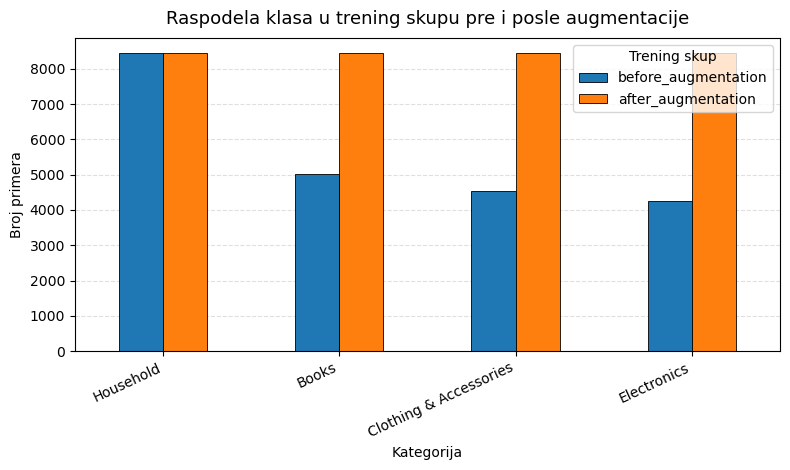

In [156]:
fig, ax = plt.subplots(figsize=(8, 4.8))

augmentation_distribution_df.plot(
    kind="bar",
    ax=ax,
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Raspodela klasa u trening skupu pre i posle augmentacije", fontsize=13, pad=10)
ax.set_xlabel("Kategorija")
ax.set_ylabel("Broj primera")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Trening skup")

plt.tight_layout()
plt.show()

Nakon augmentacije, manjinske klase u trening skupu se dopunjuju do broja primera najveće klase. Test skup se ne menja i ne učestvuje u kreiranju augmentovanih primera.

In [157]:
def train_evaluate_tfidf_linearsvc(X_train_text, y_train_data, X_test_text, y_test_data, experiment_name):
    vectorizer = TfidfVectorizer(
        max_features=20000,
        min_df=2,
        ngram_range=(1, 1)
    )
    
    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_test_vec = vectorizer.transform(X_test_text)
    
    model = LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    )
    
    start_time = time.time()
    model.fit(X_train_vec, y_train_data)
    y_pred = model.predict(X_test_vec)
    elapsed_time = time.time() - start_time
    
    metrics = evaluate_predictions(
        y_true=y_test_data,
        y_pred=y_pred,
        model_name="LinearSVC",
        representation=experiment_name
    )
    
    metrics["training_size"] = len(X_train_text)
    metrics["vocabulary_size"] = len(vectorizer.vocabulary_)
    metrics["training_time_sec"] = elapsed_time
    
    return metrics, model, vectorizer, y_pred

In [158]:
augmentation_experiment_results = {}

metrics_no_aug, model_no_aug, vectorizer_no_aug, y_pred_no_aug = train_evaluate_tfidf_linearsvc(
    X_train_text=X_train_aug_base,
    y_train_data=y_train,
    X_test_text=X_test_aug_base,
    y_test_data=y_test,
    experiment_name="TF-IDF + text_no_stop bez augmentacije"
)

metrics_aug, model_aug, vectorizer_aug, y_pred_aug = train_evaluate_tfidf_linearsvc(
    X_train_text=X_train_augmented,
    y_train_data=y_train_augmented,
    X_test_text=X_test_aug_base,
    y_test_data=y_test,
    experiment_name="TF-IDF + text_no_stop sa augmentacijom"
)

augmentation_results_df = pd.DataFrame([metrics_no_aug, metrics_aug])

display(augmentation_results_df[
    [
        "representation",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "training_size",
        "vocabulary_size",
        "training_time_sec"
    ]
].round(4))

,representation,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_size,vocabulary_size,training_time_sec
0,TF-IDF + text_no_stop bez augmentacije,0.9595,0.9605,0.9584,0.9594,0.9595,22241,20000,0.6318
1,TF-IDF + text_no_stop sa augmentacijom,0.9581,0.9581,0.9576,0.9579,0.9581,33804,20000,0.9135


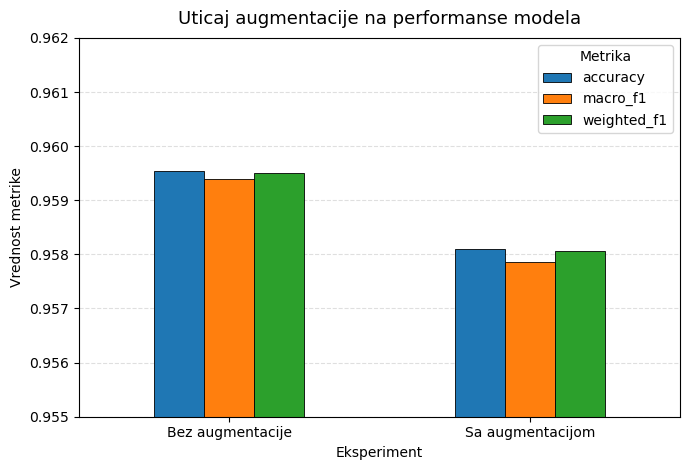

In [159]:
augmentation_plot_df = augmentation_results_df.copy()
augmentation_plot_df["experiment"] = ["Bez augmentacije", "Sa augmentacijom"]

fig, ax = plt.subplots(figsize=(7, 4.8))

plot_metrics = augmentation_plot_df.set_index("experiment")[["accuracy", "macro_f1", "weighted_f1"]]

plot_metrics.plot(
    kind="bar",
    ax=ax,
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Uticaj augmentacije na performanse modela", fontsize=13, pad=10)
ax.set_xlabel("Eksperiment")
ax.set_ylabel("Vrednost metrike")
ax.set_ylim(0.955, 0.962)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=0)
plt.legend(title="Metrika")

plt.tight_layout()
plt.show()

In [160]:
best_aug_experiment_idx = augmentation_results_df["macro_f1"].idxmax()
best_aug_experiment = augmentation_results_df.loc[best_aug_experiment_idx]

print("Bolji rezultat prema macro F1 metrici:")
display(best_aug_experiment.to_frame().T[
    [
        "representation",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "training_size",
        "vocabulary_size",
        "training_time_sec"
    ]
].round(4))

Bolji rezultat prema macro F1 metrici:


,representation,accuracy,macro_f1,weighted_f1,training_size,vocabulary_size,training_time_sec
0,TF-IDF + text_no_stop bez augmentacije,0.95954,0.959391,0.959513,22241,20000,0.631847


Rezultati pokazuju da augmentacija u ovom eksperimentu nije poboljšala performanse modela. Bez augmentacije model postiže `accuracy = 0.9595` i `macro F1 = 0.9594`, dok nakon augmentacije postiže `accuracy = 0.9581` i `macro F1 = 0.9579`. Iako je augmentacija uspešno balansirala trening skup i povećala broj trening primera sa 22241 na 33804, blago smanjenje performansi ukazuje da dodatni sintetički primeri nisu doneli novu korisnu informaciju modelu. Moguće je da je početni dataset već dovoljno velik, a da synonym replacement ponekad uvodi izraze koji nisu potpuno prirodni za e-commerce domen.
Zbog toga se za finalni model zadržava varijanta bez augmentacije.

### 5.6 Deep Learning modeli: CNN i LSTM

Pored klasičnih modela mašinskog učenja, u ovom delu se testiraju i dva jednostavna Deep Learning modela za klasifikaciju teksta: `TextCNN` i `BiLSTM`.

Za razliku od TF-IDF pristupa, ovi modeli koriste sekvencu tokena i uče reprezentacije reči kroz embedding sloj. Time mogu da iskoriste redosled reči i lokalni kontekst u tekstu. U eksperimentu se koristi varijanta `text_normalized`, jer neuronski modeli bolje rade sa prirodnijim tekstom nego sa tekstom iz koga su agresivno uklonjene reči ili promenjeni oblici tokena.

In [161]:
# TensorFlow instalacija
#!pip install tensorflow

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Za Deep Learning modele koristi se `text_normalized` varijanta. Nakon tokenizacije, trening skup ima oblik `22241 × 200`, a test skup `5561 × 200`, što znači da je svaki opis predstavljen sekvencom od najviše 200 tokena.

Tokenizer je formirao vokabular od 79352 tokena, ali model koristi najčešćih 30000 reči. Time se ograničava složenost modela i smanjuje uticaj veoma retkih tokena.

In [162]:
dl_text_variant = "text_normalized"

X_train_dl_text = train_df[dl_text_variant].astype(str)
X_test_dl_text = test_df[dl_text_variant].astype(str)

MAX_WORDS = 30000
MAX_LEN = 200
EMBEDDING_DIM = 100

tokenizer_dl = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer_dl.fit_on_texts(X_train_dl_text)

X_train_sequences = tokenizer_dl.texts_to_sequences(X_train_dl_text)
X_test_sequences = tokenizer_dl.texts_to_sequences(X_test_dl_text)

X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Tekstualna varijanta za Deep Learning:", dl_text_variant)
print("Dimenzije trening sekvenci:", X_train_pad.shape)
print("Dimenzije test sekvenci:", X_test_pad.shape)
print("Veličina tokenizer vokabulara:", len(tokenizer_dl.word_index))
print("Broj reči koje model koristi:", min(MAX_WORDS, len(tokenizer_dl.word_index) + 1))

Tekstualna varijanta za Deep Learning: text_normalized
Dimenzije trening sekvenci: (22241, 200)
Dimenzije test sekvenci: (5561, 200)
Veličina tokenizer vokabulara: 79352
Broj reči koje model koristi: 30000


In [163]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

print("Klase:", list(label_encoder.classes_))
print("Broj klasa:", num_classes)

Klase: ['Books', 'Clothing & Accessories', 'Electronics', 'Household']
Broj klasa: 4


In [164]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

Prvi neuronski model je `TextCNN`. On koristi konvolucioni sloj nad sekvencom tokena i može da prepozna lokalne obrasce u tekstu, na primer izraze ili kombinacije reči koje su karakteristične za određenu kategoriju proizvoda.

In [165]:
def build_textcnn_model():
    model = Sequential([
        tf.keras.Input(shape=(MAX_LEN,), dtype="int32"),
        
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=EMBEDDING_DIM
        ),
        
        Conv1D(
            filters=128,
            kernel_size=5,
            activation="relu"
        ),
        
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model


textcnn_model = build_textcnn_model()
textcnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,072,644 (11.72 MB)

 Trainable params: 3,072,644 (11.72 MB)

 Non-trainable params: 0 (0.00 B)

In [166]:
start_time = time.time()

history_textcnn = textcnn_model.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.10,
    epochs=6,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

textcnn_training_time = time.time() - start_time

print(f"Vreme treniranja TextCNN modela: {textcnn_training_time:.2f} sekundi")

Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.7138 - loss: 0.7269 - val_accuracy: 0.9330 - val_loss: 0.2284
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9532 - loss: 0.1798 - val_accuracy: 0.9497 - val_loss: 0.1780
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.9765 - loss: 0.0915 - val_accuracy: 0.9519 - val_loss: 0.1815
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.9879 - loss: 0.0490 - val_accuracy: 0.9533 - val_loss: 0.1996
Vreme treniranja TextCNN modela: 45.49 sekundi


In [167]:
y_pred_textcnn_encoded = np.argmax(
    textcnn_model.predict(X_test_pad, batch_size=128),
    axis=1
)

y_pred_textcnn = label_encoder.inverse_transform(y_pred_textcnn_encoded)

textcnn_metrics = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_textcnn,
    model_name="TextCNN",
    representation="Embedding + text_normalized"
)

textcnn_metrics["training_time_sec"] = textcnn_training_time

display(pd.DataFrame([textcnn_metrics]).round(4))

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


,model,representation,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_sec
0,TextCNN,Embedding + text_normalized,0.9522,0.9514,0.9521,0.9517,0.9521,45.4912


`TextCNN` postiže `accuracy = 0.9522` i `macro F1 = 0.9517`. Model brzo uči i već nakon nekoliko epoha dostiže visoku validacionu tačnost.

Drugi neuronski model je `BiLSTM`. LSTM obrađuje sekvencu tokena kroz redosled pojavljivanja. `Bidirectional LSTM` posmatra tekst u oba smera, što može pomoći u hvatanju šireg konteksta u opisu proizvoda.

In [168]:
def build_bilstm_model():
    model = Sequential([
        tf.keras.Input(shape=(MAX_LEN,), dtype="int32"),
        
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=EMBEDDING_DIM
        ),
        
        Bidirectional(
            LSTM(64, return_sequences=False)
        ),
        
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model


bilstm_model = build_bilstm_model()
bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 100)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,092,996 (11.80 MB)

 Trainable params: 3,092,996 (11.80 MB)

 Non-trainable params: 0 (0.00 B)

In [169]:
start_time = time.time()

history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.10,
    epochs=6,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

bilstm_training_time = time.time() - start_time

print(f"Vreme treniranja BiLSTM modela: {bilstm_training_time:.2f} sekundi")

Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 454ms/step - accuracy: 0.8074 - loss: 0.5136 - val_accuracy: 0.9488 - val_loss: 0.1815
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 510ms/step - accuracy: 0.9699 - loss: 0.1184 - val_accuracy: 0.9524 - val_loss: 0.1690
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 516ms/step - accuracy: 0.9873 - loss: 0.0556 - val_accuracy: 0.9542 - val_loss: 0.1862
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 89s 564ms/step - accuracy: 0.9938 - loss: 0.0291 - val_accuracy: 0.9497 - val_loss: 0.2204
Vreme treniranja BiLSTM modela: 326.09 sekundi


In [170]:
y_pred_bilstm_encoded = np.argmax(
    bilstm_model.predict(X_test_pad, batch_size=128),
    axis=1
)

y_pred_bilstm = label_encoder.inverse_transform(y_pred_bilstm_encoded)

bilstm_metrics = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_bilstm,
    model_name="BiLSTM",
    representation="Embedding + text_normalized"
)

bilstm_metrics["training_time_sec"] = bilstm_training_time

display(pd.DataFrame([bilstm_metrics]).round(4))

44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step


,model,representation,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_sec
0,BiLSTM,Embedding + text_normalized,0.9568,0.9553,0.9578,0.9565,0.9568,326.0865


`BiLSTM` postiže bolji rezultat od `TextCNN`, sa `accuracy = 0.9568` i `macro F1 = 0.9565`. To pokazuje da sekvencijalni model koji obrađuje tekst u oba smera može bolje da iskoristi redosled tokena i širi kontekst opisa proizvoda, ali je vreme treniranja znatno duže nego kod `TextCNN` modela i klasičnih modela. Zbog toga je važno posmatrati ne samo performanse, već i računsku cenu modela.

In [171]:
deep_learning_results_df = pd.DataFrame([
    textcnn_metrics,
    bilstm_metrics
])

display(deep_learning_results_df[
    [
        "model",
        "representation",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "training_time_sec"
    ]
].round(4))

,model,representation,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_sec
0,TextCNN,Embedding + text_normalized,0.9522,0.9514,0.9521,0.9517,0.9521,45.4912
1,BiLSTM,Embedding + text_normalized,0.9568,0.9553,0.9578,0.9565,0.9568,326.0865


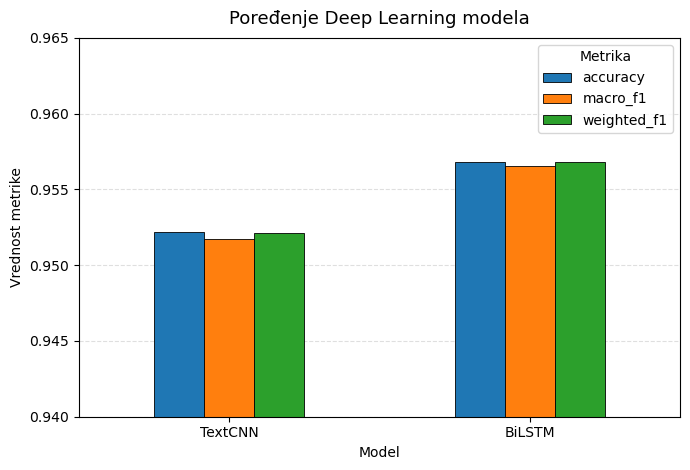

In [173]:
dl_plot_df = deep_learning_results_df.set_index("model")[[
    "accuracy",
    "macro_f1",
    "weighted_f1"
]]

fig, ax = plt.subplots(figsize=(7, 4.8))

dl_plot_df.plot(
    kind="bar",
    ax=ax,
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Poređenje Deep Learning modela", fontsize=13, pad=10)
ax.set_xlabel("Model")
ax.set_ylabel("Vrednost metrike")
ax.set_ylim(0.94, 0.965)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=0)
plt.legend(title="Metrika")

plt.tight_layout()
plt.show()

Rezultati pokazuju da oba Deep Learning modela ostvaruju visoke performanse. `BiLSTM` je bolji od `TextCNN`, sa `macro F1 = 0.9565` u odnosu na `0.9517`, ali je znatno sporiji za treniranje.

U poređenju sa najboljim klasičnim pristupom, Deep Learning modeli nisu ostvarili bolji rezultat. Najbolja kombinacija u prethodnim eksperimentima bila je `TF-IDF + LinearSVC`, posebno sa `text_stemmed` varijantom, gde je `macro F1` iznosio `0.9605`.

Ovaj rezultat pokazuje da neuronski modeli mogu biti veoma uspešni, ali da za ovaj e-commerce dataset klasični linearni model nad dobro pripremljenom TF-IDF reprezentacijom ostaje jednostavnije, brže i blago uspešnije rešenje.

### 5.7 Finalna tabela i analiza rezultata

In [182]:
final_result_frames = []

baseline_final = baseline_results_df.copy()
baseline_final["experiment_group"] = "Baseline"
baseline_final["text_variant"] = "-"
baseline_final["configuration"] = "DummyClassifier | most_frequent"
final_result_frames.append(baseline_final)

# klasični modeli na TF-IDF reprezentaciji
classic_final = tfidf_results_df.copy()
classic_final = classic_final[classic_final["model"] != "LinearSVC"].copy()
classic_final["experiment_group"] = "Klasični modeli (TF-IDF)"
classic_final["text_variant"] = "text_no_stop"
classic_final["configuration"] = (
    classic_final["model"] + " | TF-IDF | text_no_stop"
)
final_result_frames.append(classic_final)

# poređenje ostalih reprezentacija nad LinearSVC modelom
representation_final = representation_results_df.copy()
representation_final = representation_final[
    representation_final["representation"] != "TF-IDF"
].copy()

representation_text_variant_map = {
    "BoW": "text_no_stop",
    "Word2Vec": "text_no_stop",
    "FastText": "text_no_stop",
    "SentenceTransformer": "text_normalized"
}

representation_final["experiment_group"] = "Reprezentacije (LinearSVC)"
representation_final["text_variant"] = representation_final["representation"].map(
    representation_text_variant_map
)
representation_final["configuration"] = (
    "LinearSVC | " + representation_final["representation"] + " | " +
    representation_final["text_variant"]
)
final_result_frames.append(representation_final)

# varijante predobrade nad TF-IDF + LinearSVC
preprocessing_final = preprocessing_results_df.copy()
preprocessing_final["experiment_group"] = "Predobrada (TF-IDF + LinearSVC)"
preprocessing_final["model"] = "LinearSVC"
preprocessing_final["representation"] = "TF-IDF"
preprocessing_final["configuration"] = (
    "LinearSVC | TF-IDF | " + preprocessing_final["text_variant"]
)
final_result_frames.append(preprocessing_final)

# augmentacija
augmentation_final = augmentation_results_df.copy()
augmentation_final["experiment_group"] = "Augmentacija"
augmentation_final["text_variant"] = "text_no_stop"
augmentation_final["configuration"] = augmentation_final["representation"]
final_result_frames.append(augmentation_final)

# Deep Learning modeli
deep_learning_final = deep_learning_results_df.copy()
deep_learning_final["experiment_group"] = "Deep Learning"
deep_learning_final["text_variant"] = "text_normalized"
deep_learning_final["configuration"] = (
    deep_learning_final["model"] + " | Embedding | text_normalized"
)
final_result_frames.append(deep_learning_final)

final_results_df = pd.concat(final_result_frames, ignore_index=True)

final_columns = [
    "experiment_group",
    "configuration",
    "model",
    "representation",
    "text_variant",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "training_time_sec"
]

final_results_df = final_results_df[final_columns]
final_results_df = final_results_df.sort_values("macro_f1", ascending=False)

display(final_results_df.round(4))

,experiment_group,configuration,model,representation,text_variant,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_sec
9,Predobrada (TF-IDF + LinearSVC),LinearSVC | TF-IDF | text_stemmed,LinearSVC,TF-IDF,text_stemmed,0.9606,0.9616,0.9595,0.9605,0.9606,3.1774
10,Predobrada (TF-IDF + LinearSVC),LinearSVC | TF-IDF | text_lemmatized,LinearSVC,TF-IDF,text_lemmatized,0.9601,0.9607,0.9592,0.9599,0.9601,2.9584
15,Augmentacija,TF-IDF + text_no_stop bez augmentacije,LinearSVC,TF-IDF + text_no_stop bez augmentacije,text_no_stop,0.9595,0.9605,0.9584,0.9594,0.9595,0.6318
11,Predobrada (TF-IDF + LinearSVC),LinearSVC | TF-IDF | text_no_stop,LinearSVC,TF-IDF,text_no_stop,0.9595,0.9605,0.9584,0.9594,0.9595,3.6694
12,Predobrada (TF-IDF + LinearSVC),LinearSVC | TF-IDF | text_alpha,LinearSVC,TF-IDF,text_alpha,0.9592,0.9602,0.9579,0.9590,0.9591,6.1463
13,Predobrada (TF-IDF + LinearSVC),LinearSVC | TF-IDF | text_normalized,LinearSVC,TF-IDF,text_normalized,0.9581,0.9589,0.9570,0.9579,0.9581,5.0370
16,Augmentacija,TF-IDF + text_no_stop sa augmentacijom,LinearSVC,TF-IDF + text_no_stop sa augmentacijom,text_no_stop,0.9581,0.9581,0.9576,0.9579,0.9581,0.9135
14,Predobrada (TF-IDF + LinearSVC),LinearSVC | TF-IDF | text_raw,LinearSVC,TF-IDF,text_raw,0.9579,0.9587,0.9568,0.9577,0.9579,4.9461
18,Deep Learning,BiLSTM | Embedding | text_normalized,BiLSTM,Embedding + text_normalized,text_normalized,0.9568,0.9553,0.9578,0.9565,0.9568,326.0865
1,Klasični modeli (TF-IDF),LogisticRegression | TF-IDF | text_no_stop,LogisticRegression,TF-IDF,text_no_stop,0.9545,0.9546,0.9545,0.9545,0.9545,10.8456


In [183]:
final_model_results_df = final_results_df[
    final_results_df["experiment_group"] != "Baseline"
].copy()

best_overall_idx = final_model_results_df["macro_f1"].idxmax()
best_overall_result = final_model_results_df.loc[best_overall_idx]

print("Najbolja ukupna konfiguracija prema macro F1 metrici:")
print("=" * 80)
print("Grupa eksperimenta:", best_overall_result["experiment_group"])
print("Konfiguracija:", best_overall_result["configuration"])
print("Model:", best_overall_result["model"])
print("Reprezentacija:", best_overall_result["representation"])
print("Varijanta teksta:", best_overall_result["text_variant"])
print(f"Accuracy: {best_overall_result['accuracy']:.4f}")
print(f"Macro F1: {best_overall_result['macro_f1']:.4f}")
print(f"Weighted F1: {best_overall_result['weighted_f1']:.4f}")

Najbolja ukupna konfiguracija prema macro F1 metrici:
Grupa eksperimenta: Predobrada (TF-IDF + LinearSVC)
Konfiguracija: LinearSVC | TF-IDF | text_stemmed
Model: LinearSVC
Reprezentacija: TF-IDF
Varijanta teksta: text_stemmed
Accuracy: 0.9606
Macro F1: 0.9605
Weighted F1: 0.9606


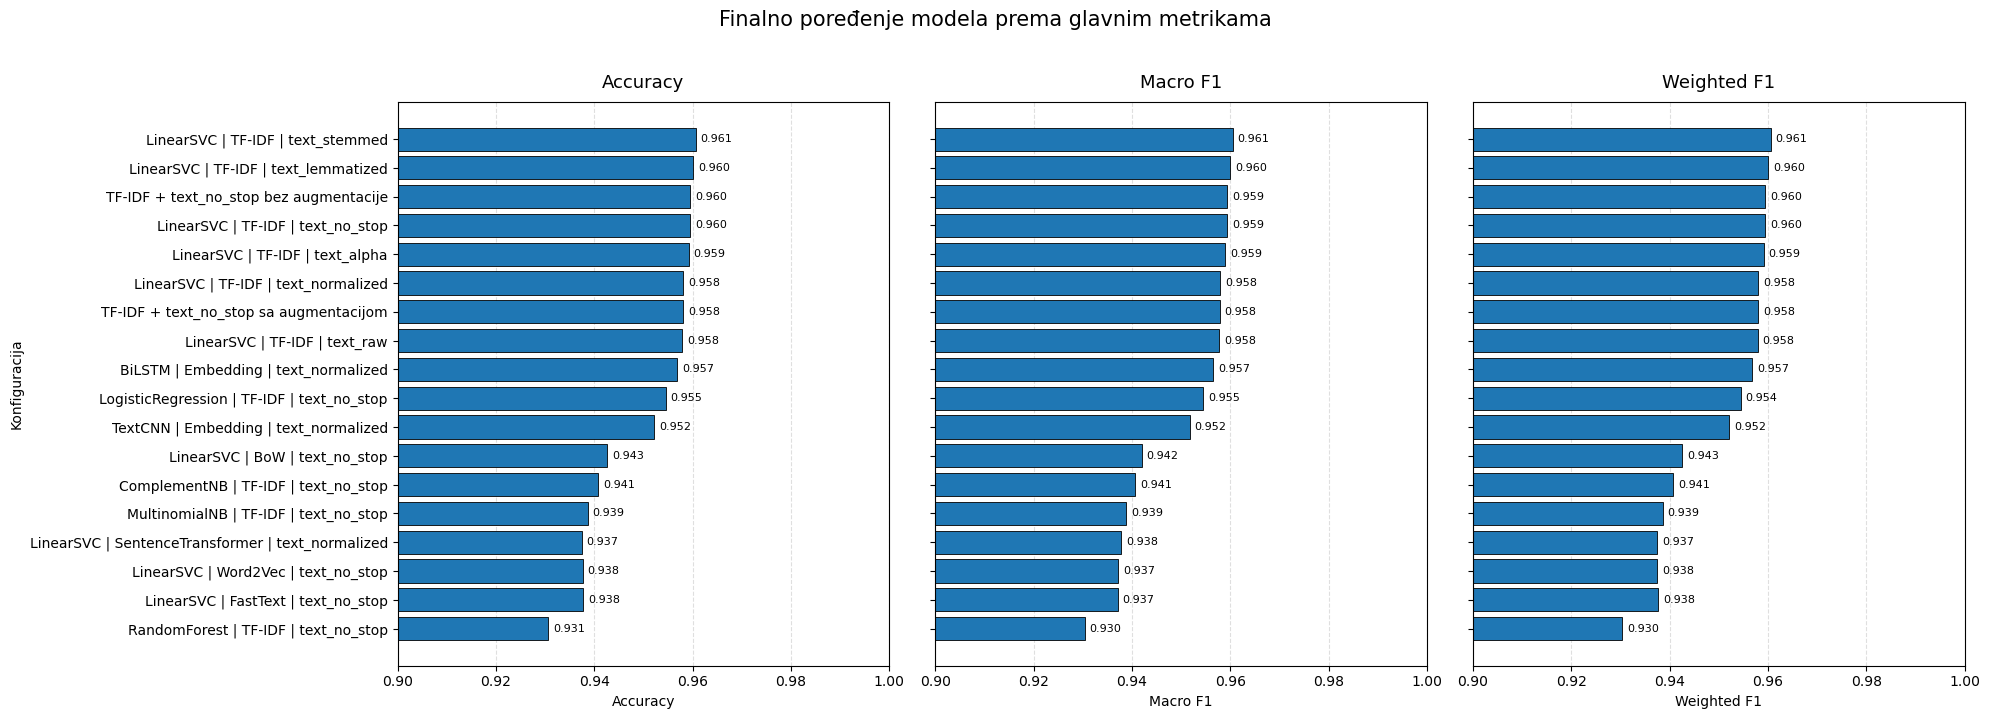

In [184]:
visualization_df = final_model_results_df.sort_values("macro_f1", ascending=True).copy()

metrics_to_plot = [
    ("accuracy", "Accuracy"),
    ("macro_f1", "Macro F1"),
    ("weighted_f1", "Weighted F1")
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, max(7, 0.38 * len(visualization_df))),
    sharey=True
)

for ax, (metric, title) in zip(axes, metrics_to_plot):
    ax.barh(
        visualization_df["configuration"],
        visualization_df[metric],
        edgecolor="black",
        linewidth=0.6
    )
    
    for i, value in enumerate(visualization_df[metric]):
        ax.text(
            value + 0.001,
            i,
            f"{value:.3f}",
            va="center",
            fontsize=8
        )
    
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel(title)
    ax.set_xlim(0.90, 1.00)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel("Konfiguracija")

fig.suptitle("Finalno poređenje modela prema glavnim metrikama", fontsize=15, y=1.02)

plt.tight_layout()
plt.show()

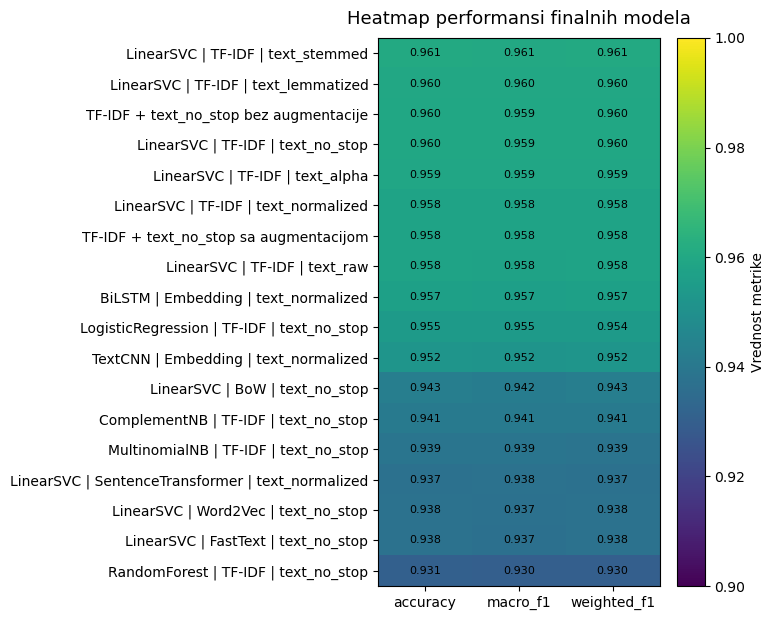

In [185]:
heatmap_metrics = ["accuracy", "macro_f1", "weighted_f1"]

heatmap_df = final_model_results_df.sort_values(
    "macro_f1",
    ascending=False
).set_index("configuration")[heatmap_metrics]

fig, ax = plt.subplots(figsize=(7.5, max(6, 0.35 * len(heatmap_df))))

heatmap_values = heatmap_df.values

im = ax.imshow(
    heatmap_values,
    aspect="auto",
    vmin=0.90,
    vmax=1.00
)

ax.set_xticks(np.arange(len(heatmap_metrics)))
ax.set_xticklabels(heatmap_metrics)

ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(heatmap_values.shape[0]):
    for j in range(heatmap_values.shape[1]):
        ax.text(
            j,
            i,
            f"{heatmap_values[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title("Heatmap performansi finalnih modela", fontsize=13, pad=10)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Vrednost metrike")

plt.tight_layout()
plt.show()

In [186]:
best_by_group_df = (
    final_model_results_df
    .sort_values("macro_f1", ascending=False)
    .groupby("experiment_group")
    .head(1)
    .sort_values("macro_f1", ascending=False)
)

display(best_by_group_df[
    [
        "experiment_group",
        "configuration",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "training_time_sec"
    ]
].round(4))

,experiment_group,configuration,accuracy,macro_f1,weighted_f1,training_time_sec
9,Predobrada (TF-IDF + LinearSVC),LinearSVC | TF-IDF | text_stemmed,0.9606,0.9605,0.9606,3.1774
15,Augmentacija,TF-IDF + text_no_stop bez augmentacije,0.9595,0.9594,0.9595,0.6318
18,Deep Learning,BiLSTM | Embedding | text_normalized,0.9568,0.9565,0.9568,326.0865
1,Klasični modeli (TF-IDF),LogisticRegression | TF-IDF | text_no_stop,0.9545,0.9545,0.9545,10.8456
5,Reprezentacije (LinearSVC),LinearSVC | BoW | text_no_stop,0.9426,0.9420,0.9426,20.8754


#### Zaključci

Na osnovu sprovedenih eksperimenata, najbolji ukupni rezultat ostvaren je kombinacijom `LinearSVC` modela, `TF-IDF` reprezentacije i `text_stemmed` varijante predobrade. Ova konfiguracija postiže `accuracy = 0.9606`, `macro F1 = 0.9605` i `weighted F1 = 0.9606`. Pošto je izbor najboljeg modela zasnovan na `macro F1` metrici, ovaj rezultat pokazuje da model dobro prepoznaje sve kategorije, a ne samo najzastupljeniju klasu.

Najbolje rezultate u celini daju konfiguracije zasnovane na `TF-IDF` reprezentaciji i `LinearSVC` modelu. U vrhu tabele nalaze se varijante `text_stemmed`, `text_lemmatized`, `text_no_stop`, `text_alpha`, `text_normalized` i `text_raw`, pri čemu su razlike između njih relativno male. To pokazuje da predobrada utiče na performanse, ali i da kod ovog dataseta osnovni tekst već sadrži dovoljno jasne kategorijske signale. Stemming daje malu prednost, ali se ta prednost ne može tumačiti kao velika razlika u odnosu na druge kvalitetno pripremljene varijante.

Embedding pristupi, uključujući `Word2Vec`, `FastText` i `SentenceTransformer`, ostvarili su dobre rezultate, ali nisu nadmašili najbolju `TF-IDF` konfiguraciju. Njihove `macro F1` vrednosti su oko `0.937–0.938`, što pokazuje da ove reprezentacije hvataju deo semantičke strukture tekstualnih opisa. Ipak, za ovaj konkretan zadatak kategorije proizvoda se veoma dobro razdvajaju pomoću karakterističnih tokena, zbog čega sparse reprezentacije kao što je `TF-IDF` bolje odgovaraju linearnom klasifikatoru.

Deep Learning modeli su ostvarili visoke performanse. `BiLSTM` je bolji od `TextCNN`, sa `macro F1 = 0.9565` u odnosu na `0.9517`, ali zahteva znatno duže vreme treniranja. Iako neuronski modeli koriste redosled reči i uče embedding reprezentacije tokom treniranja, nisu nadmašili najbolji klasični pristup. Ovaj rezultat pokazuje da složeniji modeli nisu automatski bolji, posebno kada je dataset dovoljno velik, a klase se mogu dobro razlikovati pomoću ključnih termina.

Data augmentation pomoću zamene sinonimima nije poboljšao performanse. Iako je uspešno balansirao trening skup, rezultat sa augmentacijom bio je nešto slabiji od rezultata bez augmentacije. To ukazuje da sintetički generisani primeri nisu doneli novu korisnu informaciju modelu, a moguće je i da zamena sinonimima ponekad uvodi izraze koji nisu potpuno prirodni za e-commerce domen. 

Opšti zaključak je da kvalitet teksta, izbor predobrade i način reprezentacije imaju važan uticaj na performanse modela. Međutim, agresivnija obrada, kompleksnija reprezentacija ili složeniji model ne daju nužno najbolje rezultate. U ovom radu najbolji balans između jednostavnosti, brzine i performansi postignut je klasičnim pristupom `TF-IDF + LinearSVC`, uz `text_stemmed` varijantu predobrade.